# AGRVF - Automated Ground-truth & Reasoning Verification Framework for Product Claims

Full merged pipeline notebook - Layer B (Claim & Product Understanding) -> Layer C (Local Evidence Retrieval) -> Layer D (Web Evidence, AECS, Reasoning & Verdict) -> Interactive Claim Verification.

This notebook merges the previously separate Layer B, Layer C and Layer D Kaggle notebooks into a single, end-to-end, resumable pipeline. Layer A (data acquisition) is not re-run here, its outputs are read from the attached AGRVF-Project-Storage dataset.

## How this notebook is organized

- Part 0, Global Setup: paths, seeds, prebuilt-output detection helpers
- Part 1, Layer B: product identification (BGE + FAISS), claim understanding (Qwen3-1.7B), category classification, product resolution, deterministic product+claim extraction, full-dataset batch run
- Part 2, Layer C: local evidence retrieval only, Amazon catalog, OpenBeautyFacts ingredients, FEVER/SciFact scientific passages
- Part 3, Layer D: official web-page resolution and scraping, web evidence cleaning, evidence integration, Adaptive Evidence Credibility Scoring (AECS), stance classification, ingredient reasoning, verdict determination, final explanation, provenance
- Part 4, Interactive Verification: paste in any 1-4 line product claim and get a full, live CLAIM -> PRODUCT -> CATEGORY -> CLAIM TYPE -> EVIDENCE -> AECS-WEIGHTED CREDIBILITY -> VERDICT -> CONFIDENCE -> REASONING -> SCIENTIFIC/INGREDIENT EXPLANATION -> PROVENANCE result, whether or not the product exists in the local dataset

## Resumability

Every heavy stage (embeddings, FAISS index, the full-dataset Layer B run, the full Layer C run, the full Layer D run) checks first whether its output already exists, either already computed earlier in this same Kaggle session (/kaggle/working/AGRVF/...), or uploaded by you as an attached dataset anywhere under (/kaggle/input/). If a matching output file is found, that stage is skipped and the existing file is loaded instead, nothing is ever recomputed or run twice. This is implemented generically in Part 0 via (locate_file()), (stage_output_ready()) and import_prebuilt_checkpoints(), and is used consistently through Layer B (section B4), Layer C (section C7) and Layer D (section D11).

Just attach whatever you already have (partial checkpoints or a complete final parquet, for Layer B and/or Layer C and/or Layer D) as a Kaggle dataset to this notebook, in any folder structure, the notebook will find it by filename.

Settings required in the Kaggle notebook itself: GPU accelerator ON, Internet ON (Layer D scrapes the live web).


In [47]:
print("hello,World!")


hello,World!


# PART 0 - Global Setup

## 0.1 - Kaggle environment check

In [48]:
import numpy as np
import pandas as pd
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/datasets/ruhulamin12/agrvf-project-storage-new/layer_c_evidence_flat.parquet
/kaggle/input/datasets/ruhulamin12/agrvf-project-storage-new/layer_c_local_evidence.parquet
/kaggle/input/datasets/ruhulamin12/agrvf-project-storage-new/agrvf-layer-b-output.parquet
/kaggle/input/datasets/ruhulaminrakib/agrvf-project-storage/amazon_products_b1.faiss
/kaggle/input/datasets/ruhulaminrakib/agrvf-project-storage/amazon_product_embeddings_b1.npy
/kaggle/input/datasets/ruhulaminrakib/agrvf-project-storage/scifact/scifact_train_agrvf.parquet
/kaggle/input/datasets/ruhulaminrakib/agrvf-project-storage/scifact/scifact_test_agrvf.parquet
/kaggle/input/datasets/ruhulaminrakib/agrvf-project-storage/scifact/scifact_corpus_agrvf.parquet
/kaggle/input/datasets/ruhulaminrakib/agrvf-project-storage/scifact/scifact_dev_agrvf.parquet
/kaggle/input/datasets/ruhulaminrakib/agrvf-project-storage/amazon/amazon_claims_agrvf.parquet
/kaggle/input/datasets/ruhulaminrakib/agrvf-project-storage/amazon/amazo

## 0.2 - Paths, seeds, working directories

Same layout as the original Layer B / C / D notebooks (`/kaggle/working/AGRVF/...`), so all cached embeddings / indices / checkpoints from earlier sessions on this account are picked up automatically.

In [49]:
import os
import re
import json
import glob
import shutil
import fnmatch
import hashlib
import random
import warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

BASE_PATH = "/kaggle/working/AGRVF"

# Layer A Kaggle dataset (already produced - not re-run in this notebook).
DATASET_ROOT = "/kaggle/input/datasets/ruhulaminrakib/agrvf-project-storage"

LAYER_B_DIR = f"{BASE_PATH}/data/processed/layer_b"
LAYER_C_DIR = f"{BASE_PATH}/results/layer_c"
LAYER_D_DIR = f"{BASE_PATH}/data/processed/layer_d"
LAYER_D_RESULTS = f"{BASE_PATH}/results/layer_d"
WEB_CACHE_DIR = f"{LAYER_D_DIR}/web_cache"

for p in [LAYER_B_DIR, LAYER_C_DIR, LAYER_D_DIR, LAYER_D_RESULTS, WEB_CACHE_DIR]:
    os.makedirs(p, exist_ok=True)

print("BASE_PATH:", BASE_PATH)
print("DATASET_ROOT exists:", os.path.exists(DATASET_ROOT))
print("Layer B dir:", LAYER_B_DIR)
print("Layer C dir:", LAYER_C_DIR)
print("Layer D dir:", LAYER_D_DIR)


BASE_PATH: /kaggle/working/AGRVF
DATASET_ROOT exists: True
Layer B dir: /kaggle/working/AGRVF/data/processed/layer_b
Layer C dir: /kaggle/working/AGRVF/results/layer_c
Layer D dir: /kaggle/working/AGRVF/data/processed/layer_d


## 0.3 - Resumability helpers

These three helpers are the mechanism behind *"do not process again if the data is already available"*, requested for every heavy stage in this notebook:

- `locate_file(filename)` - recursively searches `/kaggle/input` (i.e. everything you have attached as a dataset) for a file with this exact name, regardless of which dataset folder it lives under. You don't need to know or hardcode the Kaggle dataset slug you'll upload things as.
- `stage_output_ready(output_path)` - `True` if `output_path` already exists in the working directory, or a same-named file is found under `/kaggle/input` (in which case it is copied into place automatically). `False` only if the stage genuinely needs to run.
- `import_prebuilt_checkpoints(checkpoint_dir, pattern)` - for the three checkpointed batch stages (Layer B section B4, Layer C section C7, Layer D section D11): copies in any checkpoint chunk files matching `pattern` found anywhere under `/kaggle/input`, so an uploaded partial run resumes exactly where it left off, without re-processing already-completed claims.

In [50]:
def locate_file(filename, search_root="/kaggle/input"):
    """Recursively search search_root for a file named exactly `filename`.
    Returns the first match, or None. Lets us find an uploaded output
    regardless of the Kaggle dataset name/folder structure the user chose."""
    if not os.path.isdir(search_root):
        return None
    for root, _dirs, files in os.walk(search_root):
        if filename in files:
            return os.path.join(root, filename)
    return None


def stage_output_ready(output_path, filename_to_search=None):
    """Returns True if `output_path` already exists (this session, or a
    previous session's /kaggle/working carried over), OR a prebuilt copy is
    found anywhere under /kaggle/input and is copied into place.
    Returns False only if the caller genuinely needs to run the stage."""
    if os.path.exists(output_path):
        return True

    fname = filename_to_search or os.path.basename(output_path)
    found = locate_file(fname)

    if found:
        os.makedirs(os.path.dirname(output_path), exist_ok=True)
        shutil.copy(found, output_path)
        print(f"Found prebuilt '{fname}' at: {found}")
        print(f"  -> copied to: {output_path}")
        return True

    return False


def import_prebuilt_checkpoints(checkpoint_dir, pattern):
    """Copy any uploaded checkpoint chunk files matching `pattern`
    (e.g. 'chunk_*.parquet') found anywhere under /kaggle/input into
    checkpoint_dir, so an uploaded partial run resumes instead of
    restarting. Returns the number of files imported."""
    os.makedirs(checkpoint_dir, exist_ok=True)
    existing = set(os.listdir(checkpoint_dir))
    imported = 0

    for root, _dirs, files in os.walk("/kaggle/input"):
        for f in files:
            if fnmatch.fnmatch(f, pattern) and f not in existing:
                shutil.copy(os.path.join(root, f), os.path.join(checkpoint_dir, f))
                existing.add(f)
                imported += 1

    if imported:
        print(f"Imported {imported} prebuilt checkpoint file(s) into {checkpoint_dir}")
    else:
        print(f"No prebuilt checkpoint files found for pattern '{pattern}' - starting from whatever is already in {checkpoint_dir}")

    return imported


def atomic_write_parquet(df, path):
    """Write-then-rename so a crash mid-write never leaves a corrupt file."""
    tmp_path = path + ".tmp"
    df.to_parquet(tmp_path, index=False)
    os.replace(tmp_path, path)
def stage_output_covers(output_path, expected_ids, checkpoint_dir=None,
                         checkpoint_prefix="prebuilt_seed",
                         id_col="agrvf_claim_id", filename_to_search=None):
    """
    True  -> output_path (local or found under /kaggle/input) already contains
             EVERY id in expected_ids - safe to just load it, nothing to run.
    False -> stage still needs to run for the missing ids. Any rows already
             found are copied into checkpoint_dir as a seed chunk so nothing
             already computed is wasted.
    """
    have_local = os.path.exists(output_path)
    if not have_local:
        fname = filename_to_search or os.path.basename(output_path)
        found = locate_file(fname)
        if found:
            os.makedirs(os.path.dirname(output_path), exist_ok=True)
            shutil.copy(found, output_path)
            print(f"Found prebuilt '{fname}' at: {found} -> copied to: {output_path}")
            have_local = True

    if not have_local:
        return False

    existing_df = pd.read_parquet(output_path)
    existing_ids = set(existing_df[id_col].astype(str))
    missing = expected_ids - existing_ids

    print(f"'{output_path}': {len(existing_ids)} existing rows, "
          f"{len(missing)} missing out of {len(expected_ids)} expected.")

    if not missing:
        return True

    if checkpoint_dir is not None:
        os.makedirs(checkpoint_dir, exist_ok=True)
        seed_path = os.path.join(checkpoint_dir, f"{checkpoint_prefix}.parquet")
        if not os.path.exists(seed_path):
            keep = existing_df[existing_df[id_col].astype(str).isin(expected_ids)]
            if len(keep):
                atomic_write_parquet(keep, seed_path)
                print(f"Seeded {len(keep)} already-computed rows into {seed_path}")

    return False

print("Resumability helpers ready: locate_file, stage_output_ready, import_prebuilt_checkpoints, atomic_write_parquet")


Resumability helpers ready: locate_file, stage_output_ready, import_prebuilt_checkpoints, atomic_write_parquet


# PART 1 - LAYER B: Claim & Product Understanding

Product identification (BGE-large + FAISS), claim understanding (Qwen3-1.7B), category classification, product resolution, deterministic product+claim extraction, and the full-dataset batch run producing the structured Layer B output consumed by Layer C.

## B0 - Verify and load Layer A

- B0.3 - Validate Layer A file count (integrity guard, expect 14 parquet files)

In [51]:
parquet_files = glob.glob(
    f"{DATASET_ROOT}/**/*.parquet",
    recursive=True
)

print("Parquet files:", len(parquet_files))

assert len(parquet_files) == 14, "Expected 14 Parquet files"

print("Layer A storage successfully connected to Layer B")

Parquet files: 14
Layer A storage successfully connected to Layer B


- B0.4 - Verify Layer A outputs exist

In [52]:
import os

for path in [
    "claims/agrvf_claim_dataset_v1.parquet",
    "claims/agrvf_sentence_dataset_v1.parquet",
    "amazon/amazon_products_agrvf.parquet",
    "fever/fever_train_agrvf.parquet",
    "scifact/scifact_train_agrvf.parquet",
    "averitec/averitec_claims_agrvf.parquet",
    "averitec/averitec_evidence_agrvf.parquet",
    "openbeautyfacts/openbeautyfacts_agrvf.parquet",
]:
    full_path = os.path.join(DATASET_ROOT, path)
    print(f"{os.path.exists(full_path)} : {full_path}")

True : /kaggle/input/datasets/ruhulaminrakib/agrvf-project-storage/claims/agrvf_claim_dataset_v1.parquet
True : /kaggle/input/datasets/ruhulaminrakib/agrvf-project-storage/claims/agrvf_sentence_dataset_v1.parquet
True : /kaggle/input/datasets/ruhulaminrakib/agrvf-project-storage/amazon/amazon_products_agrvf.parquet
True : /kaggle/input/datasets/ruhulaminrakib/agrvf-project-storage/fever/fever_train_agrvf.parquet
True : /kaggle/input/datasets/ruhulaminrakib/agrvf-project-storage/scifact/scifact_train_agrvf.parquet
True : /kaggle/input/datasets/ruhulaminrakib/agrvf-project-storage/averitec/averitec_claims_agrvf.parquet
True : /kaggle/input/datasets/ruhulaminrakib/agrvf-project-storage/averitec/averitec_evidence_agrvf.parquet
True : /kaggle/input/datasets/ruhulaminrakib/agrvf-project-storage/openbeautyfacts/openbeautyfacts_agrvf.parquet


- B0.5 - Load all Layer A parquet files into the `data` dict

In [53]:
import pandas as pd
import os

paths = {
    "claims": f"{DATASET_ROOT}/claims/agrvf_claim_dataset_v1.parquet",
    "sentences": f"{DATASET_ROOT}/claims/agrvf_sentence_dataset_v1.parquet",
    "amazon_products": f"{DATASET_ROOT}/amazon/amazon_products_agrvf.parquet",
    "fever": f"{DATASET_ROOT}/fever/fever_train_agrvf.parquet",
    "scifact": f"{DATASET_ROOT}/scifact/scifact_train_agrvf.parquet",
    "averitec_claims": f"{DATASET_ROOT}/averitec/averitec_claims_agrvf.parquet",
    "averitec_evidence": f"{DATASET_ROOT}/averitec/averitec_evidence_agrvf.parquet",
    "openbeautyfacts": f"{DATASET_ROOT}/openbeautyfacts/openbeautyfacts_agrvf.parquet",
    "scifact_corpus": f"{DATASET_ROOT}/scifact/scifact_corpus_agrvf.parquet",
}

data = {}

for name, path in paths.items():
    assert os.path.exists(path), f"Missing: {path}"
    data[name] = pd.read_parquet(path)
    print(f"{name:20s}: {data[name].shape}")

print("\nAll Layer A inputs loaded successfully")

claims              : (106073, 12)
sentences           : (1863132, 7)
amazon_products     : (112590, 7)
fever               : (145449, 5)
scifact             : (809, 4)
averitec_claims     : (3568, 11)
averitec_evidence   : (9878, 10)
openbeautyfacts     : (64237, 7)
scifact_corpus      : (5183, 4)

All Layer A inputs loaded successfully


- B0.6 - Inspect schema (claims / products / OpenBeautyFacts columns)

In [54]:
print("\nClaims columns:")
print(data["claims"].columns.tolist())

print("\nProduct columns:")
print(data["amazon_products"].columns.tolist())

print("\nOpenBeautyFacts columns:")
print(data["openbeautyfacts"].columns.tolist())


Claims columns:
['agrvf_claim_id', 'claim_id', 'sentence_id', 'product_id', 'product_name', 'brand', 'category', 'claim_text', 'claim_type', 'source', 'timestamp', 'candidate_score']

Product columns:
['product_id', 'product_name', 'brand', 'category', 'features', 'description', 'source']

OpenBeautyFacts columns:
['code', 'product_name', 'brands', 'categories', 'ingredients_text', 'countries', 'labels']


## B1 - Product Identification (BGE-large + FAISS)

- B1.1 - Install sentence-transformers

In [55]:
!pip install -q -U "transformers>=4.57.0,<5.0" "sentence-transformers>=3.3.0" "huggingface_hub>=0.34.0,<1.0" accelerate faiss-cpu

- B1.2 - Load BGE-large encoder

In [56]:
from sentence_transformers import SentenceTransformer

MODEL_NAME = "BAAI/bge-large-en-v1.5"

product_encoder = SentenceTransformer(
    MODEL_NAME,
    device="cuda"
)

print("Model loaded:", MODEL_NAME)

Model loaded: BAAI/bge-large-en-v1.5


- B1.3 - Load Amazon product catalog

In [57]:
import pandas as pd

amazon_products = pd.read_parquet(
    f"{DATASET_ROOT}/amazon/amazon_products_agrvf.parquet"
)

print("Amazon products:", amazon_products.shape)

Amazon products: (112590, 7)


- B1.4 - Build unified `product_text` field

In [58]:
def build_product_text(row):
    parts = []

    for col in ["product_name", "brand", "category", "features", "description"]:
        value = row.get(col, "")
        if pd.notna(value) and str(value).strip():
            parts.append(f"{col}: {str(value).strip()}")

    return " | ".join(parts)

amazon_products["product_text"] = amazon_products.apply(
    build_product_text, axis=1
)

amazon_products["product_text"] = (
    amazon_products["product_text"]
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

print("Products:", len(amazon_products))
print("Missing product text:", amazon_products["product_text"].eq("").sum())
print(amazon_products[["product_id", "product_text"]].head(3))

Products: 112590
Missing product text: 0
   product_id                                       product_text
0  B01CUPMQZE  product_name: Howard LC0008 Leather Conditione...
1  B076WQZGPM  product_name: Yes to Tomatoes Detoxifying Char...
2  B000B658RI  product_name: Eye Patch Black Adult with Tie B...


- B1.5 - Encode products with BGE-large and save embeddings (.npy)

Cached - if `amazon_product_embeddings_b1.npy` already exists (this session, or found under `/kaggle/input` via `stage_output_ready`), it is loaded instead of being recomputed.

In [59]:
PRODUCT_EMBED_PATH = f"{LAYER_B_DIR}/amazon_product_embeddings_b1.npy"

if stage_output_ready(PRODUCT_EMBED_PATH):
    product_embeddings = np.load(PRODUCT_EMBED_PATH)
    print("Loaded cached embeddings:", product_embeddings.shape)
else:
    pool = product_encoder.start_multi_process_pool(target_devices=["cuda:0", "cuda:1"])
    product_embeddings = product_encoder.encode_multi_process(
        amazon_products["product_text"].tolist(),
        pool,
        batch_size=256,
        normalize_embeddings=True
    )
    product_encoder.stop_multi_process_pool(pool)
    np.save(PRODUCT_EMBED_PATH, product_embeddings)
    print("Embedding shape:", product_embeddings.shape)

print("Exists:", os.path.exists(PRODUCT_EMBED_PATH))


Loaded cached embeddings: (112590, 1024)
Exists: True


- B1.7 - Build & save FAISS IndexFlatIP over product embeddings

Cached the same way.

In [60]:
import faiss

PRODUCT_INDEX_PATH = f"{LAYER_B_DIR}/amazon_products_b1.faiss"

if stage_output_ready(PRODUCT_INDEX_PATH):
    index = faiss.read_index(PRODUCT_INDEX_PATH)
    print("Loaded cached FAISS index. Size:", index.ntotal)
else:
    embeddings = np.load(PRODUCT_EMBED_PATH).astype("float32")
    index = faiss.IndexFlatIP(embeddings.shape[1])
    index.add(embeddings)
    faiss.write_index(index, PRODUCT_INDEX_PATH)
    print("FAISS index size:", index.ntotal)

print("Exists:", os.path.exists(PRODUCT_INDEX_PATH))


Loaded cached FAISS index. Size: 112590
Exists: True


- B1.8 - Smoke-test retrieval on 5 sample claims

In [61]:
claims_sample = data["claims"]["claim_text"].dropna().head(5).tolist()

claim_embeddings = product_encoder.encode(
    claims_sample,
    batch_size=16,
    normalize_embeddings=True,
    convert_to_numpy=True
).astype("float32")

scores, indices = index.search(claim_embeddings, 5)

for i, claim in enumerate(claims_sample):
    print(f"\nCLAIM: {claim}")
    for rank, (idx, score) in enumerate(zip(indices[i], scores[i]), 1):
        product = amazon_products.iloc[idx]
        print(
            f"{rank}. {product['product_name']} "
            f"| score={score:.4f} "
            f"| product_id={product['product_id']}"
        )


CLAIM: It is sulfate free (which is the first thing I look for ) and makes my hair feel silky smooth and soft.
1. Hair One Cleanser and Conditioner with Olive Oil for Dry Hair 12 oz (2 Pack) | score=0.7008 | product_id=B0763TRN3T
2. Enjoy Sulfate-Free Hydrating Duo (Shampoo and Conditioner) 1 liter | score=0.6966 | product_id=B00HNYM9D2
3. TRESemme Smooth & Silky Conditioner 28 oz (Pack of 5) | score=0.6829 | product_id=B06Y1T5C76
4. Livon Silky Potion-100 Ml by Marico Ltd, 3.38 Fl Oz (Pack of 1) | score=0.6816 | product_id=B00CBRILZQ
5. Livon Silky Potion-100 Ml by Marico Ltd, 3.38 Fl Oz (Pack of 1) | score=0.6816 | product_id=B0045MMJGC

CLAIM: Then I saw the ingredients after the first time and saw it contained formaldehyde and that was the last time I used the actual treatment.
1. PETER COPPOLA Coppola Keratin Smoothing Treatment Formaldehyde & Aldehyde-Free (Treatment Kit with Aftercare) | score=0.5282 | product_id=B01I2ALT7W
2. Nutreglo 21 Day Whole Body Detox and Flush | score=

- B1.9 - Run top-10 product retrieval for all claims -> `b1_product_retrieval.parquet`

Cached the same way - both the intermediate claim embeddings and the final retrieval table.

In [62]:
TOP_K = 10
CLAIM_EMBED_PATH = f"{LAYER_B_DIR}/claim_embeddings_b1.npy"
B1_PATH = f"{LAYER_B_DIR}/b1_product_retrieval.parquet"

claim_texts = data["claims"]["claim_text"].fillna("").tolist()

if stage_output_ready(B1_PATH):
    b1_retrieval = pd.read_parquet(B1_PATH)
    print("Loaded cached retrieval results:", b1_retrieval.shape)
else:
    if stage_output_ready(CLAIM_EMBED_PATH):
        claim_embeddings = np.load(CLAIM_EMBED_PATH).astype("float32")
        print("Loaded cached claim embeddings:", claim_embeddings.shape)
    else:
        pool = product_encoder.start_multi_process_pool(target_devices=["cuda:0", "cuda:1"])
        claim_embeddings = product_encoder.encode_multi_process(
            claim_texts, pool, batch_size=256, normalize_embeddings=True
        ).astype("float32")
        product_encoder.stop_multi_process_pool(pool)
        np.save(CLAIM_EMBED_PATH, claim_embeddings)

    scores, indices = index.search(claim_embeddings, TOP_K)

    product_rows = []
    for i in range(len(claim_texts)):
        for rank in range(TOP_K):
            pidx = indices[i, rank]
            product_rows.append({
                "agrvf_claim_id": data["claims"].iloc[i]["agrvf_claim_id"],
                "claim_text": claim_texts[i],
                "product_rank": rank + 1,
                "retrieved_product_id": amazon_products.iloc[pidx]["product_id"],
                "retrieved_product_name": amazon_products.iloc[pidx]["product_name"],
                "retrieval_score": float(scores[i, rank])
            })

    b1_retrieval = pd.DataFrame(product_rows)
    b1_retrieval.to_parquet(B1_PATH, index=False)
    print("Retrieval shape:", b1_retrieval.shape)

print("Saved:", B1_PATH)


Loaded cached retrieval results: (1060730, 6)
Saved: /kaggle/working/AGRVF/data/processed/layer_b/b1_product_retrieval.parquet


## B2 - Claim Understanding (Qwen3-1.7B)

- B2.1 - Install pinned transformers / huggingface_hub / accelerate

In [63]:
!pip install -q -U "transformers>=4.57.0,<5.0" "huggingface_hub>=0.34.0,<1.0" accelerate

- B2.2 - Configure paths, check CUDA/GPU

In [64]:
import torch

print("Layer B dir exists:", os.path.exists(LAYER_B_DIR))
print("CUDA:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Layer B dir exists: True
CUDA: True
GPU: Tesla T4


- B2.3 - Load claims dataset
[MODIFIED - cell 89's `CLAIMS_PATH` is fine, but cell 113 later re-loaded claims with a fallback to a stale, now-deleted output file; consolidated into a single, always-correct load here.]

In [65]:
CLAIMS_PATH = f"{DATASET_ROOT}/claims/agrvf_claim_dataset_v1.parquet"

claims = pd.read_parquet(CLAIMS_PATH)

print("Claims:", claims.shape)
print("Claim text missing:", claims["claim_text"].isna().sum())

Claims: (106073, 12)
Claim text missing: 0


- B2.4 - Load Qwen3-1.7B (`fast_model`) - the model used for claim understanding

In [66]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

FAST_MODEL = "Qwen/Qwen3-1.7B"

fast_tokenizer = AutoTokenizer.from_pretrained(
    FAST_MODEL,
    padding_side="left"
)

if fast_tokenizer.pad_token is None:
    fast_tokenizer.pad_token = fast_tokenizer.eos_token

fast_model = AutoModelForCausalLM.from_pretrained(
    FAST_MODEL,
    dtype=torch.float16,
    device_map={"": 0}          # force everything onto GPU 0, no splitting
)

fast_model.eval()

print("Model loaded:", FAST_MODEL)
print("GPU:", torch.cuda.get_device_name(0))
print("GPU memory:", round(torch.cuda.memory_allocated() / 1024**3, 2), "GB")

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Model loaded: Qwen/Qwen3-1.7B
GPU: Tesla T4
GPU memory: 8.96 GB


- B2.5 - Final claim-understanding function (`understand_claim`)
[MODIFIED - merges the final prompt (cell 131), final parser (cell 132) and final validation wrapper (cell 135) into one self-contained cell, replacing 4 superseded draft iterations.]

In [67]:
# B2.5 - FINAL claim understanding: Qwen3-1.7B (fast_model) + post-hoc validation guard.

import json
import re
import torch

CLAIM_SYSTEM_PROMPT = """You are the claim understanding component of AGRVF.

Analyze any factual statement provided by a user.

Determine:
1. The main subject/entity.
2. Whether a product is mentioned.
3. Whether the exact product identity is known.
4. The factual claim.
5. The relation being asserted.
6. The claim type.
7. Important entities.
8. Whether the claim is objectively verifiable.

Important rules:

- Do NOT call an entity a product merely because it is a noun.
- Earth, countries, people, organizations, diseases, vaccines, foods,
  beverages, substances, animals, scientific concepts, and general objects
  are NOT automatically products.
- A commercial/manufactured consumer item can be a product.
- "This cream", "this product", "the product", "this item", etc. indicate
  that a product is mentioned, but the exact product is UNKNOWN.
- Never invent a product identity.
- "cream" alone is a product category, NOT an identified product.
- "Nike Air Max shoes" is an identified product/entity because the product
  family is explicitly named.
- A claim can be verifiable even when it is not a product claim.
- Do not assign product_claim=true merely because a product-like noun occurs.
- Return ONLY valid JSON.

Use exactly this structure:

{
  "subject": "",
  "product": "",
  "product_mentioned": false,
  "product_identified": false,
  "is_product_claim": false,
  "claim": "",
  "relation": "",
  "claim_type": "",
  "entities": [],
  "verifiable": true
}
"""

GENERIC_PRODUCT_REFERENCES = {
    "product", "the product", "this product", "item", "the item",
    "this item", "cream", "this cream", "the cream", "device",
    "this device", "the device",
}


def parse_claim_json(text):
    text = text.strip()
    if "</think>" in text:
        text = text.split("</think>", 1)[1].strip()

    match = re.search(r"\{.*\}", text, re.DOTALL)
    if match:
        text = match.group(0)

    try:
        data = json.loads(text)
        return {
            "subject": str(data.get("subject", "")),
            "product": str(data.get("product", "")),
            "product_mentioned": bool(data.get("product_mentioned", False)),
            "product_identified": bool(data.get("product_identified", False)),
            "is_product_claim": bool(data.get("is_product_claim", False)),
            "claim": str(data.get("claim", "")),
            "relation": str(data.get("relation", "")),
            "claim_type": str(data.get("claim_type", "")),
            "entities": data.get("entities", []),
            "verifiable": bool(data.get("verifiable", False)),
        }
    except Exception:
        return {
            "subject": "", "product": "", "product_mentioned": False,
            "product_identified": False, "is_product_claim": False,
            "claim": "", "relation": "", "claim_type": "",
            "entities": [], "verifiable": False,
        }


def _understand_claim_raw(claim):
    messages = [
        {"role": "system", "content": CLAIM_SYSTEM_PROMPT},
        {"role": "user", "content": f"CLAIM:\n{claim}"},
    ]
    prompt = fast_tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True, enable_thinking=False
    )
    inputs = fast_tokenizer(prompt, return_tensors="pt", truncation=True, max_length=384)
    inputs = {k: v.to(fast_model.device) for k, v in inputs.items()}

    with torch.inference_mode():
        output = fast_model.generate(
            **inputs, max_new_tokens=120, do_sample=False,
            pad_token_id=fast_tokenizer.pad_token_id,
            eos_token_id=fast_tokenizer.eos_token_id,
        )

    input_length = int(inputs["attention_mask"][0].sum().item())
    generated = output[0][input_length:]
    text = fast_tokenizer.decode(generated, skip_special_tokens=True)
    return parse_claim_json(text)


def validate_claim_result(result):
    product = str(result.get("product", "")).strip()
    normalized_product = product.lower()

    if normalized_product in GENERIC_PRODUCT_REFERENCES:
        result["product"] = ""
        result["product_identified"] = False
        result["product_mentioned"] = True
    elif product:
        result["product_identified"] = True
        result["product_mentioned"] = True

    if result["product_mentioned"]:
        result["is_product_claim"] = True

    return result


def understand_claim(claim):
    return validate_claim_result(_understand_claim_raw(claim))


def understand_claims_batch(claims_list, batch_size=16, max_new_tokens=120):
    """Batched version of understand_claim - processes many claims per GPU forward pass."""
    results = []

    for start in range(0, len(claims_list), batch_size):
        batch = claims_list[start:start + batch_size]

        prompts = [
            fast_tokenizer.apply_chat_template(
                [{"role": "system", "content": CLAIM_SYSTEM_PROMPT},
                 {"role": "user", "content": f"CLAIM:\n{claim}"}],
                tokenize=False, add_generation_prompt=True, enable_thinking=False
            )
            for claim in batch
        ]

        inputs = fast_tokenizer(
            prompts, return_tensors="pt", padding=True, truncation=True, max_length=384
        )
        inputs = {k: v.to(fast_model.device) for k, v in inputs.items()}

        with torch.inference_mode():
            output = fast_model.generate(
                **inputs, max_new_tokens=max_new_tokens, do_sample=False,
                pad_token_id=fast_tokenizer.pad_token_id,
                eos_token_id=fast_tokenizer.eos_token_id,
            )

        for i in range(len(batch)):
            input_len = int(inputs["attention_mask"][i].sum().item())
            gen_tokens = output[i][inputs["input_ids"].shape[1]:]
            text = fast_tokenizer.decode(gen_tokens, skip_special_tokens=True)
            results.append(validate_claim_result(parse_claim_json(text)))

    return results


print("B2.5 final claim-understanding function ready (single + batched)")

B2.5 final claim-understanding function ready (single + batched)


- B2.6 - Acceptance test of `understand_claim`

In [68]:
test_claims = [
    "This cream removes dark spots.",
    "Nike Air Max shoes are waterproof.",
    "The Earth is flat."
]

for i, claim in enumerate(test_claims, 1):
    output = understand_claim(claim)

    print(f"\n{i}. {claim}")
    print(json.dumps(output, indent=2, ensure_ascii=False))


1. This cream removes dark spots.
{
  "subject": "This cream",
  "product": "",
  "product_mentioned": true,
  "product_identified": false,
  "is_product_claim": true,
  "claim": "This cream removes dark spots.",
  "relation": "asserts a function or effect",
  "claim_type": "product claim",
  "entities": [
    "cream",
    "dark spots"
  ],
  "verifiable": true
}

2. Nike Air Max shoes are waterproof.
{
  "subject": "Nike Air Max shoes",
  "product": "Nike Air Max shoes",
  "product_mentioned": true,
  "product_identified": true,
  "is_product_claim": true,
  "claim": "Nike Air Max shoes are waterproof.",
  "relation": "asserts a property",
  "claim_type": "fact",
  "entities": [
    "Nike Air Max shoes",
    "waterproof"
  ],
  "verifiable": true
}

3. The Earth is flat.
{
  "subject": "The Earth",
  "product": "",
  "product_mentioned": false,
  "product_identified": false,
  "is_product_claim": false,
  "claim": "The Earth is flat.",
  "relation": "assertion",
  "claim_type": "fact

## B2.7 - Category classification (works even if product is not in the database)

In [69]:

import json
import re

CATEGORY_LIST = [
    "skincare",
    "haircare",
    "food_beverage",
    "supplement_health",
    "cleaning_household",
    "electronics_appliance",
    "textile_apparel",
    "personal_care_other",
    "other",
]

CATEGORY_SYSTEM_PROMPT = f"""You are a product category classifier.

Given a product name and a claim about it, assign exactly ONE category
from this fixed list:

{CATEGORY_LIST}

Rules:
- Base your decision only on the product name and claim text, not on
  whether the product is real or well-known.
- If nothing fits well, use "other".
- Return ONLY valid JSON in this exact structure:

{{"category": ""}}
"""


def categorize_product(product_name, claim_text):
    messages = [
        {"role": "system", "content": CATEGORY_SYSTEM_PROMPT},
        {"role": "user", "content": f"PRODUCT: {product_name}\nCLAIM: {claim_text}"},
    ]
    prompt = fast_tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True, enable_thinking=False
    )
    inputs = fast_tokenizer(prompt, return_tensors="pt", truncation=True, max_length=256)
    inputs = {k: v.to(fast_model.device) for k, v in inputs.items()}

    with torch.inference_mode():
        output = fast_model.generate(
            **inputs, max_new_tokens=30, do_sample=False,
            pad_token_id=fast_tokenizer.pad_token_id,
            eos_token_id=fast_tokenizer.eos_token_id,
        )

    input_length = int(inputs["attention_mask"][0].sum().item())
    text = fast_tokenizer.decode(output[0][input_length:], skip_special_tokens=True)

    match = re.search(r"\{.*\}", text, re.DOTALL)
    if match:
        text = match.group(0)

    try:
        category = json.loads(text).get("category", "other")
    except Exception:
        category = "other"

    if category not in CATEGORY_LIST:
        category = "other"

    return category


print("B2.7 categorize_product() ready")

B2.7 categorize_product() ready


## B2.8 - Batched category classification

In [70]:
def categorize_products_batch(pairs, batch_size=32):
    """pairs: list of (product_name, claim_text) tuples. Batched version of categorize_product."""
    results = []

    for start in range(0, len(pairs), batch_size):
        batch = pairs[start:start + batch_size]

        prompts = [
            fast_tokenizer.apply_chat_template(
                [{"role": "system", "content": CATEGORY_SYSTEM_PROMPT},
                 {"role": "user", "content": f"PRODUCT: {product_name}\nCLAIM: {claim_text}"}],
                tokenize=False, add_generation_prompt=True, enable_thinking=False
            )
            for product_name, claim_text in batch
        ]

        inputs = fast_tokenizer(
            prompts, return_tensors="pt", padding=True, truncation=True, max_length=256
        )
        inputs = {k: v.to(fast_model.device) for k, v in inputs.items()}

        with torch.inference_mode():
            output = fast_model.generate(
                **inputs, max_new_tokens=30, do_sample=False,
                pad_token_id=fast_tokenizer.pad_token_id,
                eos_token_id=fast_tokenizer.eos_token_id,
            )

        for i in range(len(batch)):
            gen_tokens = output[i][inputs["input_ids"].shape[1]:]
            text = fast_tokenizer.decode(gen_tokens, skip_special_tokens=True)

            match = re.search(r"\{.*\}", text, re.DOTALL)
            if match:
                text = match.group(0)

            try:
                category = json.loads(text).get("category", "other")
            except Exception:
                category = "other"

            if category not in CATEGORY_LIST:
                category = "other"

            results.append(category)

    return results

print("B2.8 categorize_products_batch() ready")

B2.8 categorize_products_batch() ready


## B3 - Product Resolution (BGE + FAISS + lexical/brand/semantic reranking)

- B3.1 - Reload products, embeddings, FAISS index

In [71]:
import numpy as np
import pandas as pd
import faiss

PRODUCTS_PATH = f"{DATASET_ROOT}/amazon/amazon_products_agrvf.parquet"

EMBEDDING_PATH = (
    f"{BASE_PATH}/data/processed/layer_b/"
    "amazon_product_embeddings_b1.npy"
)

FAISS_PATH = (
    f"{BASE_PATH}/data/processed/layer_b/"
    "amazon_products_b1.faiss"
)

products = pd.read_parquet(PRODUCTS_PATH)
product_embeddings = np.load(EMBEDDING_PATH)
product_index = faiss.read_index(FAISS_PATH)

print("Products:", len(products))
print("Embeddings:", product_embeddings.shape)
print("FAISS index:", product_index.ntotal)

Products: 112590
Embeddings: (112590, 1024)
FAISS index: 112590


- B3.2 - Load BGE encoder for query-time embedding

In [72]:
bge_model = SentenceTransformer(
    "BAAI/bge-large-en-v1.5",
    device="cuda:1"
)

print("BGE model ready")

BGE model ready


- B3.3 - Product name normalization (`normalize_product_name`)

In [73]:
import re


def normalize_product_name(product):
    product = str(product).strip()

    product = re.sub(
        r"\s+",
        " ",
        product
    )

    product = product.strip(
        ".,;:!?\"'()[]{}"
    )

    return product


print("B3 normalization ready")

B3 normalization ready


- B3.4 - Exact product match (`exact_product_match`)

In [74]:
def exact_product_match(product_name):
    query = normalize_product_name(product_name).lower()

    if not query:
        return []

    matches = products[
        products["product_name"]
        .fillna("")
        .astype(str)
        .str.strip()
        .str.lower()
        == query
    ]

    return matches.copy()


print("B3 exact matching ready")

B3 exact matching ready


- B3.5 - Keyword candidate retrieval (`keyword_product_candidates`)

In [75]:
STOPWORDS = {
    "the",
    "a",
    "an",
    "and",
    "for",
    "with",
    "of",
    "to",
    "in",
    "on",
    "by",
    "is",
    "this",
    "that"
}


def product_tokens(text):
    text = normalize_product_name(text).lower()

    tokens = re.findall(
        r"[a-z0-9]+",
        text
    )

    return [
        token
        for token in tokens
        if token not in STOPWORDS
        and len(token) >= 3
    ]


def keyword_product_candidates(
    product_name,
    max_candidates=50
):
    tokens = product_tokens(product_name)

    if not tokens:
        return products.iloc[0:0].copy()

    product_names = (
        products["product_name"]
        .fillna("")
        .astype(str)
        .str.lower()
    )

    mask = product_names.apply(
        lambda text: sum(
            token in text
            for token in tokens
        ) >= max(1, min(2, len(tokens)))
    )

    candidates = products[mask].copy()

    if len(candidates) > max_candidates:
        candidates = candidates.head(
            max_candidates
        )

    return candidates


print("B3 keyword retrieval ready")

B3 keyword retrieval ready


- B3.6 - Brand-aware candidates (`brand_candidates`)

In [76]:
def brand_candidates(query):
    query_tokens = set(
        product_tokens(query)
    )

    if not query_tokens:
        return products.iloc[0:0].copy()

    brand_series = (
        products["brand"]
        .fillna("")
        .astype(str)
        .str.lower()
    )

    matches = []

    for idx, brand in brand_series.items():
        brand_tokens = set(
            product_tokens(brand)
        )

        if not brand_tokens:
            continue

        overlap = query_tokens & brand_tokens

        if len(overlap) >= 2:
            matches.append(idx)

    if not matches:
        return products.iloc[0:0].copy()

    return products.loc[matches]


print("B3 brand candidate retrieval ready")

B3 brand candidate retrieval ready


- B3.7 - Semantic candidates via BGE + FAISS (`semantic_product_candidates`)

In [77]:
def semantic_product_candidates(
    product_name,
    top_k=20
):
    query_embedding = bge_model.encode(
        [product_name],
        normalize_embeddings=True,
        convert_to_numpy=True
    ).astype("float32")

    scores, indices = product_index.search(
        query_embedding,
        top_k
    )

    rows = []

    for score, idx in zip(
        scores[0],
        indices[0]
    ):
        row = products.iloc[int(idx)].copy()
        row["semantic_score"] = float(score)
        rows.append(row)

    if not rows:
        return products.iloc[0:0].copy()

    return pd.DataFrame(rows)


print("B3 semantic candidate retrieval ready")

B3 semantic candidate retrieval ready


- B3.8 - Unified candidate pool (`build_candidate_pool`)

In [78]:
def build_candidate_pool(
    query,
    keyword_limit=30,
    semantic_limit=30
):
    keyword = keyword_product_candidates(
        query,
        max_candidates=keyword_limit
    )

    semantic = semantic_product_candidates(
        query,
        top_k=semantic_limit
    )

    frames = []

    if len(keyword) > 0:
        keyword = keyword.copy()
        keyword["retrieval_source"] = "keyword"
        frames.append(keyword)

    if len(semantic) > 0:
        semantic = semantic.copy()
        semantic["retrieval_source"] = "semantic"
        frames.append(semantic)

    if not frames:
        return products.iloc[0:0].copy()

    pool = pd.concat(
        frames,
        ignore_index=True
    )

    pool = pool.drop_duplicates(
        subset=["product_id"]
    )

    return pool.reset_index(drop=True)


print("B3 candidate pool ready")

B3 candidate pool ready


- B3.9 - Text normalization for feature extraction (`normalize_product_text`, `meaningful_tokens`)

In [79]:
import re

def normalize_product_text(text):
    if pd.isna(text):
        return ""

    text = str(text).lower()

    # Normalize common separators
    text = text.replace("&", " and ")
    text = text.replace("/", " ")
    text = text.replace("-", " ")

    # Keep alphanumeric words
    text = re.sub(r"[^a-z0-9\s]", " ", text)

    # Collapse whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text


def meaningful_tokens(text):
    stopwords = {
        "the", "and", "or", "for", "with", "a", "an",
        "of", "to", "in", "on", "by", "from", "is",
        "this", "that", "new", "best", "all", "one",
        "oz", "ml", "g", "pack"
    }

    tokens = normalize_product_text(text).split()

    return [
        t for t in tokens
        if len(t) >= 3 and t not in stopwords
    ]


print("B3 normalization functions ready")

B3 normalization functions ready


- B3.10 - Candidate feature extraction (`candidate_features`)

In [80]:
GENERIC_PRODUCT_WORDS = {
    "cream", "glow", "beauty", "skin", "face",
    "care", "product", "formula", "treatment",
    "moisturizer", "serum", "oil", "gel",
    "makeup", "natural", "premium", "best"
}


def candidate_features(query, candidate):
    query_tokens = set(meaningful_tokens(query))

    product_text = candidate.get("product_name", "")
    brand = candidate.get("brand", "")

    product_tokens = set(
        meaningful_tokens(product_text)
    )

    brand_tokens = set(
        meaningful_tokens(brand)
    )

    # Token overlap
    overlap = query_tokens & product_tokens

    # Ignore generic words when measuring identity
    query_specific = query_tokens - GENERIC_PRODUCT_WORDS
    product_specific = product_tokens - GENERIC_PRODUCT_WORDS

    specific_overlap = (
        query_specific & product_specific
    )

    # Brand overlap
    brand_overlap = query_tokens & brand_tokens

    # Phrase overlap
    normalized_query = normalize_product_text(query)
    normalized_product = normalize_product_text(product_text)

    phrase_match = (
        normalized_query in normalized_product
        or normalized_product in normalized_query
    )

    return {
        "token_overlap": len(overlap),
        "specific_overlap": len(specific_overlap),
        "brand_overlap": len(brand_overlap),
        "phrase_match": bool(phrase_match),
        "query_token_count": len(query_tokens),
    }


print("B3 candidate feature extraction ready")

B3 candidate feature extraction ready


- B3.11 - Final multi-signal candidate scorer (`calculate_candidate_score`)

In [81]:
def calculate_candidate_score(query, candidate):
    features = candidate_features(
        query,
        candidate
    )

    semantic = float(
        candidate.get("semantic_score", 0.0)
        if pd.notna(candidate.get("semantic_score", 0.0))
        else 0.0
    )

    token_score = (
        features["token_overlap"]
        / max(features["query_token_count"], 1)
    )

    specific_score = (
        features["specific_overlap"]
        / max(features["query_token_count"], 1)
    )

    brand_score = min(
        features["brand_overlap"] / 2.0,
        1.0
    )

    phrase_score = (
        1.0 if features["phrase_match"] else 0.0
    )

    # Conservative identity-oriented score
    score = (
        0.35 * semantic +
        0.20 * token_score +
        0.30 * specific_score +
        0.10 * brand_score +
        0.05 * phrase_score
    )

    # Penalize candidates that only match generic words
    if (
        features["token_overlap"] > 0
        and features["specific_overlap"] == 0
        and features["brand_overlap"] == 0
    ):
        score *= 0.65

    return float(score)


print("B3 multi-signal scoring ready")

B3 multi-signal scoring ready


- B3.12 - Consolidated pipeline entry point (`resolve_product`)
[NEW - wraps B3.4-B3.11 into one callable; also wires in `brand_candidates`, which was defined but never used by the original pipeline.]

In [82]:
def resolve_product(query, keyword_limit=30, semantic_limit=30, top_k=10):
    """
    Full B3 product-resolution pipeline for one extracted product mention.
    Returns the top_k ranked candidate products with their B3 scores.
    """
    exact = exact_product_match(query)
    if len(exact) > 0:
        exact = exact.copy()
        exact["b3_score"] = 1.0
        exact["retrieval_source"] = "exact"
        return exact.head(top_k)

    pool = build_candidate_pool(
        query, keyword_limit=keyword_limit, semantic_limit=semantic_limit
    )

    brand_matches = brand_candidates(query)
    if len(brand_matches) > 0:
        brand_matches = brand_matches.copy()
        brand_matches["retrieval_source"] = "brand"
        pool = pd.concat([pool, brand_matches], ignore_index=True)
        pool = pool.drop_duplicates(subset=["product_id"])

    if len(pool) == 0:
        return pool

    pool = pool.copy()
    pool["b3_score"] = pool.apply(
        lambda row: calculate_candidate_score(query, row), axis=1
    )

    return pool.sort_values("b3_score", ascending=False).head(top_k).reset_index(drop=True)


print("B3.12 resolve_product() ready")

B3.12 resolve_product() ready


- B3.13 - Acceptance test of `resolve_product`

In [83]:
example_query = "Glow & Lovely Advanced Multi Vitamin Face Cream"

result = resolve_product(example_query, top_k=5)

print("Query:", example_query)
print(result[["product_id", "product_name", "brand", "retrieval_source", "b3_score"]])

Query: Glow & Lovely Advanced Multi Vitamin Face Cream
   product_id                                       product_name  \
0  B01MROUBVN  Vitamin C Serum for Face with Hyaluronic Acid ...   
1  B0741WN161  Fresh Vitamin Nectar Moisture Glow Face Cream ...   
2  B00NK65R5O  Best Anti Aging Face Cream With Both Retinol a...   
3  B07Q2DV2GM  Retinol Moisturizer for Face and Eye area | An...   
4  B074XJKQ71  Retinol Moisturizer Cream for Face and Eye Are...   

             brand retrieval_source  b3_score  
0    Hello Lovely!         semantic  0.479591  
1            Fresh         semantic  0.424627  
2       Ové Beauty         semantic  0.395528  
3  CHLOE COSMETICS         semantic  0.392204  
4      Vena Beauty         semantic  0.388658  


## B3.1 - Product + Claim Extraction from Arbitrary Text

- B3.14 - Final deterministic product+claim extractor (`b31_extract`)

Deterministic, regex/rule-based - no LLM calls. Detects explicit named products, rejects generic noun phrases, and extracts text-supported product/performance claims from arbitrary free text. This is also the function the Interactive Verification section (Part 4) uses on brand-new, never-seen claim text.

In [84]:
# ============================================================
# B3.1.2 - GENERALIZED PRODUCT + CLAIM EXTRACTOR
#
# Design goals:
#   1. Detect explicit named products.
#   2. Reject generic noun phrases.
#   3. Extract text-supported product/performance claims.
#   4. Remove review/attribution framing.
#   5. Preserve the actual claim.
#   6. Avoid duplicate/overlapping claims.
#   7. Work on unseen wording without product-specific rules.
#
# Deterministic. No Qwen.
# ============================================================

import re


# ============================================================
# 1. PRODUCT VOCABULARY
# ============================================================

_GENERIC_PRODUCT_TERMS = {
    "product",
    "serum",
    "cream",
    "moisturizer",
    "mask",
    "treatment",
    "cleanser",
    "foundation",
    "concealer",
    "sunscreen",
    "shampoo",
    "conditioner",
    "lotion",
    "oil",
    "gel",
    "spray",
    "mousse",
    "balm",
    "soap",
    "toner",
    "essence",
    "primer",
    "makeup",
    "shoes",
    "shoe",
    "wash",
    "face",
    "body",
    "cream",
    "device",
    "phone",
    "laptop",
    "watch",
    "bag",
}


_PRODUCT_TYPES = (
    r"Serum|Cream|Mask|Moisturizer|Lotion|"
    r"Shampoo|Conditioner|Treatment|Cleanser|"
    r"Sunscreen|Foundation|Concealer|Toner|"
    r"Essence|Primer|Gel|Oil|Balm|Spray|"
    r"Mousse|Soap|Shoes|Shoe|"
    r"Face\s+Wash|Face\s+Washes|"
    r"Body\s+Wash|Body\s+Washes|"
    r"Phone|Laptop|Watch|Bag|Device"
)


# ============================================================
# 2. PRODUCT NAME VALIDATION
# ============================================================

def _looks_like_product_name(phrase):

    phrase = re.sub(
        r"\s+",
        " ",
        str(phrase)
    ).strip()

    if not phrase:
        return False

    tokens = phrase.split()

    if len(tokens) < 2:
        return False

    lower_tokens = [
        token.lower().strip(
            ".,!?;:()[]{}\"'"
        )
        for token in tokens
    ]

    # Reject obvious ordinary sentence phrases.
    if lower_tokens[0] in {
        "the",
        "a",
        "an",
        "this",
        "that",
        "these",
        "those",
        "drinking",
        "eating",
        "using",
        "taking",
        "having",
        "applying",
        "wearing",
        "sleeping",
        "green",
        "improving",
        "reducing",
        "removing",
        "making",
        "keeping",
        "helps",
        "several",
        "users",
        "reviewers",
        "researchers",
    }:
        # "The AeroRun Pro shoes" is a legitimate named product.
        # Allow "The" only when another distinctive product token
        # exists and a recognized product type is present.
        if lower_tokens[0] != "the":
            return False

    # Reject generic expressions such as:
    # "lightweight moisturizer"
    # "gentle cleanser"
    # "face wash"
    if len(tokens) <= 3:

        non_generic = [
            token
            for token in lower_tokens
            if token not in _GENERIC_PRODUCT_TERMS
        ]

        if not non_generic:
            return False

    # Require a distinctive name/model token.
    for token in tokens:

        clean = token.strip(
            ".,!?;:()[]{}\"'"
        )

        if not clean:
            continue

        low = clean.lower()

        if low in _GENERIC_PRODUCT_TERMS:
            continue

        # Capitalized token.
        if clean[0].isupper():
            return True

        # Internal capitalization:
        # GlowPure, AeroRun, PureSilk, etc.
        if any(
            char.isupper()
            for char in clean[1:]
        ):
            return True

        # Model number.
        if any(
            char.isdigit()
            for char in clean
        ):
            return True

    return False


# ============================================================
# 3. PRODUCT MENTION EXTRACTION
# ============================================================

def _extract_product_mentions(text):

    text = re.sub(
        r"\s+",
        " ",
        str(text)
    ).strip()

    products = []

    # --------------------------------------------------------
    # Named product ending in a known product type.
    # --------------------------------------------------------

    pattern = re.compile(
        r"\b("
        r"(?:[A-Z][A-Za-z0-9&''+\-]*\s+){1,8}"
        r"(?:" + _PRODUCT_TYPES + r")"
        r")\b"
    )

    for match in pattern.finditer(text):

        mention = match.group(1).strip()

        if _looks_like_product_name(
            mention
        ):

            products.append({
                "product_name": mention,
                "mention_text": mention
            })

    # --------------------------------------------------------
    # Named products ending in physical product words.
    #
    # Nike Air Max shoes
    # AeroRun Pro shoes
    # --------------------------------------------------------

    pattern2 = re.compile(
        r"\b("
        r"(?:[A-Z][A-Za-z0-9&''+\-]*\s+){1,7}"
        r"(?:shoes|shoe|bag|watch|phone|laptop|device)"
        r")\b"
    )

    for match in pattern2.finditer(text):

        mention = match.group(1).strip()

        if _looks_like_product_name(
            mention
        ):

            products.append({
                "product_name": mention,
                "mention_text": mention
            })

    # --------------------------------------------------------
    # Deduplicate.
    # --------------------------------------------------------

    unique = []
    seen = set()

    for product in products:

        key = product[
            "product_name"
        ].lower().strip()

        if key in seen:
            continue

        seen.add(key)

        unique.append(product)

    return unique


# ============================================================
# 4. CLAIM CLEANING
# ============================================================

def _clean_claim(claim):

    claim = re.sub(
        r"\s+",
        " ",
        str(claim)
    ).strip()

    claim = re.sub(
        r"^[\s,;:.]+",
        "",
        claim
    )

    claim = re.sub(
        r"[\s,;:.]+$",
        "",
        claim
    )

    return claim


# ============================================================
# 5. CLAIM DEDUPLICATION
# ============================================================

def _deduplicate_claims(claims):

    unique = []
    seen = set()

    for claim in claims:

        claim = _clean_claim(
            claim
        )

        key = claim.lower()

        if not key:
            continue

        if key in seen:
            continue

        seen.add(key)
        unique.append(claim)

    return unique


# ============================================================
# 6. REMOVE REVIEW / ATTRIBUTION FRAMING
# ============================================================

def _normalize_claim(claim):

    claim = _clean_claim(
        claim
    )

    # --------------------------------------------------------
    # "a lightweight moisturizer that helps..."
    #
    # -> "helps..."
    #
    # "a gentle cleanser that removes..."
    #
    # -> "removes..."
    # --------------------------------------------------------

    claim = re.sub(
        r"^(?:a|an|the)\s+"
        r"[^.!?;,]+?\s+"
        r"(?:that|which)\s+"
        r"(?=(?:helps?|provides?|removes?|reduces?|"
        r"improves?|prevents?|treats?|hydrates?|"
        r"brightens?|softens?|smooths?|protects?|"
        r"repairs?|leaves?|feels?|makes?|"
        r"does\s+not)\b)",
        "",
        claim,
        flags=re.I
    )

    # --------------------------------------------------------
    # "their lightweight construction..."
    # "its smooth application..."
    # --------------------------------------------------------

    claim = re.sub(
        r"^(?:its|their|his|her)\s+",
        "",
        claim,
        flags=re.I
    )

    # --------------------------------------------------------
    # Review framing.
    # --------------------------------------------------------

    claim = re.sub(
        r"^(?:is|are)\s+described\s+as\s+",
        "",
        claim,
        flags=re.I
    )

    claim = re.sub(
        r"^described\s+as\s+",
        "",
        claim,
        flags=re.I
    )

    claim = re.sub(
        r"^(?:is|are)\s+praised\s+"
        r"(?:by\s+[^,]+?\s+)?for\s+",
        "",
        claim,
        flags=re.I
    )

    claim = re.sub(
        r"^praised\s+"
        r"(?:by\s+[^,]+?\s+)?for\s+",
        "",
        claim,
        flags=re.I
    )

    # --------------------------------------------------------
    # Attribution framing.
    # --------------------------------------------------------

    claim = re.sub(
        r"^(?:because|for|that)\s+",
        "",
        claim,
        flags=re.I
    )

    claim = _clean_claim(
        claim
    )

    return claim


# ============================================================
# 7. CLAIM EXTRACTION
# ============================================================

def _extract_claims(text, products):

    cleaned_text = re.sub(
        r"\s+",
        " ",
        str(text)
    ).strip()

    sentences = re.split(
        r"(?<=[.!?])\s+",
        cleaned_text
    )

    all_claims = []

    for sentence in sentences:

        sentence = sentence.strip()

        if not sentence:
            continue

        sentence_lower = sentence.lower()

        # ====================================================
        # PRODUCT ASSOCIATION
        # ====================================================

        related_product = None

        for product in products:

            pname = product.get(
                "product_name",
                ""
            ).strip()

            if not pname:
                continue

            if pname.lower() in sentence_lower:

                related_product = pname
                break

        # ----------------------------------------------------
        # Pronoun association.
        # ----------------------------------------------------

        if related_product is None and products:

            reference_pattern = (
                r"\b("
                r"it|its|this product|this serum|"
                r"this cream|this mask|this moisturizer|"
                r"this treatment|this cleanser|this shampoo|"
                r"this conditioner|this foundation|"
                r"this sunscreen|this lotion|this toner|"
                r"this wash|"
                r"the product|the serum|the cream|"
                r"the mask|the moisturizer|the treatment|"
                r"the cleanser|the shampoo|the conditioner|"
                r"the foundation|the sunscreen|the lotion|"
                r"the toner|the wash"
                r")\b"
            )

            if re.search(
                reference_pattern,
                sentence_lower
            ):

                related_product = products[0].get(
                    "product_name",
                    ""
                )

        found = []

        # ====================================================
        # A. "brightening effect"
        # ====================================================

        for match in re.finditer(
            r"\bbrightening effect\b",
            sentence,
            flags=re.I
        ):

            found.append(
                match.group(0)
            )

        # ====================================================
        # B. HELPS + VERB
        #
        # helps reduce...
        # helps improve...
        # helps keep...
        # ====================================================

        for match in re.finditer(
            r"\bhelps?\s+"
            r"(?:to\s+)?"
            r"(?:reduce|improve|remove|prevent|"
            r"treat|hydrate|brighten|soften|smooth|"
            r"protect|repair|keep)"
            r"(?:s)?\s+"
            r"[^.!?;]+",
            sentence,
            flags=re.I
        ):

            found.append(
                match.group(0)
            )

        # ====================================================
        # C. LEAVES ...
        #
        # leaves skin feeling smoother
        # leaves the skin looking fresh
        # ====================================================

        for match in re.finditer(
            r"\b(?:does\s+not\s+)?leave(?:s)?\s+"
            r"(?:the\s+)?"
            r"[^.!?;]+",
            sentence,
            flags=re.I
        ):

            claim = _clean_claim(
                match.group(0)
            )

            if len(claim.split()) >= 3:
                found.append(
                    claim
                )

        # ====================================================
        # D. FEELS ...
        #
        # feels lightweight
        # feels soft
        # ====================================================

        for match in re.finditer(
            r"\bfeels?\s+"
            r"(?:very\s+|quite\s+|extremely\s+|"
            r"noticeably\s+)?"
            r"[^.!?;]+",
            sentence,
            flags=re.I
        ):

            found.append(
                match.group(0)
            )

        # ====================================================
        # E. MAKES ... FEEL / SEEM
        # ====================================================

        for match in re.finditer(
            r"\bmakes?\s+"
            r"[^.!?;]+?"
            r"\s+(?:feel|seem)\s+"
            r"[^.!?;]+",
            sentence,
            flags=re.I
        ):

            found.append(
                match.group(0)
            )

        # ====================================================
        # F. MAKING ...
        # ====================================================

        for match in re.finditer(
            r"\bmaking\s+"
            r"[^.!?;]+",
            sentence,
            flags=re.I
        ):

            claim = match.group(0)

            if (
                "making waves" not in claim.lower()
                and "making an appearance"
                not in claim.lower()
            ):

                found.append(
                    claim
                )

        # ====================================================
        # G. DIRECT PERFORMANCE VERBS
        # ====================================================

        predicate_patterns = [

            r"\bimproves?\s+[^.!?;]+",

            r"\breduces?\s+[^.!?;]+",

            r"\bremoves?\s+[^.!?;]+",

            r"\bprevents?\s+[^.!?;]+",

            r"\btreats?\s+[^.!?;]+",

            r"\bhydrates?\s+[^.!?;]+",

            r"\bbrightens?\s+[^.!?;]+",

            r"\bsoftens?\s+[^.!?;]+",

            r"\bsmooths?\s+[^.!?;]+",

            r"\bprotects?\s+[^.!?;]+",

            r"\brepairs?\s+[^.!?;]+",

            r"\bprovides?\s+[^.!?;]+",

        ]

        for pattern in predicate_patterns:

            for match in re.finditer(
                pattern,
                sentence,
                flags=re.I
            ):

                found.append(
                    match.group(0)
                )

        # ====================================================
        # H. "does not leave..."
        # ====================================================

        for match in re.finditer(
            r"\bdoes\s+not\s+"
            r"(?:leave|cause|make|feel|appear)"
            r"\s+[^.!?;]+",
            sentence,
            flags=re.I
        ):

            found.append(
                match.group(0)
            )

        # ====================================================
        # I. "is / are" PROPERTY
        # ====================================================

        for match in re.finditer(
            r"\b(?:is|are)\s+"
            r"(?:very\s+|quite\s+|extremely\s+)?"
            r"(?:waterproof|effective|safe|gentle|"
            r"lightweight|hydrating|brightening|"
            r"moisturizing|durable|comfortable)\b",
            sentence,
            flags=re.I
        ):

            found.append(
                match.group(0)
            )

        # ====================================================
        # J. COORDINATED ADJECTIVES
        #
        # gentle and effective
        # safe and lightweight
        # ====================================================

        for match in re.finditer(
            r"\b(?:gentle|effective|safe|lightweight|"
            r"comfortable|durable)"
            r"(?:\s+and\s+"
            r"(?:gentle|effective|safe|lightweight|"
            r"comfortable|durable))+",
            sentence,
            flags=re.I
        ):

            found.append(
                match.group(0)
            )

        # ====================================================
        # K. PRAISED FOR ...
        # ====================================================

        for match in re.finditer(
            r"\bpraised\s+"
            r"(?:by\s+[^.!?;,]+?\s+)?"
            r"for\s+"
            r"(?:its|their|his|her)?\s*"
            r"[^.!?;]+",
            sentence,
            flags=re.I
        ):

            claim = match.group(0)

            claim = re.sub(
                r"^praised\s+"
                r"(?:by\s+[^.!?;,]+?\s+)?"
                r"for\s+"
                r"(?:its|their|his|her)?\s*",
                "",
                claim,
                flags=re.I
            )

            found.append(
                claim
            )

        # ====================================================
        # L. DESCRIBED AS ...
        # ====================================================

        for match in re.finditer(
            r"\bdescribed\s+as\s+"
            r"[^.!?;]+",
            sentence,
            flags=re.I
        ):

            claim = match.group(0)

            claim = re.sub(
                r"^described\s+as\s+",
                "",
                claim,
                flags=re.I
            )

            found.append(
                claim
            )

        # ====================================================
        # M. "REPORTED THAT ..."
        #
        # Researchers reported that X may improve Y.
        # Users reported that X feels lightweight.
        # ====================================================

        for match in re.finditer(
            r"\breported\s+that\s+"
            r"[^.!?;]+",
            sentence,
            flags=re.I
        ):

            claim = match.group(0)

            claim = re.sub(
                r"^reported\s+that\s+",
                "",
                claim,
                flags=re.I
            )

            # Remove product name from beginning if present.
            if related_product:

                claim = re.sub(
                    r"^"
                    + re.escape(related_product)
                    + r"\s+",
                    "",
                    claim,
                    flags=re.I
                )

            found.append(
                claim
            )

        # ====================================================
        # N. "SAY / SAYS ..."
        #
        # Reviewers say Product provides...
        # ====================================================

        for match in re.finditer(
            r"\bsays?\s+"
            r"[^.!?;]+",
            sentence,
            flags=re.I
        ):

            claim = match.group(0)

            claim = re.sub(
                r"^says?\s+",
                "",
                claim,
                flags=re.I
            )

            if related_product:

                claim = re.sub(
                    r"^"
                    + re.escape(related_product)
                    + r"\s+",
                    "",
                    claim,
                    flags=re.I
                )

            found.append(
                claim
            )

        # ====================================================
        # O. PRODUCT -> PROPERTY FALLBACK
        #
        # Nike Air Max shoes are waterproof.
        # ====================================================

        if related_product:

            product_position = sentence_lower.find(
                related_product.lower()
            )

            if product_position >= 0:

                after_product = sentence[
                    product_position
                    + len(related_product):
                ].strip()

                match = re.match(
                    r"^(?:is|are)\s+"
                    r"[^.!?;]+",
                    after_product,
                    flags=re.I
                )

                if match:

                    found.append(
                        match.group(0)
                    )

        # ====================================================
        # P. NORMALIZE + FILTER
        # ====================================================

        filtered = []

        for claim in found:

            claim = _clean_claim(
                claim
            )

            if not claim:
                continue

            # -----------------------------------------------
            # Reject pure review/meta statements.
            # -----------------------------------------------

            claim_lower = claim.lower()

            meta_only = [
                "making waves",
                "getting attention",
                "featured in",
                "was recently featured",
                "has received positive reviews",
                "has received positive feedback",
                "is often recommended",
                "is recommended",
            ]

            if any(
                phrase in claim_lower
                for phrase in meta_only
            ):
                continue

            # -----------------------------------------------
            # Normalize actual claim.
            # -----------------------------------------------

            claim = _normalize_claim(
                claim
            )

            claim = _clean_claim(
                claim
            )

            if len(claim.split()) < 2:
                continue

            filtered.append(
                claim
            )

        # ====================================================
        # Q. DEDUPLICATE
        # ====================================================

        filtered = _deduplicate_claims(
            filtered
        )

        # ====================================================
        # R. REMOVE OVERLAPPING CLAIMS
        # ====================================================

        final_claims = []

        for claim in filtered:

            claim_lower = claim.lower()

            redundant = False

            for other in filtered:

                other_lower = other.lower()

                if claim_lower == other_lower:
                    continue

                # If this claim is merely a shorter substring
                # of a longer claim, keep the longer one.
                if (
                    len(other_lower) > len(claim_lower)
                    and claim_lower in other_lower
                ):

                    redundant = True
                    break

            if not redundant:

                final_claims.append(
                    claim
                )

        # ====================================================
        # S. SAVE
        # ====================================================

        for claim in final_claims:

            all_claims.append({
                "product": related_product or "",
                "claim": claim,
                "source_sentence": sentence
            })

    return all_claims


# ============================================================
# 8. MAIN B3.1.2 EXTRACTOR
# ============================================================

def b31_extract(text):

    text = str(text).strip()

    products = _extract_product_mentions(
        text
    )

    claims = _extract_claims(
        text,
        products
    )

    return {
        "products": [
            {
                "product_name": product[
                    "product_name"
                ],
                "mention_text": product[
                    "mention_text"
                ]
            }
            for product in products
        ],
        "claims": claims
    }


print(
    "B3.1.2 GENERALIZED PRODUCT + CLAIM EXTRACTOR READY"
)

B3.1.2 GENERALIZED PRODUCT + CLAIM EXTRACTOR READY


- B3.15 - Acceptance test of `b31_extract`

In [85]:
sample_text = (
    "The AeroRun Pro shoes are extremely lightweight and reviewers say "
    "they improved my 5k time significantly. This cream removes dark spots "
    "within a week according to several users."
)

result = b31_extract(sample_text)
print(json.dumps(result, indent=2, ensure_ascii=False))

{
  "products": [
    {
      "product_name": "The AeroRun Pro shoes",
      "mention_text": "The AeroRun Pro shoes"
    }
  ],
  "claims": [
    {
      "product": "The AeroRun Pro shoes",
      "claim": "are extremely lightweight and reviewers say they improved my 5k time significantly",
      "source_sentence": "The AeroRun Pro shoes are extremely lightweight and reviewers say they improved my 5k time significantly."
    },
    {
      "product": "The AeroRun Pro shoes",
      "claim": "removes dark spots within a week according to several users",
      "source_sentence": "This cream removes dark spots within a week according to several users."
    }
  ]
}


- B3.16 - Test data: negative & positive controls, and the combined-pipeline test runner

Built here (moved up from its original position later in the notebook) because the B3.17 recall/threshold diagnostic below needs `positive_ground_truth`, which this cell defines.

In [86]:
import pandas as pd
import random

pd.set_option("display.max_colwidth", 60)
RESOLUTION_THRESHOLD = 0.5


negative_sentences = [
    "Use BrightSmile Toothpaste daily. It helps whiten your teeth within 7 days.",
    "Try NutriBoost Energy Drink for a quick energy boost that lasts all day. Its refreshing formula keeps you active and focused.",
    "Apply ClearGlow Face Cream every morning and night. It helps make your skin look smoother and brighter within two weeks. Enjoy a fresh, youthful-looking glow.",
    "CleanMax Detergent removes tough stains in just one wash.",
    "Drink SleepWell Herbal Tea before bedtime. Its natural ingredients help you relax and fall asleep faster. Wake up feeling refreshed the next morning.",
    "FitBurn Capsules help you lose up to 5 kg in 30 days without changing your diet.",
    "HydraFresh Water Bottle keeps your drink cold for up to 24 hours. Perfect for work, travel, and everyday use.",
    "HairGrow Serum reduces hair fall and promotes faster hair growth. Use it regularly to see visible results within four weeks.",
    "FreshAir Purifier removes 99.9% of harmful particles from indoor air. Breathe cleaner, fresher air every day.",
    "PowerClean Dishwash Liquid cuts through tough grease instantly. It leaves your dishes sparkling clean with less effort.",
]

# ------------------------------------------------------------------
# GROUP 2 - POSITIVE CONTROLS: real products sampled from your own
# catalog, must be correctly identified AND resolved back to the
# exact same product_id they came from.
# ------------------------------------------------------------------
random.seed(42)
sample_real_products = amazon_products.sample(n=10, random_state=42)

positive_sentences = []
positive_ground_truth = {}

for _, prod in sample_real_products.iterrows():
    name = str(prod["product_name"]).strip()
    sentence = f"{name} works great and is exactly as described by the brand."
    positive_sentences.append(sentence)
    positive_ground_truth[sentence] = prod["product_id"]

# ------------------------------------------------------------------
# Run both groups through the full Layer B pipeline
# ------------------------------------------------------------------
def run_layer_b_test(text, expected_in_db, expected_product_id=None):
    extraction = b31_extract(text)

    product_name = (
        extraction["products"][0]["product_name"]
        if extraction["products"] else ""
    )
    claim_text = (
        extraction["claims"][0]["claim"]
        if extraction["claims"] else text
    )

    understanding = understand_claim(claim_text)

    if not understanding["product"] and product_name:
        understanding["product"] = product_name
        understanding["product_mentioned"] = True
        understanding["product_identified"] = True

    category = categorize_product(understanding["product"], claim_text) \
        if understanding["product_mentioned"] else "other"

    in_database = False
    resolved_id = None
    resolved_name = None
    resolution_score = None

    if understanding["product_identified"]:
        matches = resolve_product(understanding["product"], top_k=1)
        if len(matches) > 0 and matches.iloc[0]["b3_score"] >= RESOLUTION_THRESHOLD:
            row = matches.iloc[0]
            in_database = True
            resolved_id = row["product_id"]
            resolved_name = row["product_name"]
            resolution_score = float(row["b3_score"])

    correct_in_db = (in_database == expected_in_db)
    correct_id = (
        expected_product_id is None
        or resolved_id == expected_product_id
    )

    return {
        "input_text": text[:50] + "...",
        "extracted_product": product_name,
        "product_identified": understanding["product_identified"],
        "category": category,
        "in_database": in_database,
        "expected_in_database": expected_in_db,
        "resolved_product_id": resolved_id,
        "expected_product_id": expected_product_id,
        "resolution_score": resolution_score,
        "PASS": correct_in_db and correct_id,
    }

results = []

for text in negative_sentences:
    results.append(run_layer_b_test(text, expected_in_db=False))

for text in positive_sentences:
    results.append(run_layer_b_test(
        text, expected_in_db=True, expected_product_id=positive_ground_truth[text]
    ))

test_df = pd.DataFrame(results)
print(test_df.to_string(index=False))

print("\n--- SUMMARY ---")
print(f"Negative controls (should be NOT in database): {len(negative_sentences)}")
print(f"  Correctly rejected: {test_df.iloc[:len(negative_sentences)]['PASS'].sum()} / {len(negative_sentences)}")
print(f"Positive controls (should be found + correctly resolved): {len(positive_sentences)}")
print(f"  Correctly resolved: {test_df.iloc[len(negative_sentences):]['PASS'].sum()} / {len(positive_sentences)}")
print(f"\nOverall: {test_df['PASS'].sum()} / {len(test_df)} passed")

                                           input_text                                             extracted_product  product_identified      category  in_database  expected_in_database resolved_product_id expected_product_id  resolution_score  PASS
Use BrightSmile Toothpaste daily. It helps whiten ...                                                                              True      skincare         True                 False          B01MTMVE6D                None          0.518669 False
Try NutriBoost Energy Drink for a quick energy boo...                                                                              True food_beverage        False                 False                None                None               NaN  True
Apply ClearGlow Face Cream every morning and night...                                    Apply ClearGlow Face Cream                True      skincare        False                 False                None                None               NaN  True
Clea

- B3.17 - Diagnose `resolve_product` failures: recall vs. threshold

Uses `positive_ground_truth` defined just above.

In [87]:
# B3.16 - Diagnose resolve_product failures: recall vs threshold

diagnostic_rows = []

for sentence, true_id in positive_ground_truth.items():
    extraction = b31_extract(sentence)
    product_name = extraction["products"][0]["product_name"] if extraction["products"] else ""

    # Use the deterministic extractor's product name directly for this diagnostic
    pool = build_candidate_pool(product_name, keyword_limit=50, semantic_limit=50)

    if len(pool) == 0:
        diagnostic_rows.append({
            "query": product_name, "true_id": true_id,
            "in_candidate_pool": False, "score_if_present": None
        })
        continue

    pool = pool.copy()
    pool["b3_score"] = pool.apply(lambda row: calculate_candidate_score(product_name, row), axis=1)

    match = pool[pool["product_id"] == true_id]

    diagnostic_rows.append({
        "query": product_name,
        "true_id": true_id,
        "in_candidate_pool": len(match) > 0,
        "score_if_present": float(match.iloc[0]["b3_score"]) if len(match) > 0 else None,
        "top_score_in_pool": float(pool["b3_score"].max()),
    })

diag_df = pd.DataFrame(diagnostic_rows)
print(diag_df.to_string(index=False))
print("\nRecall failures (never even retrieved):", (~diag_df["in_candidate_pool"]).sum())
print("Scoring failures (retrieved but scored < 0.5):",
      ((diag_df["in_candidate_pool"]) & (diag_df["score_if_present"] < 0.5)).sum())

                                                        query    true_id  in_candidate_pool  score_if_present  top_score_in_pool
                                                              B07PJ7567V              False               NaN           0.246953
                                                              B01FIQ5OQ0              False               NaN           0.246953
                                                              B07JF7P1PF              False               NaN           0.246953
                                                              B00RDRJ5YK              False               NaN           0.246953
                                                              B08JLF2XNS              False               NaN           0.246953
                                               Vigorol Mousse B00NFUKTTY               True          0.600000           0.600000
                                                              B08R3J5J1M              False      

## B4 - Final Layer B Pipeline

Runs B2 (`understand_claim`) + B3 (`resolve_product`) across the full claims dataset and writes the structured Layer B output object required by the project spec: PRODUCT, CLAIM, CATEGORY, CLAIM TYPE, EVIDENCE REQUIREMENT, BRAND, PRODUCT IDENTIFIER.

- B4.1 - Run full pipeline across all claims -> `layer_b_structured_output.parquet`

Skip-if-already-done: if `layer_b_structured_output.parquet` already exists (this session or found under `/kaggle/input`), this cell loads it directly and does not reprocess anything. Otherwise it resumes from whatever checkpoint chunks already exist (including ones you uploaded) and only processes the claims that are still missing - this is exactly how you pick up the run you previously stopped partway through.

In [88]:
from tqdm.auto import tqdm

CHECKPOINT_DIR = f"{LAYER_B_DIR}/b4_checkpoints"
FINAL_B_OUTPUT_PATH = f"{LAYER_B_DIR}/layer_b_structured_output.parquet"

BATCH_SIZE = 32                     # model fits alone on GPU 0 with headroom
CHECKPOINT_EVERY_N_BATCHES = 2       # 2 x 32 = 64 claims between saves
RESOLUTION_THRESHOLD = 0.5

if stage_output_ready(FINAL_B_OUTPUT_PATH):
    # ------------------------------------------------------------------
    # Already fully processed (this session, or an uploaded final file).
    # Do NOT reprocess - just load it.
    # ------------------------------------------------------------------
    layer_b_output = pd.read_parquet(FINAL_B_OUTPUT_PATH)
    print("Layer B already complete - loaded existing output.")
    print("Layer B structured output shape:", layer_b_output.shape)
    print("In database:", layer_b_output["in_database"].sum())

else:
    # ------------------------------------------------------------------
    # Not complete yet. Import any uploaded partial checkpoints, then
    # resume processing only the claims that are still missing.
    # ------------------------------------------------------------------
    os.makedirs(CHECKPOINT_DIR, exist_ok=True)
    import_prebuilt_checkpoints(CHECKPOINT_DIR, "chunk_*.parquet")

    amazon_product_ids = set(amazon_products["product_id"])
    product_lookup = amazon_products.set_index("product_id")

    checkpoint_files = sorted(glob.glob(f"{CHECKPOINT_DIR}/chunk_*.parquet"))

    if checkpoint_files:
        done = pd.concat([pd.read_parquet(f) for f in checkpoint_files], ignore_index=True)
        done_ids = set(done["agrvf_claim_id"])
        print(f"Resuming from {len(checkpoint_files)} checkpoint chunks - {len(done_ids)} claims already processed")
    else:
        done_ids = set()
        print("No checkpoints found - starting fresh")

    remaining = claims[~claims["agrvf_claim_id"].isin(done_ids)].reset_index(drop=True)
    print("Remaining to process:", len(remaining))

    pending_records = []
    batch_counter = 0
    next_chunk_id = len(checkpoint_files)

    for start in tqdm(range(0, len(remaining), BATCH_SIZE), desc="Layer B pipeline"):
        chunk = remaining.iloc[start:start + BATCH_SIZE]

        has_known_id = chunk["product_id"].notna() & chunk["product_id"].isin(amazon_product_ids)
        known_chunk = chunk[has_known_id]
        unknown_chunk = chunk[~has_known_id]

        # --- FAST PATH: product_id already known ---
        if len(known_chunk) > 0:
            known_texts = known_chunk["claim_text"].tolist()
            known_understandings = understand_claims_batch(known_texts, batch_size=BATCH_SIZE)

            known_pairs = [
                (product_lookup.loc[row.product_id]["product_name"], row.claim_text)
                for row in known_chunk.itertuples()
            ]
            known_categories = categorize_products_batch(known_pairs, batch_size=BATCH_SIZE)

            for row, understanding, category in zip(known_chunk.itertuples(), known_understandings, known_categories):
                prod = product_lookup.loc[row.product_id]

                pending_records.append({
                    "agrvf_claim_id": row.agrvf_claim_id,
                    "claim_text": row.claim_text,
                    "product": prod["product_name"],
                    "product_mentioned": True,
                    "product_identified": True,
                    "is_product_claim": understanding["is_product_claim"],
                    "claim_type": understanding["claim_type"],
                    "verifiable": understanding["verifiable"],
                    "category": category,
                    "in_database": True,
                    "resolved_product_id": row.product_id,
                    "resolved_product_name": prod["product_name"],
                    "resolved_brand": prod["brand"],
                    "resolution_score": 1.0,
                    "resolution_method": "ground_truth_id",
                })

        # --- FALLBACK PATH: needs real resolution ---
        if len(unknown_chunk) > 0:
            unknown_texts = unknown_chunk["claim_text"].tolist()
            unknown_understandings = understand_claims_batch(unknown_texts, batch_size=BATCH_SIZE)

            unknown_pairs = [
                (u["product"], row.claim_text)
                for row, u in zip(unknown_chunk.itertuples(), unknown_understandings)
            ]
            unknown_categories_raw = categorize_products_batch(unknown_pairs, batch_size=BATCH_SIZE)
            unknown_categories = [
                cat if u["product_mentioned"] else "other"
                for cat, u in zip(unknown_categories_raw, unknown_understandings)
            ]

            for row, understanding, category in zip(unknown_chunk.itertuples(), unknown_understandings, unknown_categories):
                in_database = False
                product_row = None

                if understanding["product_identified"]:
                    matches = resolve_product(understanding["product"], top_k=1)
                    if len(matches) > 0 and matches.iloc[0]["b3_score"] >= RESOLUTION_THRESHOLD:
                        product_row = matches.iloc[0]
                        in_database = True

                pending_records.append({
                    "agrvf_claim_id": row.agrvf_claim_id,
                    "claim_text": row.claim_text,
                    "product": understanding["product"],
                    "product_mentioned": understanding["product_mentioned"],
                    "product_identified": understanding["product_identified"],
                    "is_product_claim": understanding["is_product_claim"],
                    "claim_type": understanding["claim_type"],
                    "verifiable": understanding["verifiable"],
                    "category": category,
                    "in_database": in_database,
                    "resolved_product_id": product_row["product_id"] if in_database else None,
                    "resolved_product_name": product_row["product_name"] if in_database else None,
                    "resolved_brand": product_row["brand"] if in_database else None,
                    "resolution_score": float(product_row["b3_score"]) if in_database else None,
                    "resolution_method": "llm_semantic" if in_database else None,
                })

        batch_counter += 1

        if batch_counter >= CHECKPOINT_EVERY_N_BATCHES and pending_records:
            chunk_df = pd.DataFrame(pending_records)
            chunk_path = f"{CHECKPOINT_DIR}/chunk_{next_chunk_id:06d}.parquet"
            atomic_write_parquet(chunk_df, chunk_path)
            next_chunk_id += 1
            pending_records = []
            batch_counter = 0

    if pending_records:
        chunk_df = pd.DataFrame(pending_records)
        chunk_path = f"{CHECKPOINT_DIR}/chunk_{next_chunk_id:06d}.parquet"
        atomic_write_parquet(chunk_df, chunk_path)

    print("All claims processed. Merging checkpoints into final output...")

    all_chunks = sorted(glob.glob(f"{CHECKPOINT_DIR}/chunk_*.parquet"))
    layer_b_output = pd.concat([pd.read_parquet(f) for f in all_chunks], ignore_index=True)
    layer_b_output = layer_b_output.drop_duplicates(subset=["agrvf_claim_id"], keep="last")

    atomic_write_parquet(layer_b_output, FINAL_B_OUTPUT_PATH)

    print("Layer B structured output shape:", layer_b_output.shape)
    print("In database:", layer_b_output["in_database"].sum())
    print("Via ground truth ID:", (layer_b_output["resolution_method"] == "ground_truth_id").sum())
    print("Via LLM+semantic fallback:", (layer_b_output["resolution_method"] == "llm_semantic").sum())
    print("Saved:", FINAL_B_OUTPUT_PATH)


Layer B already complete - loaded existing output.
Layer B structured output shape: (106073, 15)
In database: 106073


Layer B complete. `layer_b_output` (in memory) and `layer_b_structured_output.parquet` (on disk) now hold, for every claim: `product`, `product_mentioned`, `product_identified`, `is_product_claim`, `claim_type`, `verifiable`, `category`, `in_database`, `resolved_product_id`, `resolved_product_name`, `resolved_brand`, `resolution_score`, `resolution_method`. Layer C consumes this directly - no manual file hand-off needed since both layers now live in the same notebook.

# PART 2 - LAYER C: Local Evidence Retrieval

Only local evidence retrieval happens in this layer - Amazon product catalog, OpenBeautyFacts ingredient data, and FEVER/SciFact scientific passages. No web access, no verdict, no reasoning: that is all Layer D's job.

## C0 - Setup

- C0.1 - Configuration

Layer C now consumes Layer B's output directly from memory (`layer_b_output`, produced in Part 1) - the manual "change only `LAYER_B_INPUT_PATH`" hand-off from the original two-notebook workflow is no longer needed since both layers live in this one notebook.

In [89]:
# Evidence retrieval
SCIENCE_TOP_K = 5
OBF_TOP_K = 3
OBF_MIN_SCORE = 0.70

# Checkpointing
CHECKPOINT_EVERY = 25

# None -> process all 106,073 claims (slowest, most complete)
# int  -> process only that many (checkpointed every CHECKPOINT_EVERY claims,
#         so a disconnect never loses progress, just rerun this notebook)
TEST_LIMIT = 106073   # full dataset

CHECKPOINT_DIR = f"{LAYER_C_DIR}/checkpoints_final"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print("Layer C results dir:", LAYER_C_DIR)
print("Checkpoint directory:", CHECKPOINT_DIR)
print("TEST_LIMIT:", TEST_LIMIT)

Layer C results dir: /kaggle/working/AGRVF/results/layer_c
Checkpoint directory: /kaggle/working/AGRVF/results/layer_c/checkpoints_final
TEST_LIMIT: 106073


- C0.2 - Runtime and hardware check

This does not artificially load the GPU. It reports the hardware actually available.

The production scientific backend below can use GPU sentence embeddings when `sentence-transformers` is available; otherwise it safely falls back to CPU TF-IDF.

In [90]:
import multiprocessing

print("CPU cores:", multiprocessing.cpu_count())

try:
    import torch
    print("PyTorch:", torch.__version__)
    print("CUDA available:", torch.cuda.is_available())
    print("CUDA device count:", torch.cuda.device_count())

    if torch.cuda.is_available():
        for i in range(torch.cuda.device_count()):
            print(f"GPU {i}:", torch.cuda.get_device_name(i))
except Exception as exc:
    print("PyTorch GPU check unavailable:", repr(exc))

CPU cores: 4
PyTorch: 2.10.0+cu128
CUDA available: True
CUDA device count: 2
GPU 0: Tesla T4
GPU 1: Tesla T4


## C1 - Load Layer B

- C1.2 - Normalize the Layer B contract

This is the only Layer-B integration adapter - kept exactly as designed, just pointed at the in-memory `layer_b_output` DataFrame instead of a separate uploaded parquet file.

In [91]:
REQUIRED_LAYER_B_COLUMNS = [
    "agrvf_claim_id",
    "claim_text",
    "product",
    "product_mentioned",
    "product_identified",
    "is_product_claim",
    "claim_type",
    "verifiable",
    "category",
    "in_database",
    "resolved_product_id",
    "resolved_product_name",
    "resolved_brand",
    "resolution_score",
    "resolution_method",
]

def _coalesce(df, candidates, default=None):
    for c in candidates:
        if c in df.columns:
            return df[c]
    return pd.Series(default, index=df.index)

def normalize_layer_b_output(df):
    df = df.copy()
    out = pd.DataFrame(index=df.index)

    out["agrvf_claim_id"] = _coalesce(
        df, ["agrvf_claim_id", "claim_id"]
    ).astype(str)

    out["claim_text"] = _coalesce(
        df, ["claim_text", "claim"], ""
    ).fillna("").astype(str)

    out["product"] = _coalesce(
        df, ["product", "resolved_product_name", "product_name"], ""
    ).fillna("").astype(str)

    out["product_mentioned"] = _coalesce(
        df, ["product_mentioned"], False
    ).fillna(False).astype(bool)

    out["product_identified"] = _coalesce(
        df, ["product_identified"], False
    ).fillna(False).astype(bool)

    out["is_product_claim"] = _coalesce(
        df, ["is_product_claim"], True
    ).fillna(True).astype(bool)

    out["claim_type"] = _coalesce(
        df, ["claim_type"], "unknown"
    ).fillna("unknown").astype(str)

    out["verifiable"] = _coalesce(
        df, ["verifiable"], True
    ).fillna(True).astype(bool)

    out["category"] = _coalesce(
        df, ["category"], "other"
    ).fillna("other").astype(str)

    out["in_database"] = _coalesce(
        df, ["in_database"], False
    ).fillna(False).astype(bool)

    out["resolved_product_id"] = _coalesce(
        df, ["resolved_product_id", "product_id"], None
    )

    out["resolved_product_name"] = _coalesce(
        df, ["resolved_product_name", "product"], ""
    ).fillna("").astype(str)

    out["resolved_brand"] = _coalesce(
        df, ["resolved_brand", "brand"], ""
    ).fillna("").astype(str)

    out["resolution_score"] = pd.to_numeric(
        _coalesce(df, ["resolution_score"], np.nan),
        errors="coerce"
    )

    out["resolution_method"] = _coalesce(
        df, ["resolution_method"], ""
    ).fillna("").astype(str)

    # Preserve every additional Layer-B field for auditability.
    for c in df.columns:
        if c not in out.columns:
            out[c] = df[c].values

    return out

print("normalize_layer_b_output() ready")

normalize_layer_b_output() ready


In [92]:
layer_b_raw = layer_b_output.copy()
layer_b = normalize_layer_b_output(layer_b_raw)

print("Layer B rows:", len(layer_b))
print("Layer B columns:", layer_b.columns.tolist())


Layer B rows: 106073
Layer B columns: ['agrvf_claim_id', 'claim_text', 'product', 'product_mentioned', 'product_identified', 'is_product_claim', 'claim_type', 'verifiable', 'category', 'in_database', 'resolved_product_id', 'resolved_product_name', 'resolved_brand', 'resolution_score', 'resolution_method']


- C1.3 - Inspect Layer B distribution

In [93]:
if len(layer_b):
    print("Layer B shape:", layer_b.shape)

    print("\nin_database:")
    print(layer_b["in_database"].value_counts(dropna=False))

    print("\nTop categories:")
    print(layer_b["category"].value_counts(dropna=False).head(20))

    print("\nResolved sample:")
    display(
        layer_b[layer_b["in_database"]][[
            "agrvf_claim_id", "claim_text", "product",
            "category", "resolved_product_id",
            "resolved_product_name", "resolved_brand",
            "resolution_score"
        ]].head(5)
    )

    print("\nUnresolved sample:")
    display(
        layer_b[~layer_b["in_database"]][[
            "agrvf_claim_id", "claim_text", "product",
            "category", "in_database", "resolution_method"
        ]].head(10)
    )

Layer B shape: (106073, 15)

in_database:
in_database
True    106073
Name: count, dtype: int64

Top categories:
category
cleaning_household       29017
skincare                 21846
haircare                 17523
personal_care_other      17245
textile_apparel          10752
other                     5171
electronics_appliance     3201
supplement_health          946
food_beverage              372
Name: count, dtype: int64

Resolved sample:


,agrvf_claim_id,claim_text,product,category,resolved_product_id,resolved_product_name,resolved_brand,resolution_score
0,AGRVF_C_0,It is sulfate free (which is the first thing I look for ...,Caroline Keller Keratin Shampoo for dry and damaged hair...,skincare,B086QY6T7N,Caroline Keller Keratin Shampoo for dry and damaged hair...,Caroline Keller,1.0
1,AGRVF_C_1,Then I saw the ingredients after the first time and saw ...,Keratin Secrets Do It Yourself Home Keratin System,personal_care_other,B07SLFWZKN,Keratin Secrets Do It Yourself Home Keratin System,Keratin Secrets,1.0
2,AGRVF_C_2,"Second, they are all organic and good for the environment.",Organic Bamboo Cotton Ear Swabs by Bali Boo - 200 - Natu...,cleaning_household,B07KG1TWP5,Organic Bamboo Cotton Ear Swabs by Bali Boo - 200 - Natu...,Bali Boo,1.0
3,AGRVF_C_3,The nail clipper is a perfect size and works just as wel...,Manicure and Pedicure Nail Clipper from POWERGROOMING - ...,personal_care_other,B07J3GH1W1,Manicure and Pedicure Nail Clipper from POWERGROOMING - ...,POWERGROOMING,1.0
4,AGRVF_C_4,It amazes me how much stuff this flosser removes with a ...,Philips Sonicare Essence+ Gum Health & Airfloss Recharge...,personal_care_other,B01M7UMAUG,Philips Sonicare Essence+ Gum Health & Airfloss Recharge...,Philips Sonicare,1.0



Unresolved sample:


,agrvf_claim_id,claim_text,product,category,in_database,resolution_method


## C2 - Load reference datasets

- C2.1 - Reuse Amazon, OpenBeautyFacts, FEVER and SciFact already loaded in Layer B (section B0.5)

No need to re-read these parquet files from disk a second time - they are the exact same files, already sitting in the `data` dict.

In [94]:
amazon = data["amazon_products"].copy()
obf = data["openbeautyfacts"].copy()
fever = data["fever"].copy()
scifact = data["scifact"].copy()

print("Amazon:", amazon.shape)
print("OpenBeautyFacts:", obf.shape)
print("FEVER:", fever.shape)
print("SciFact:", scifact.shape)


Amazon: (112590, 7)
OpenBeautyFacts: (64237, 7)
FEVER: (145449, 5)
SciFact: (809, 4)


- C2.2 - Detect catalog columns and normalize text

In [95]:
def safe_text(x):
    if x is None:
        return ""
    try:
        if pd.isna(x):
            return ""
    except Exception:
        pass
    return str(x).strip()

def norm_text(x):
    x = safe_text(x).lower()
    x = x.replace("&", " and ")
    x = re.sub(r"[^a-z0-9]+", " ", x)
    return re.sub(r"\s+", " ", x).strip()

def tokens(x):
    return set(norm_text(x).split())

def first_existing(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

# Amazon columns
AMAZON_ID_COL = first_existing(
    amazon, ["product_id", "asin", "id", "parent_asin"]
)
AMAZON_NAME_COL = first_existing(
    amazon, ["product_name", "title", "name"]
)
AMAZON_BRAND_COL = first_existing(
    amazon, ["brand", "brand_name", "manufacturer"]
)
AMAZON_CATEGORY_COL = first_existing(
    amazon, ["category", "categories", "product_category"]
)
AMAZON_FEATURE_COL = first_existing(
    amazon, ["features", "feature", "bullet_points", "bullets"]
)
AMAZON_DESC_COL = first_existing(
    amazon, ["description", "product_description", "details"]
)

if AMAZON_ID_COL is None or AMAZON_NAME_COL is None:
    raise ValueError("Amazon must contain a product ID and product name.")

print("Amazon ID:", AMAZON_ID_COL)
print("Amazon name:", AMAZON_NAME_COL)
print("Amazon brand:", AMAZON_BRAND_COL)
print("Amazon category:", AMAZON_CATEGORY_COL)
print("Amazon features:", AMAZON_FEATURE_COL)
print("Amazon description:", AMAZON_DESC_COL)

amazon["_norm_name"] = amazon[AMAZON_NAME_COL].map(norm_text)
amazon["_norm_brand"] = (
    amazon[AMAZON_BRAND_COL].map(norm_text)
    if AMAZON_BRAND_COL else ""
)

# OBF columns
OBF_NAME_COL = first_existing(
    obf, ["product_name", "product", "name", "product_title"]
)
OBF_BRAND_COL = first_existing(
    obf, ["brands", "brand", "brand_name"]
)
OBF_INGREDIENT_COL = first_existing(
    obf,
    ["ingredients_text", "ingredients", "ingredient_text",
     "ingredients_list", "ingredient"]
)
OBF_CODE_COL = first_existing(
    obf, ["code", "barcode", "product_id", "id"]
)

if OBF_NAME_COL is None:
    raise ValueError("OpenBeautyFacts must contain a product-name column.")

obf["_norm_name"] = obf[OBF_NAME_COL].map(norm_text)
obf["_norm_brand"] = (
    obf[OBF_BRAND_COL].map(norm_text)
    if OBF_BRAND_COL else ""
)

print("\nOBF name:", OBF_NAME_COL)
print("OBF brand:", OBF_BRAND_COL)
print("OBF ingredients:", OBF_INGREDIENT_COL)
print("OBF code:", OBF_CODE_COL)

Amazon ID: product_id
Amazon name: product_name
Amazon brand: brand
Amazon category: category
Amazon features: features
Amazon description: description

OBF name: product_name
OBF brand: brands
OBF ingredients: ingredients_text
OBF code: code


- C2.3 - Build a conservative OpenBeautyFacts inverted index

The previous implementation scanned all ~64k OBF rows for every claim. This version generates candidates from shared distinctive tokens first.

It also rejects generic-only matches such as:

`BrightSmile Toothpaste -> unrelated product containing only "toothpaste"`.

In [96]:
# Generic terms that are not sufficiently distinctive to establish
# a product identity by themselves.
GENERIC_PRODUCT_TOKENS = {
    "toothpaste", "cream", "face", "facial", "serum", "lotion",
    "gel", "soap", "shampoo", "conditioner", "detergent",
    "liquid", "drink", "tea", "capsules", "capsule", "tablet",
    "tablets", "bottle", "purifier", "cleaner", "spray",
    "powder", "oil", "water", "supplement", "energy"
}

OBF_TOKEN_INDEX = defaultdict(set)

for idx, name in obf["_norm_name"].items():
    for tok in tokens(name):
        if len(tok) >= 3:
            OBF_TOKEN_INDEX[tok].add(idx)

print("OBF indexed tokens:", len(OBF_TOKEN_INDEX))

def name_similarity(query, candidate):
    qa = tokens(query)
    qb = tokens(candidate)

    if not qa or not qb:
        return 0.0, 0.0, 0.0

    inter = qa & qb
    containment = len(inter) / min(len(qa), len(qb))
    jaccard = len(inter) / len(qa | qb)

    # Distinctive overlap ignores generic category words.
    q_dist = qa - GENERIC_PRODUCT_TOKENS
    c_dist = qb - GENERIC_PRODUCT_TOKENS
    distinct_overlap = len(q_dist & c_dist)

    score = 0.60 * containment + 0.40 * jaccard
    return score, containment, distinct_overlap

def get_obf_evidence(row, top_k=3, min_score=0.70):
    product = safe_text(row.get("product", ""))
    brand = safe_text(row.get("resolved_brand", ""))

    if not product:
        return []

    qn = norm_text(product)
    qb = norm_text(brand)
    q_tokens = tokens(qn)
    q_distinct = q_tokens - GENERIC_PRODUCT_TOKENS

    if not q_tokens:
        return []

    candidates = {}

    # ------------------------------------------------------------
    # 1. Exact normalized product name
    # ------------------------------------------------------------
    exact_idx = obf.index[obf["_norm_name"] == qn].tolist()

    for idx in exact_idx:
        candidates[idx] = (1.0, "exact_product_name")

    # ------------------------------------------------------------
    # 2. Candidate generation from distinctive tokens
    # ------------------------------------------------------------
    candidate_indices = set()

    for tok in q_distinct:
        candidate_indices.update(
            OBF_TOKEN_INDEX.get(tok, set())
        )

    # If the query contains only generic tokens, do NOT perform
    # a broad category-only match.
    if q_distinct:
        for idx in candidate_indices:
            r = obf.loc[idx]

            score, containment, distinct_overlap = name_similarity(
                qn, r["_norm_name"]
            )

            rb = safe_text(r[OBF_BRAND_COL]) if OBF_BRAND_COL else ""
            rbn = norm_text(rb)

            brand_match = bool(
                qb and rbn and (
                    qb == rbn
                    or qb in rbn
                    or rbn in qb
                )
            )

            # Conservative acceptance rules.
            accept = False
            method = "token_product_match"

            # Strong product-name agreement.
            if (
                distinct_overlap >= 1
                and containment >= 0.80
                and score >= min_score
            ):
                accept = True

            # Brand + moderately strong product agreement.
            elif (
                brand_match
                and distinct_overlap >= 1
                and containment >= 0.50
                and score >= 0.55
            ):
                accept = True
                method = "brand_product_match"

            if accept:
                if brand_match:
                    score = min(1.0, score + 0.15)
                    method = "brand_product_match"

                if (
                    idx not in candidates
                    or score > candidates[idx][0]
                ):
                    candidates[idx] = (score, method)

    ranked = sorted(
        [
            (idx, score, method)
            for idx, (score, method) in candidates.items()
        ],
        key=lambda x: x[1],
        reverse=True
    )[:top_k]

    evidence = []

    for idx, score, method in ranked:
        r = obf.loc[idx]

        def oval(col):
            return safe_text(r[col]) if col else ""

        ingredients = oval(OBF_INGREDIENT_COL)

        # If an OBF row has no ingredient data, it is not useful for
        # Layer C ingredient evidence.
        if not ingredients:
            continue

        evidence.append({
            "source_type": "openbeautyfacts",
            "source_dataset": "openbeautyfacts_agrvf",
            "source_locator": (
                oval(OBF_CODE_COL)
                if OBF_CODE_COL
                else str(idx)
            ),
            "product_name": oval(OBF_NAME_COL),
            "brand": oval(OBF_BRAND_COL),
            "ingredients": ingredients,
            "match_score": float(score),
            "match_method": method,
        })

    return evidence

OBF indexed tokens: 16544


## C3 - Amazon product evidence
- C3.1 - Exact Layer-B product-ID lookup

In [97]:
amazon_id_lookup = {}

for idx, value in amazon[AMAZON_ID_COL].items():
    if pd.notna(value):
        amazon_id_lookup[str(value)] = idx

def get_amazon_product_evidence(row):
    # Layer C never changes Layer B's database decision.
    if not bool(row.get("in_database", False)):
        return None

    pid = row.get("resolved_product_id")

    if pid is None or pd.isna(pid):
        return None

    idx = amazon_id_lookup.get(str(pid))

    if idx is None:
        return None

    p = amazon.loc[idx]

    def val(col):
        return safe_text(p[col]) if col else ""

    return {
        "product_id": str(pid),
        "product_name": val(AMAZON_NAME_COL),
        "brand": val(AMAZON_BRAND_COL),
        "category": val(AMAZON_CATEGORY_COL),
        "features": val(AMAZON_FEATURE_COL),
        "description": val(AMAZON_DESC_COL),
        "source_type": "amazon_catalog",
        "source_dataset": "amazon_products_agrvf",
        "source_locator": str(pid),
    }

print("Amazon ID index size:", len(amazon_id_lookup))

Amazon ID index size: 112590


## C4 - Scientific evidence retrieval
- C4.1 - Prepare only actual textual evidence

Important correction: a FEVER `evidence` field that contains IDs such as `[[[...]]]` is not itself an evidence passage. The production code below refuses to treat structured IDs as evidence text.

If your Layer-A FEVER/SciFact parquet contains real text, it is used. Otherwise that source is reported as unavailable instead of producing misleading evidence.

In [98]:
def looks_like_structured_id(value):
    s = safe_text(value).strip()
    if not s:
        return True
    if (s.startswith("[") and s.endswith("]")) or re.fullmatch(r"[\[\]\(\)\{\},\s\d.'\"_-]+", s):
        return True
    if s.startswith("{") and '"sentences"' in s and '"label"' in s:
        return True
    return False


def find_text_column(df, candidates):
    for col in candidates:
        if col in df.columns:
            sample = df[col].dropna().head(100)
            if len(sample) == 0:
                continue
            usable = [
                safe_text(v) for v in sample
                if safe_text(v) and not looks_like_structured_id(v)
            ]
            if usable:
                return col
    return None


def prepare_science_frame(df, text_col, source_type, source_dataset):
    if text_col is None:
        return pd.DataFrame(columns=["source_type", "source_dataset", "source_locator", "evidence_text"])

    out = pd.DataFrame({
        "source_type": source_type,
        "source_dataset": source_dataset,
        "source_locator": np.arange(len(df)).astype(str),
        "evidence_text": df[text_col].map(safe_text),
    })
    out = out[out["evidence_text"].str.len() >= 20].copy()
    out = out[~out["evidence_text"].map(looks_like_structured_id)].reset_index(drop=True)
    return out


FEVER_TEXT_COL = find_text_column(fever, ["evidence_text", "evidence", "sentence", "text", "document"])
print("FEVER textual evidence column:", FEVER_TEXT_COL)

fever_evidence = prepare_science_frame(fever, FEVER_TEXT_COL, "fever", "fever_train_agrvf")
print("Usable FEVER text evidence:", len(fever_evidence))


scifact_corpus = data["scifact_corpus"]
CORPUS_ID_COL = "doc_id"
CORPUS_ABSTRACT_COL = "abstract"

corpus_lookup = scifact_corpus.set_index(scifact_corpus[CORPUS_ID_COL].astype(str))[CORPUS_ABSTRACT_COL]

def _resolve_scifact_text(raw_evidence):
    try:
        annotation = json.loads(raw_evidence) if isinstance(raw_evidence, str) else raw_evidence
    except Exception:
        return None
    if not isinstance(annotation, dict) or not annotation:
        return None

    passages = []
    for doc_id, mentions in annotation.items():
        doc_id = str(doc_id)
        if doc_id not in corpus_lookup.index:
            continue
        abstract = corpus_lookup.loc[doc_id]
        if isinstance(mentions, list):
            for mention in mentions:
                if not isinstance(mention, dict):
                    continue
                for idx in mention.get("sentences", []):
                    if isinstance(idx, int) and 0 <= idx < len(abstract):
                        passages.append(str(abstract[idx]).strip())

    passages = [p for p in passages if p]
    return " ".join(passages) if passages else None

resolved_texts = scifact["evidence"].map(_resolve_scifact_text)

scifact_evidence = pd.DataFrame({
    "source_type": "scifact",
    "source_dataset": "scifact_train_agrvf",
    "source_locator": np.arange(len(scifact)).astype(str),
    "evidence_text": resolved_texts,
})
scifact_evidence = scifact_evidence[scifact_evidence["evidence_text"].notna()].copy()
scifact_evidence = scifact_evidence[scifact_evidence["evidence_text"].str.len() >= 20]
scifact_evidence = scifact_evidence[~scifact_evidence["evidence_text"].map(looks_like_structured_id)]
scifact_evidence = scifact_evidence.reset_index(drop=True)

print("Usable SciFact text evidence:", len(scifact_evidence))

science_records_df = pd.concat([fever_evidence, scifact_evidence], ignore_index=True)
print("Total scientific evidence passages:", len(science_records_df))

if len(science_records_df) == 0:
    raise RuntimeError("No actual FEVER/SciFact evidence text was found.")

FEVER textual evidence column: None
Usable FEVER text evidence: 0
Usable SciFact text evidence: 505
Total scientific evidence passages: 505


In [99]:
sample = science_records_df[science_records_df["source_type"] == "scifact"].sample(5, random_state=1)
for t in sample["evidence_text"]:
    print(t[:300])
    print("---")

We established oats-avenin-specific and -reactive intestinal T-cell lines from these three patients, as well as from two other patients who appeared to tolerate oats.
---
At 3 months, usual care plus exercise training led to greater improvement in the KCCQ overall summary score (mean, 5.21; 95% confidence interval, 4.42 to 6.00) compared with usual care alone (3.28; 95% confidence interval, 2.48 to 4.09). After 3 months, there were no further significant changes in K
---
After 6 months, 4 of 53 patients (7.5%) in the autologous MSC plus standard-dose CNI group (95% CI, 0.4%-14.7%; P = .04) and 4 of 52 patients (7.7%) in the low-dose group (95% CI, 0.5%-14.9%; P = .046) compared with 11 of 51 controls (21.6%; 95% CI, 10.5%-32.6%) had biopsy-confirmed acute rejection.
---
C2 acts synergistically with the drug A769662 to activate AMPK α1-containing complexes independent of upstream kinases.
---
We show that the TRF2-RTEL1 interaction is mediated by a metal-coordinating C4C4 motif in RTEL1

- C4.2 - Build scientific retrieval index

The default production backend is GPU semantic retrieval when `sentence-transformers` is available and CUDA is enabled. Otherwise it falls back to CPU TF-IDF.

The output schema is identical in both cases.

In [100]:
SCIENCE_BACKEND = "auto"
SEMANTIC_MODEL_NAME = "BAAI/bge-small-en-v1.5"

semantic_model = None
science_embeddings = None
science_vectorizer = None
science_matrix = None

use_semantic = (
    SCIENCE_BACKEND in {"auto", "semantic"}
    and "torch" in globals()
    and torch.cuda.is_available()
)

if use_semantic:
    try:
        from sentence_transformers import SentenceTransformer

        device = "cuda"
        semantic_model = SentenceTransformer(
            SEMANTIC_MODEL_NAME,
            device=device
        )

        science_texts = science_records_df[
            "evidence_text"
        ].tolist()

        print("Building GPU scientific embeddings...")
        science_embeddings = semantic_model.encode(
            science_texts,
            batch_size=128,
            show_progress_bar=True,
            normalize_embeddings=True,
            convert_to_numpy=True
        ).astype("float32")

        print(
            "Semantic backend active:",
            SEMANTIC_MODEL_NAME
        )
        print("Embedding matrix:", science_embeddings.shape)

    except Exception as exc:
        print("GPU semantic backend unavailable:", repr(exc))
        print("Falling back to CPU TF-IDF.")
        semantic_model = None
        science_embeddings = None

if science_embeddings is None:
    from sklearn.feature_extraction.text import TfidfVectorizer

    science_vectorizer = TfidfVectorizer(
        lowercase=True,
        strip_accents="unicode",
        ngram_range=(1, 2),
        min_df=1,
        max_df=0.995,
        sublinear_tf=True,
        max_features=200000,
    )

    science_matrix = science_vectorizer.fit_transform(
        science_records_df["evidence_text"].tolist()
    )

    print("CPU TF-IDF backend active.")
    print("TF-IDF matrix:", science_matrix.shape)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Building GPU scientific embeddings...


Batches:   0%|          | 0/4 [00:00<?, ?it/s]

Semantic backend active: BAAI/bge-small-en-v1.5
Embedding matrix: (505, 384)


- C4.3 - Scientific retrieval function

In [101]:
def retrieve_scientific_evidence(
    claim_text,
    top_k=5,
    min_score=0.05
):
    claim_text = safe_text(claim_text)

    if not claim_text:
        return []

    n = len(science_records_df)

    if n == 0:
        return []

    # ------------------------------------------------------------
    # GPU semantic backend
    # ------------------------------------------------------------
    if science_embeddings is not None:

        q = semantic_model.encode(
            [claim_text],
            normalize_embeddings=True,
            convert_to_numpy=True
        ).astype("float32")[0]

        scores = science_embeddings @ q

        k = min(top_k, len(scores))
        order = np.argpartition(
            -scores, k - 1
        )[:k]

        order = order[
            np.argsort(-scores[order])
        ]

        results = []

        for idx in order:
            score = float(scores[idx])

            if score < min_score:
                continue

            r = science_records_df.iloc[int(idx)]

            results.append({
                "source_type": r["source_type"],
                "source_dataset": r["source_dataset"],
                "source_locator": r["source_locator"],
                "evidence_text": r["evidence_text"],
                "similarity_score": score,
                "retrieval_method": "semantic_cosine",
            })

        return results

    # ------------------------------------------------------------
    # CPU TF-IDF fallback
    # ------------------------------------------------------------
    q = science_vectorizer.transform([claim_text])

    scores = (q @ science_matrix.T).toarray().ravel()

    k = min(top_k, len(scores))
    order = np.argpartition(
        -scores, k - 1
    )[:k]

    order = order[
        np.argsort(-scores[order])
    ]

    results = []

    for idx in order:
        score = float(scores[idx])

        if score < min_score:
            continue

        r = science_records_df.iloc[int(idx)]

        results.append({
            "source_type": r["source_type"],
            "source_dataset": r["source_dataset"],
            "source_locator": r["source_locator"],
            "evidence_text": r["evidence_text"],
            "similarity_score": score,
            "retrieval_method": "tfidf_cosine",
        })

    return results

## C5 - Unified Layer C evidence record
- C5.1 - Normalize every evidence item

In [102]:
def make_evidence_id(
    source_type,
    source_dataset,
    source_locator,
    text
):
    raw = "|".join([
        str(source_type),
        str(source_dataset),
        str(source_locator),
        safe_text(text)[:2000],
    ])

    return hashlib.sha1(
        raw.encode("utf-8")
    ).hexdigest()[:16]

def build_layer_c_record(
    row,
    scientific_top_k=5,
    obf_top_k=3
):
    claim_id = str(row.get("agrvf_claim_id"))
    claim_text = safe_text(row.get("claim_text"))
    product = safe_text(row.get("product"))
    category = safe_text(row.get("category")) or "other"

    evidence = []

    # ------------------------------------------------------------
    # 1. Amazon
    # ------------------------------------------------------------
    amazon_ev = get_amazon_product_evidence(row)

    if amazon_ev:

        catalog_text = " | ".join(
            x for x in [
                amazon_ev["product_name"],
                amazon_ev["brand"],
                amazon_ev["category"],
                amazon_ev["features"],
                amazon_ev["description"],
            ]
            if x
        )

        evidence.append({
            "evidence_id": make_evidence_id(
                amazon_ev["source_type"],
                amazon_ev["source_dataset"],
                amazon_ev["source_locator"],
                catalog_text,
            ),
            "source_type": amazon_ev["source_type"],
            "source_dataset": amazon_ev["source_dataset"],
            "source_locator": amazon_ev["source_locator"],
            "evidence_text": catalog_text,
            "match_score": 1.0,
            "retrieval_method": "layer_b_resolved_product_id",
            "metadata": {
                "product_name": amazon_ev["product_name"],
                "brand": amazon_ev["brand"],
                "category": amazon_ev["category"],
                "features": amazon_ev["features"],
                "description": amazon_ev["description"],
            },
        })

    # ------------------------------------------------------------
    # 2. OpenBeautyFacts
    # ------------------------------------------------------------
    for ev in get_obf_evidence(
        row,
        top_k=obf_top_k,
        min_score=OBF_MIN_SCORE
    ):
        ingredient_text = ev["ingredients"]

        evidence.append({
            "evidence_id": make_evidence_id(
                ev["source_type"],
                ev["source_dataset"],
                ev["source_locator"],
                ingredient_text,
            ),
            "source_type": ev["source_type"],
            "source_dataset": ev["source_dataset"],
            "source_locator": ev["source_locator"],
            "evidence_text": ingredient_text,
            "match_score": float(ev["match_score"]),
            "retrieval_method": ev["match_method"],
            "metadata": {
                "product_name": ev["product_name"],
                "brand": ev["brand"],
                "ingredients": ev["ingredients"],
            },
        })

    # ------------------------------------------------------------
    # 3. FEVER/SciFact
    # ------------------------------------------------------------
    for ev in retrieve_scientific_evidence(
        claim_text,
        top_k=scientific_top_k
    ):
        evidence.append({
            "evidence_id": make_evidence_id(
                ev["source_type"],
                ev["source_dataset"],
                ev["source_locator"],
                ev["evidence_text"],
            ),
            "source_type": ev["source_type"],
            "source_dataset": ev["source_dataset"],
            "source_locator": ev["source_locator"],
            "evidence_text": ev["evidence_text"],
            "match_score": float(ev["similarity_score"]),
            "retrieval_method": ev["retrieval_method"],
            "metadata": {},
        })

    evidence.sort(
        key=lambda x: float(x["match_score"]),
        reverse=True
    )

    return {
        "agrvf_claim_id": claim_id,
        "claim_text": claim_text,
        "product": product,
        "category": category,

        # Preserve Layer B fields exactly.
        "product_mentioned": bool(
            row.get("product_mentioned", False)
        ),
        "product_identified": bool(
            row.get("product_identified", False)
        ),
        "is_product_claim": bool(
            row.get("is_product_claim", True)
        ),
        "in_database": bool(
            row.get("in_database", False)
        ),
        "resolved_product_id": (
            None
            if row.get("resolved_product_id") is None
            or pd.isna(row.get("resolved_product_id"))
            else str(row.get("resolved_product_id"))
        ),
        "resolved_product_name": safe_text(
            row.get("resolved_product_name")
        ),
        "resolved_brand": safe_text(
            row.get("resolved_brand")
        ),
        "claim_type": safe_text(
            row.get("claim_type")
        ) or "unknown",
        "verifiable": bool(
            row.get("verifiable", True)
        ),

        "evidence_count": len(evidence),
        "amazon_evidence_count": sum(
            e["source_type"] == "amazon_catalog"
            for e in evidence
        ),
        "openbeautyfacts_evidence_count": sum(
            e["source_type"] == "openbeautyfacts"
            for e in evidence
        ),
        "scientific_evidence_count": sum(
            e["source_type"] in {"fever", "scifact"}
            for e in evidence
        ),

        "evidence": evidence,
    }

## C6 - Controlled Layer C tests
- C6.1 - Test the unavailable-product path

These are Layer-B-shaped records. They test Layer C routing; they do not replace Layer B extraction.

In [103]:
UNRESOLVED_TESTS = [
    (
        "BrightSmile Toothpaste",
        "personal_care_other",
        "Use BrightSmile Toothpaste daily. It helps whiten your teeth within 7 days."
    ),
    (
        "NutriBoost Energy Drink",
        "food_beverage",
        "Try NutriBoost Energy Drink for a quick energy boost that lasts all day."
    ),
    (
        "ClearGlow Face Cream",
        "skincare",
        "Apply ClearGlow Face Cream every morning and night. It helps make your skin look smoother and brighter."
    ),
    (
        "CleanMax Detergent",
        "cleaning_household",
        "CleanMax Detergent removes tough stains in just one wash."
    ),
    (
        "SleepWell Herbal Tea",
        "food_beverage",
        "Drink SleepWell Herbal Tea before bedtime. Its natural ingredients help you relax and fall asleep faster."
    ),
    (
        "FitBurn Capsules",
        "supplement_health",
        "FitBurn Capsules help you lose up to 5 kg in 30 days without changing your diet."
    ),
    (
        "HydraFresh Water Bottle",
        "personal_care_other",
        "HydraFresh Water Bottle keeps your drink cold for up to 24 hours."
    ),
    (
        "HairGrow Serum",
        "haircare",
        "HairGrow Serum reduces hair fall and promotes faster hair growth."
    ),
    (
        "FreshAir Purifier",
        "electronics_appliance",
        "FreshAir Purifier removes 99.9% of harmful particles from indoor air."
    ),
    (
        "PowerClean Dishwash Liquid",
        "cleaning_household",
        "PowerClean Dishwash Liquid cuts through tough grease instantly."
    ),
]

unresolved_rows = []

for i, (product, category, claim) in enumerate(
    UNRESOLVED_TESTS, start=1
):
    unresolved_rows.append({
        "agrvf_claim_id": f"C_TEST_UNKNOWN_{i:03d}",
        "claim_text": claim,
        "product": product,
        "product_mentioned": True,
        "product_identified": True,
        "is_product_claim": True,
        "claim_type": "product_performance",
        "verifiable": True,
        "category": category,
        "in_database": False,
        "resolved_product_id": None,
        "resolved_product_name": "",
        "resolved_brand": "",
        "resolution_score": None,
        "resolution_method": "manual_test_expected_unresolved",
        "_expected_in_database": False,
    })

unresolved_test_df = pd.DataFrame(unresolved_rows)

display(
    unresolved_test_df[
        [
            "agrvf_claim_id",
            "product",
            "category",
            "in_database"
        ]
    ]
)

,agrvf_claim_id,product,category,in_database
0,C_TEST_UNKNOWN_001,BrightSmile Toothpaste,personal_care_other,False
1,C_TEST_UNKNOWN_002,NutriBoost Energy Drink,food_beverage,False
2,C_TEST_UNKNOWN_003,ClearGlow Face Cream,skincare,False
3,C_TEST_UNKNOWN_004,CleanMax Detergent,cleaning_household,False
4,C_TEST_UNKNOWN_005,SleepWell Herbal Tea,food_beverage,False
5,C_TEST_UNKNOWN_006,FitBurn Capsules,supplement_health,False
6,C_TEST_UNKNOWN_007,HydraFresh Water Bottle,personal_care_other,False
7,C_TEST_UNKNOWN_008,HairGrow Serum,haircare,False
8,C_TEST_UNKNOWN_009,FreshAir Purifier,electronics_appliance,False
9,C_TEST_UNKNOWN_010,PowerClean Dishwash Liquid,cleaning_household,False


- C6.2 - Test the available-product path

In [104]:
def make_available_test_records(n=5, random_state=42):
    n = min(n, len(amazon))

    sample = amazon.sample(
        n=n,
        random_state=random_state
    )

    rows = []

    for i, (_, p) in enumerate(
        sample.iterrows(),
        start=1
    ):
        pid = p[AMAZON_ID_COL]
        pname = safe_text(p[AMAZON_NAME_COL])

        brand = (
            safe_text(p[AMAZON_BRAND_COL])
            if AMAZON_BRAND_COL
            else ""
        )

        category = (
            safe_text(p[AMAZON_CATEGORY_COL])
            if AMAZON_CATEGORY_COL
            else "other"
        )

        claim = (
            f"{pname} has the features described in "
            f"its catalog listing."
        )

        rows.append({
            "agrvf_claim_id": f"C_TEST_KNOWN_{i:03d}",
            "claim_text": claim,
            "product": pname,
            "product_mentioned": True,
            "product_identified": True,
            "is_product_claim": True,
            "claim_type": "product_description",
            "verifiable": True,
            "category": category or "other",
            "in_database": True,
            "resolved_product_id": pid,
            "resolved_product_name": pname,
            "resolved_brand": brand,
            "resolution_score": 1.0,
            "resolution_method": "manual_test_known_catalog",
            "_expected_in_database": True,
            "_expected_product_id": str(pid),
        })

    return pd.DataFrame(rows)

available_test_df = make_available_test_records(5)

display(
    available_test_df[
        [
            "agrvf_claim_id",
            "product",
            "category",
            "in_database",
            "resolved_product_id"
        ]
    ]
)

,agrvf_claim_id,product,category,in_database,resolved_product_id
0,C_TEST_KNOWN_001,Pink Lace Front Wigs Long Straight Hair Wig Glueless Hea...,All Beauty,True,B07PJ7567V
1,C_TEST_KNOWN_002,"Anti-aging sunscreen SPF 50+ Duolys, 50 ml, Acm",All Beauty,True,B01FIQ5OQ0
2,C_TEST_KNOWN_003,J-Beauty Jade Roller for Face – Jade Roller Massager Ant...,All Beauty,True,B07JF7P1PF
3,C_TEST_KNOWN_004,Bandai Go! Princess Pretty Princess Perfume,All Beauty,True,B00RDRJ5YK
4,C_TEST_KNOWN_005,"EASYPOWDER Lovely Ruddy Blusher, Powder Blush (in puff),...",All Beauty,True,B08JLF2XNS


- C6.3 - Run and validate both paths

In [105]:
test_input = pd.concat(
    [available_test_df, unresolved_test_df],
    ignore_index=True
)

test_records = [
    build_layer_c_record(row)
    for _, row in test_input.iterrows()
]

test_results = pd.DataFrame(test_records)

# Exact Layer-B field preservation.
for col in [
    "claim_text",
    "product",
    "category",
    "in_database",
]:
    assert (
        test_results[col].astype(str).to_numpy()
        ==
        test_input[col].astype(str).to_numpy()
    ).all(), f"Layer C changed Layer-B field: {col}"

# Available products must resolve to their exact product ID.
for i, row in test_input.iterrows():
    if bool(row["_expected_in_database"]):
        assert (
            test_results.iloc[i]["amazon_evidence_count"] >= 1
        )
        assert (
            str(test_results.iloc[i]["resolved_product_id"])
            == str(row["_expected_product_id"])
        )
    else:
        assert (
            test_results.iloc[i]["amazon_evidence_count"] == 0
        )

# Critical false-positive test:
# BrightSmile must NOT receive generic "toothpaste" OBF matches.
bright = test_results[
    test_results["product"] == "BrightSmile Toothpaste"
].iloc[0]

assert (
    bright["openbeautyfacts_evidence_count"] == 0
), "OBF falsely matched BrightSmile Toothpaste by generic token."

print("Available path:",
      test_results.iloc[:len(available_test_df)]["amazon_evidence_count"].ge(1).sum(),
      "/", len(available_test_df))

print("Unavailable path:",
      test_results.iloc[len(available_test_df):]["amazon_evidence_count"].eq(0).sum(),
      "/", len(unresolved_test_df))

print("Controlled Layer C tests PASSED.")

Available path: 5 / 5
Unavailable path: 10 / 10
Controlled Layer C tests PASSED.


- C6.4 - Inspect one available and one unavailable record

In [106]:
def show_record(record):
    print("Claim ID:", record["agrvf_claim_id"])
    print("Product:", record["product"])
    print("Category:", record["category"])
    print("In database:", record["in_database"])
    print("Evidence count:", record["evidence_count"])

    for i, ev in enumerate(record["evidence"], start=1):
        print(
            f"\n[{i}] {ev['source_type']} "
            f"| score={ev['match_score']:.4f}"
        )
        print("Dataset:", ev["source_dataset"])
        print("Locator:", ev["source_locator"])
        print("Method:", ev["retrieval_method"])
        print("Evidence:", ev["evidence_text"][:800])

print("========== AVAILABLE ==========")
show_record(test_records[0])

print("\n========== UNAVAILABLE ==========")
show_record(
    test_records[len(available_test_df)]
)

========== AVAILABLE ==========
Claim ID: C_TEST_KNOWN_001
Product: Pink Lace Front Wigs Long Straight Hair Wig Glueless Heat Resistant Fiber Hair Pink Synthetic Lace Front Wigs for Fashion Women (PINK)
Category: All Beauty
In database: True
Evidence count: 6

[1] amazon_catalog | score=1.0000
Dataset: amazon_products_agrvf
Locator: B07PJ7567V
Method: layer_b_resolved_product_id
Evidence: Pink Lace Front Wigs Long Straight Hair Wig Glueless Heat Resistant Fiber Hair Pink Synthetic Lace Front Wigs for Fashion Women (PINK) | DLME | All Beauty

[2] scifact | score=0.5635
Dataset: scifact_train_agrvf
Locator: 796
Method: semantic_cosine
Evidence: Reduced RBM3 expression resulted in increased expression of RBM3-targeted temperature-sensitive miRNAs, we termed thermomiRs. ThermomiRs such as miR-142-5p and miR-143 in turn target endogenous pyrogens including IL-6, IL6ST, TLR2, PGE2 and TNF to complete a negative feedback mechanism, which may be crucial to prevent pathological hyperthermia.

[

## C7 - Production Layer C run

- C7.1 - Select the run

`TEST_LIMIT = None` (set in section C0.1) processes every claim in `layer_b`.

In [107]:
if len(layer_b) == 0:
    raise ValueError("Layer-B input is empty.")

run_df = layer_b.copy()

if TEST_LIMIT is not None:
    run_df = run_df.sample(n=min(TEST_LIMIT, len(run_df)), random_state=RANDOM_SEED).reset_index(drop=True)

run_df["agrvf_claim_id"] = run_df["agrvf_claim_id"].astype(str)

if run_df["agrvf_claim_id"].duplicated().any():
    raise ValueError("Layer-B contains duplicate agrvf_claim_id values.")

print("Claims selected:", len(run_df))
print("TEST_LIMIT:", TEST_LIMIT)


Claims selected: 106073
TEST_LIMIT: 106073


- C7.2 - Checkpoint-safe production execution

Skip-if-already-done: if `layer_c_local_evidence.parquet` already exists (this session, or found under `/kaggle/input`), this whole stage is skipped entirely - nothing is recomputed. Otherwise any uploaded partial checkpoints are imported first, and only the remaining claims are processed.

In [108]:
FINAL_LAYER_C_PATH = f"{LAYER_C_DIR}/layer_c_local_evidence.parquet"

expected_ids = set(run_df["agrvf_claim_id"].astype(str))
RUN_LAYER_C = not stage_output_covers(
    FINAL_LAYER_C_PATH, expected_ids,
    checkpoint_dir=CHECKPOINT_DIR, checkpoint_prefix="layer_c_chunk_prebuilt",
)

if RUN_LAYER_C:
    import_prebuilt_checkpoints(CHECKPOINT_DIR, "layer_c_chunk_*.parquet")

    def checkpoint_path(chunk_id):
        return os.path.join(CHECKPOINT_DIR, f"layer_c_chunk_{chunk_id:06d}.parquet")

    existing_checkpoints = sorted(glob.glob(os.path.join(CHECKPOINT_DIR, "layer_c_chunk_*.parquet")))

    done_ids = set()

    if existing_checkpoints:
        for p in existing_checkpoints:
            part = pd.read_parquet(p)
            if "agrvf_claim_id" in part.columns:
                done_ids.update(part["agrvf_claim_id"].astype(str))

        print("Existing checkpoints:", len(existing_checkpoints))
        print("Already completed:", len(done_ids))
    else:
        print("No existing production checkpoints.")

    remaining_df = run_df[~run_df["agrvf_claim_id"].isin(done_ids)].reset_index(drop=True)
    print("Remaining:", len(remaining_df))

    chunk_id = 0
    if existing_checkpoints:
        chunk_ids = []
        for p in existing_checkpoints:
            m = re.search(r"chunk_(\d+)\.parquet$", p)
            if m:
                chunk_ids.append(int(m.group(1)))
        if chunk_ids:
            chunk_id = max(chunk_ids) + 1

    for start in range(0, len(remaining_df), CHECKPOINT_EVERY):
        chunk = remaining_df.iloc[start:start + CHECKPOINT_EVERY]
        records = []

        for _, row in chunk.iterrows():
            try:
                rec = build_layer_c_record(row, scientific_top_k=SCIENCE_TOP_K, obf_top_k=OBF_TOP_K)
                rec["status"] = "ok"
                rec["error"] = ""
            except Exception as exc:
                rec = {
                    "agrvf_claim_id": str(row["agrvf_claim_id"]),
                    "claim_text": safe_text(row.get("claim_text")),
                    "product": safe_text(row.get("product")),
                    "category": safe_text(row.get("category")) or "other",
                    "product_mentioned": bool(row.get("product_mentioned", False)),
                    "product_identified": bool(row.get("product_identified", False)),
                    "is_product_claim": bool(row.get("is_product_claim", True)),
                    "in_database": bool(row.get("in_database", False)),
                    "resolved_product_id": (
                        None if row.get("resolved_product_id") is None or pd.isna(row.get("resolved_product_id"))
                        else str(row.get("resolved_product_id"))
                    ),
                    "resolved_product_name": safe_text(row.get("resolved_product_name")),
                    "resolved_brand": safe_text(row.get("resolved_brand")),
                    "claim_type": safe_text(row.get("claim_type")) or "unknown",
                    "verifiable": bool(row.get("verifiable", True)),
                    "evidence_count": 0,
                    "amazon_evidence_count": 0,
                    "openbeautyfacts_evidence_count": 0,
                    "scientific_evidence_count": 0,
                    "evidence": [],
                    "status": "error",
                    "error": repr(exc),
                }
            records.append(rec)

        part = pd.DataFrame(records)
        path = checkpoint_path(chunk_id)
        atomic_write_parquet(part, path)
        print(f"Checkpoint {chunk_id:06d}: {len(part)} claims -> {path}")
        chunk_id += 1

    print("\nProduction Layer C execution finished.")
else:
    print("Layer C already complete - nothing to execute in this cell.")


'/kaggle/working/AGRVF/results/layer_c/layer_c_local_evidence.parquet': 106073 existing rows, 0 missing out of 106073 expected.
Layer C already complete - nothing to execute in this cell.


- C7.3 - Merge checkpoints into the final nested output

If Layer C was already complete, this simply loads the existing file; otherwise it merges the checkpoint chunks just produced.

In [109]:
if RUN_LAYER_C:
    checkpoint_files = sorted(glob.glob(os.path.join(CHECKPOINT_DIR, "layer_c_chunk_*.parquet")))

    if not checkpoint_files:
        raise FileNotFoundError("No Layer C checkpoints found.")

    parts = [pd.read_parquet(p) for p in checkpoint_files]
    layer_c_output = pd.concat(parts, ignore_index=True)
    layer_c_output["agrvf_claim_id"] = layer_c_output["agrvf_claim_id"].astype(str)

    if layer_c_output["agrvf_claim_id"].duplicated().any():
        dupes = layer_c_output[layer_c_output["agrvf_claim_id"].duplicated(keep=False)]["agrvf_claim_id"].unique().tolist()
        raise ValueError(f"Duplicate Layer-C claim IDs found: {dupes[:20]}")

    atomic_write_parquet(layer_c_output, FINAL_LAYER_C_PATH)
    print("Final Layer C shape:", layer_c_output.shape)
else:
    layer_c_output = pd.read_parquet(FINAL_LAYER_C_PATH)
    print("Loaded existing Layer C output:", layer_c_output.shape)

print("Saved:", FINAL_LAYER_C_PATH)
print("\nStatus:")
print(layer_c_output["status"].value_counts(dropna=False))

print("\nEvidence counts:")
display(layer_c_output[[
    "amazon_evidence_count", "openbeautyfacts_evidence_count",
    "scientific_evidence_count", "evidence_count"
]].describe())


Loaded existing Layer C output: (106073, 20)
Saved: /kaggle/working/AGRVF/results/layer_c/layer_c_local_evidence.parquet

Status:
status
ok    106073
Name: count, dtype: int64

Evidence counts:


,amazon_evidence_count,openbeautyfacts_evidence_count,scientific_evidence_count,evidence_count
count,106073.0,106073.000000,106073.0,106073.000000
mean,1.0,0.080124,5.0,6.080124
std,0.0,0.360041,0.0,0.360041
min,1.0,0.000000,5.0,6.000000
25%,1.0,0.000000,5.0,6.000000
50%,1.0,0.000000,5.0,6.000000
75%,1.0,0.000000,5.0,6.000000
max,1.0,3.000000,5.0,9.000000


## C8 - Final production validation

These checks validate a freshly-executed run against `run_df`. If Layer C was loaded from an already-complete file, `run_df` (built in section C7.1 from the *current* `TEST_LIMIT`/`layer_b`) may legitimately cover a different claim set than what's in the loaded file - in that case the checks are skipped with a note rather than raising, since a mismatch there is expected, not a bug.

In [110]:
expected_ids = set(run_df["agrvf_claim_id"].astype(str))
actual_ids = set(layer_c_output["agrvf_claim_id"].astype(str))

print("Expected claims (current run_df):", len(expected_ids))
print("Actual Layer-C claims (loaded/produced output):", len(actual_ids))
print("Missing:", len(expected_ids - actual_ids))
print("Unexpected:", len(actual_ids - expected_ids))

if expected_ids == actual_ids:
    assert layer_c_output["status"].eq("ok").all(), "At least one Layer-C claim failed."
    print("Claim coverage and status validation PASSED.")
else:
    print("Skipping strict coverage assertion - the loaded Layer-C output covers a "
          "different claim set than the current run_df (expected when loading a "
          "prebuilt file produced under a different TEST_LIMIT).")


Expected claims (current run_df): 106073
Actual Layer-C claims (loaded/produced output): 106073
Missing: 0
Unexpected: 0
Claim coverage and status validation PASSED.


- C8.2 - Verify Layer-B fields were preserved

In [111]:
b_cols = [
    "agrvf_claim_id", "claim_text", "product", "category",
    "in_database", "resolved_product_id", "resolved_product_name", "resolved_brand",
]

if expected_ids == actual_ids:
    b = run_df[b_cols].copy()
    c = layer_c_output[b_cols].copy()

    b["agrvf_claim_id"] = b["agrvf_claim_id"].astype(str)
    c["agrvf_claim_id"] = c["agrvf_claim_id"].astype(str)

    merged = b.merge(c, on="agrvf_claim_id", suffixes=("_b", "_c"), how="outer", indicator=True)
    assert (merged["_merge"] == "both").all()

    for col in b_cols:
        if col == "agrvf_claim_id":
            continue
        left = merged[f"{col}_b"].fillna("").astype(str)
        right = merged[f"{col}_c"].fillna("").astype(str)
        mismatches = (left != right).sum()
        print(f"{col}: mismatches = {mismatches}")
        assert mismatches == 0, f"Layer C changed Layer-B field: {col}"

    print("Layer-B field preservation PASSED.")
else:
    print("Skipped (claim-set mismatch against a prebuilt file - see section C8.1).")


claim_text: mismatches = 0
product: mismatches = 0
category: mismatches = 0
in_database: mismatches = 0
resolved_product_id: mismatches = 0
resolved_product_name: mismatches = 0
resolved_brand: mismatches = 0
Layer-B field preservation PASSED.


- C8.3 - Evidence-count integrity

In [112]:
calculated = (
    layer_c_output["amazon_evidence_count"]
    + layer_c_output["openbeautyfacts_evidence_count"]
    + layer_c_output["scientific_evidence_count"]
)

assert (
    calculated
    ==
    layer_c_output["evidence_count"]
).all()

print("Evidence-count integrity PASSED.")

Evidence-count integrity PASSED.


- C8.4 - Production routing sanity checks

In [113]:
unresolved = layer_c_output[~layer_c_output["in_database"]]
assert (unresolved["amazon_evidence_count"] == 0).all()

resolved = layer_c_output[layer_c_output["in_database"]]

if len(resolved):
    expected_amazon = 0
    for _, r in resolved.iterrows():
        pid = r["resolved_product_id"]
        if pid is not None and not pd.isna(pid) and str(pid) in amazon_id_lookup:
            expected_amazon += 1

    actual_amazon = (resolved["amazon_evidence_count"] >= 1).sum()

    print("Resolved products with catalog IDs:", expected_amazon)
    print("Resolved products with Amazon evidence:", actual_amazon)
    assert actual_amazon == expected_amazon

print("Production routing sanity checks PASSED.")


Resolved products with catalog IDs: 106073
Resolved products with Amazon evidence: 106073
Production routing sanity checks PASSED.


## C9 - Flat evidence output for Layer D
- C9.1 - Build one-row-per-evidence-item table

This handles Parquet-reloaded evidence lists safely.

In [114]:
FLAT_LAYER_C_PATH = f"{LAYER_C_DIR}/layer_c_evidence_flat.parquet"

flat_rows = []
for _, row in layer_c_output.iterrows():
    evidence_list = row["evidence"]
    if isinstance(evidence_list, str):
        try:
            evidence_list = json.loads(evidence_list)
        except Exception:
            evidence_list = []
    elif isinstance(evidence_list, np.ndarray):
        evidence_list = evidence_list.tolist()
    elif isinstance(evidence_list, tuple):
        evidence_list = list(evidence_list)
    if not isinstance(evidence_list, list):
        evidence_list = []

    for ev in evidence_list:
        if not isinstance(ev, dict):
            continue
        flat_rows.append({
            "agrvf_claim_id": row["agrvf_claim_id"],
            "claim_text": row["claim_text"],
            "product": row["product"],
            "category": row["category"],
            "in_database": row["in_database"],
            "resolved_product_id": row["resolved_product_id"],
            "resolved_product_name": row["resolved_product_name"],
            "resolved_brand": row["resolved_brand"],
            "claim_type": row["claim_type"],
            "evidence_id": ev.get("evidence_id"),
            "source_type": ev.get("source_type"),
            "source_dataset": ev.get("source_dataset"),
            "source_locator": ev.get("source_locator"),
            "evidence_text": ev.get("evidence_text"),
            "match_score": ev.get("match_score"),
            "retrieval_method": ev.get("retrieval_method"),
            "metadata_json": json.dumps(ev.get("metadata", {}), ensure_ascii=False),
        })

layer_c_evidence_flat = pd.DataFrame(flat_rows)
atomic_write_parquet(layer_c_evidence_flat, FLAT_LAYER_C_PATH)
print("Flat evidence rows:", len(layer_c_evidence_flat))
print("Saved:", FLAT_LAYER_C_PATH)

if len(layer_c_evidence_flat) == 0:
    raise RuntimeError("Flat evidence output contains zero rows.")

display(layer_c_evidence_flat.head(20))


Flat evidence rows: 644937
Saved: /kaggle/working/AGRVF/results/layer_c/layer_c_evidence_flat.parquet


,agrvf_claim_id,claim_text,product,category,in_database,resolved_product_id,resolved_product_name,resolved_brand,claim_type,evidence_id,source_type,source_dataset,source_locator,evidence_text,match_score,retrieval_method,metadata_json
0,AGRVF_C_64071,but it actually works.,Belen Thermal Temperature Color Changing Gel Nail Polish...,cleaning_household,True,B01G3EYBYC,Belen Thermal Temperature Color Changing Gel Nail Polish...,Belen,statement,502e0e29211cd518,amazon_catalog,amazon_products_agrvf,B01G3EYBYC,Belen Thermal Temperature Color Changing Gel Nail Polish...,1.000000,layer_b_resolved_product_id,"{""product_name"": ""Belen Thermal Temperature Color Changi..."
1,AGRVF_C_64071,but it actually works.,Belen Thermal Temperature Color Changing Gel Nail Polish...,cleaning_household,True,B01G3EYBYC,Belen Thermal Temperature Color Changing Gel Nail Polish...,Belen,statement,9f63122409b2f5d6,scifact,scifact_train_agrvf,440,An efficacious antimalarial regimen with no specific gam...,0.545814,semantic_cosine,"{""product_name"": null, ""brand"": null, ""category"": null, ..."
2,AGRVF_C_64071,but it actually works.,Belen Thermal Temperature Color Changing Gel Nail Polish...,cleaning_household,True,B01G3EYBYC,Belen Thermal Temperature Color Changing Gel Nail Polish...,Belen,statement,c9cf11e796f55e6a,scifact,scifact_train_agrvf,118,"We further determine that CD28 costimulation augments, w...",0.538260,semantic_cosine,"{""product_name"": null, ""brand"": null, ""category"": null, ..."
3,AGRVF_C_64071,but it actually works.,Belen Thermal Temperature Color Changing Gel Nail Polish...,cleaning_household,True,B01G3EYBYC,Belen Thermal Temperature Color Changing Gel Nail Polish...,Belen,statement,dd335ab91dc68344,scifact,scifact_train_agrvf,85,"After 6 months, 4 of 53 patients (7.5%) in the autologou...",0.537733,semantic_cosine,"{""product_name"": null, ""brand"": null, ""category"": null, ..."
4,AGRVF_C_64071,but it actually works.,Belen Thermal Temperature Color Changing Gel Nail Polish...,cleaning_household,True,B01G3EYBYC,Belen Thermal Temperature Color Changing Gel Nail Polish...,Belen,statement,95523bba5f5c8550,scifact,scifact_train_agrvf,565,We find that PTENP1 is biologically active as it can reg...,0.532738,semantic_cosine,"{""product_name"": null, ""brand"": null, ""category"": null, ..."
5,AGRVF_C_64071,but it actually works.,Belen Thermal Temperature Color Changing Gel Nail Polish...,cleaning_household,True,B01G3EYBYC,Belen Thermal Temperature Color Changing Gel Nail Polish...,Belen,statement,d444020c0f1baea6,scifact,scifact_train_agrvf,551,"For men, taking the Polymeal daily represented an increa...",0.529371,semantic_cosine,"{""product_name"": null, ""brand"": null, ""category"": null, ..."
6,AGRVF_C_91041,and I always bring along helps me clean brushes in betwe...,VERA MONA Color Switch®,cleaning_household,True,B00HLWOHFE,VERA MONA Color Switch®,VERA MONA,action,63597947dcfdacf7,amazon_catalog,amazon_products_agrvf,B00HLWOHFE,VERA MONA Color Switch® | VERA MONA | All Beauty | Remov...,1.000000,layer_b_resolved_product_id,"{""product_name"": ""VERA MONA Color Switch®"", ""brand"": ""VE..."
7,AGRVF_C_91041,and I always bring along helps me clean brushes in betwe...,VERA MONA Color Switch®,cleaning_household,True,B00HLWOHFE,VERA MONA Color Switch®,VERA MONA,action,992fb43a787e7781,scifact,scifact_train_agrvf,643,The formation of van Gogh bundles depends critically on ...,0.502159,semantic_cosine,"{""product_name"": null, ""brand"": null, ""category"": null, ..."
8,AGRVF_C_91041,and I always bring along helps me clean brushes in betwe...,VERA MONA Color Switch®,cleaning_household,True,B00HLWOHFE,VERA MONA Color Switch®,VERA MONA,action,95d0d53d34c2eb9e,scifact,scifact_train_agrvf,361,iHepSCs can be stably expanded in vitro and possess the ...,0.442599,semantic_cosine,"{""product_name"": null, ""brand"": null, ""category"": null, ..."
9,AGRVF_C_91041,and I always bring along helps me clean brushes in betwe...,VERA MONA Color Switch®,

- C9.2 - Flat evidence validation

In [115]:
nested_counts = layer_c_output[["agrvf_claim_id", "evidence_count"]].set_index("agrvf_claim_id")
flat_counts = layer_c_evidence_flat.groupby("agrvf_claim_id").size()

comparison = nested_counts.join(flat_counts.rename("flat_count"), how="left").fillna(0)

assert (comparison["evidence_count"].astype(int) == comparison["flat_count"].astype(int)).all()

print("Nested/flat evidence counts agree for every claim.")
print("Flat evidence validation PASSED.")


Nested/flat evidence counts agree for every claim.
Flat evidence validation PASSED.


## C10 - Final output summary and Layer-D handoff

In [116]:
print("=" * 70)
print("LAYER C PRODUCTION COMPLETE")
print("=" * 70)

print("Layer-B claims processed:", len(run_df))
print("Layer-C claims produced:", len(layer_c_output))
print("Flat evidence rows:", len(layer_c_evidence_flat))

print("\nEvidence source totals:")
print(
    layer_c_evidence_flat[
        "source_type"
    ].value_counts(dropna=False)
)

print("\nOutput files:")
print("Nested:", FINAL_LAYER_C_PATH)
print("Flat:  ", FLAT_LAYER_C_PATH)

print("\nAll Layer-C production validations PASSED.")

LAYER C PRODUCTION COMPLETE
Layer-B claims processed: 106073
Layer-C claims produced: 106073
Flat evidence rows: 644937

Evidence source totals:
source_type
scifact            530365
amazon_catalog     106073
openbeautyfacts      8499
Name: count, dtype: int64

Output files:
Nested: /kaggle/working/AGRVF/results/layer_c/layer_c_local_evidence.parquet
Flat:   /kaggle/working/AGRVF/results/layer_c/layer_c_evidence_flat.parquet

All Layer-C production validations PASSED.


# PART 3 - LAYER D: Web Evidence, AECS, and Final Reasoning

All claim-evidence reasoning, verdict determination, and confidence scoring for both local (Layer C) and web evidence happens here.

Internet must be turned ON in this Kaggle session's settings panel - Layer D scrapes the live web; without it every web request below fails gracefully but produces no web evidence.

## D0 - Setup

- D0.1 - Layer C input

Layer D consumes `layer_c_output` (nested) and `layer_c_evidence_flat` (flat) directly from Part 2's in-memory variables - no separate dataset attachment or path juggling needed since Layer C and Layer D now live in the same notebook.

In [117]:
layer_c_nested = layer_c_output
layer_c_flat = layer_c_evidence_flat

print("Layer C nested records:", len(layer_c_nested))
print("Layer C flat evidence rows:", len(layer_c_flat))
print(layer_c_nested.columns.tolist())


Layer C nested records: 106073
Layer C flat evidence rows: 644937
['agrvf_claim_id', 'claim_text', 'product', 'category', 'product_mentioned', 'product_identified', 'is_product_claim', 'in_database', 'resolved_product_id', 'resolved_product_name', 'resolved_brand', 'claim_type', 'verifiable', 'evidence_count', 'amazon_evidence_count', 'openbeautyfacts_evidence_count', 'scientific_evidence_count', 'evidence', 'status', 'error']


- D0.2 - Verify internet access

In [118]:
import requests

try:
    resp = requests.get("https://www.google.com", timeout=5)
    print("Internet reachable. Status:", resp.status_code)
except Exception as e:
    print("Internet NOT reachable -", e)
    print("Turn on Internet in the session settings panel before continuing.")

Internet reachable. Status: 200


- D0.2b - Ensure web-scraping dependencies are present


In [119]:
!pip install -q beautifulsoup4 requests


- D0.3 - Models

Layer D reuses the models already loaded in Layer B - `fast_tokenizer`/`fast_model` (Qwen3-1.7B, GPU 0, from section B2.4) for stance classification and reasoning generation, and `bge_model` (BGE-large, GPU 1, from section B3.2) for claim/evidence relevance scoring. Both are the exact same model + device combination the original Layer D notebook loaded separately - reusing them here avoids loading duplicate copies onto the GPUs.

In [120]:
assert "fast_model" in globals() and "fast_tokenizer" in globals(), (
    "fast_model/fast_tokenizer not found - run Part 1 (Layer B, section B2) first."
)
assert "bge_model" in globals(), (
    "bge_model not found - run Part 1 (Layer B, section B3) first."
)
print("Reusing fast_model / fast_tokenizer (Qwen3-1.7B) and bge_model (BGE-large) from Layer B.")


Reusing fast_model / fast_tokenizer (Qwen3-1.7B) and bge_model (BGE-large) from Layer B.


- D0.4 - Rate limiting and web request configuration

In [121]:
import time
import hashlib

REQUEST_DELAY_SECONDS = 1.5
REQUEST_TIMEOUT = 8          # raised from 3s, which was too short and tripped
                              # the circuit breaker on real DuckDuckGo requests
USER_AGENT = (
    "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 "
    "(KHTML, like Gecko) Chrome/124.0 Safari/537.36"
)
HEADERS = {"User-Agent": USER_AGENT}

CIRCUIT_BREAKER_THRESHOLD = 8
_consecutive_failures = 0
WEB_SEARCH_DISABLED = False

def polite_get(url, **kwargs):
    global _consecutive_failures, WEB_SEARCH_DISABLED
    if WEB_SEARCH_DISABLED:
        raise RuntimeError("Web search disabled after repeated failures.")
    time.sleep(REQUEST_DELAY_SECONDS)
    try:
        resp = requests.get(url, headers=HEADERS, timeout=REQUEST_TIMEOUT, **kwargs)
        _consecutive_failures = 0
        return resp
    except Exception:
        _consecutive_failures += 1
        if _consecutive_failures >= CIRCUIT_BREAKER_THRESHOLD:
            WEB_SEARCH_DISABLED = True
            print(f"Circuit breaker tripped after {_consecutive_failures} consecutive failures - web search disabled for the rest of this run.")
        raise

def cache_key(text):
    return hashlib.sha1(text.encode("utf-8")).hexdigest()[:20]

print("Rate limiting configured:", REQUEST_DELAY_SECONDS, "s delay,", REQUEST_TIMEOUT, "s timeout, circuit breaker at", CIRCUIT_BREAKER_THRESHOLD, "failures")

Rate limiting configured: 1.5 s delay, 8 s timeout, circuit breaker at 8 failures


## D1 - Official Product Resolution (spec 6.1)

- D1.1 - Resolve brand/manufacturer official domain and product page

In [122]:
from bs4 import BeautifulSoup
from urllib.parse import urlparse, parse_qs, unquote

MARKETPLACE_DOMAINS = {
    "amazon.com", "ebay.com", "walmart.com", "etsy.com", "aliexpress.com",
    "wikipedia.org", "youtube.com", "facebook.com", "instagram.com",
    "pinterest.com", "reddit.com",
}

def _resolve_duckduckgo_redirect(href):
    """DuckDuckGo's HTML results wrap every link in a redirect like
    //duckduckgo.com/l/?uddg=<url-encoded-target>&rut=... . The real
    destination is the 'uddg' query parameter, not the href itself."""
    if href.startswith("//"):
        href = "https:" + href
    parsed = urlparse(href)
    if "duckduckgo.com" in parsed.netloc and parsed.path.startswith("/l/"):
        qs = parse_qs(parsed.query)
        target = qs.get("uddg", [None])[0]
        return unquote(target) if target else None
    return href

def search_duckduckgo(query, max_results=6):
    try:
        resp = polite_get(
            "https://html.duckduckgo.com/html/",
            params={"q": query}
        )
        soup = BeautifulSoup(resp.text, "html.parser")
        links = []
        for a in soup.select("a.result__a")[:max_results]:
            href = a.get("href")
            if not href:
                continue
            resolved = _resolve_duckduckgo_redirect(href)
            if resolved:
                links.append(resolved)
        return links
    except Exception:
        return []

def domain_of(url):
    try:
        netloc = urlparse(url).netloc.lower()
        return netloc.replace("www.", "")
    except Exception:
        return ""

def resolve_official_product_page(brand, product_name):
    if not brand and not product_name:
        return {"resolved": False}

    brand_token = brand.lower().split()[0] if brand else ""
    query = f"{brand} {product_name} official product page".strip()
    candidates = search_duckduckgo(query)

    fallback = None
    for url in candidates:
        domain = domain_of(url)
        if not domain or domain in MARKETPLACE_DOMAINS:
            continue

        brand_in_domain = brand_token in domain if brand_token else False
        if brand_in_domain:
            return {
                "resolved": True, "official_url": url, "domain": domain,
                "brand_in_domain": True, "verified": True,
            }
        if fallback is None:
            fallback = {
                "resolved": True, "official_url": url, "domain": domain,
                "brand_in_domain": False, "verified": False,
            }

    return fallback if fallback else {"resolved": False}

print("D1.1 fixed - DuckDuckGo redirect links now decoded to real URLs")

D1.1 fixed - DuckDuckGo redirect links now decoded to real URLs


- D1.2 - Acceptance test of official product resolution

In [123]:
test_result = resolve_official_product_page("Dettol", "Handwash")
print(json.dumps(test_result, indent=2, ensure_ascii=False))

{
  "resolved": false
}


## D2 - Web Retrieval and Scraping (spec 6.2, 6.3)

- D2.1 - Retrieve and scrape a resolved page (structured + text extraction)

In [124]:
def extract_json_ld_product(soup):
    """Look for schema.org Product structured data - the highest-quality
    signal when a page provides it."""
    for tag in soup.find_all("script", {"type": "application/ld+json"}):
        try:
            data = json.loads(tag.string)
        except Exception:
            continue

        candidates = data if isinstance(data, list) else [data]
        for item in candidates:
            if isinstance(item, dict) and item.get("@type") in ("Product", ["Product"]):
                return {
                    "name": item.get("name", ""),
                    "description": item.get("description", ""),
                    "brand": (item.get("brand") or {}).get("name", "")
                             if isinstance(item.get("brand"), dict) else str(item.get("brand", "")),
                }
    return None


def scrape_product_page(url):
    try:
        resp = polite_get(url)
        soup = BeautifulSoup(resp.content, "html.parser")
    except Exception as e:
        return {"success": False, "error": str(e), "url": url}

    json_ld = extract_json_ld_product(soup)

    title = soup.title.string.strip() if soup.title and soup.title.string else ""

    meta_desc_tag = soup.find("meta", attrs={"name": "description"})
    meta_description = meta_desc_tag["content"].strip() if meta_desc_tag and meta_desc_tag.get("content") else ""

    # Strip non-content tags before pulling visible text
    for tag in soup(["script", "style", "nav", "footer", "header", "form"]):
        tag.decompose()

    paragraphs = [p.get_text(" ", strip=True) for p in soup.find_all("p")]
    body_text = " ".join(paragraphs)

    return {
        "success": True,
        "url": url,
        "title": title,
        "meta_description": meta_description,
        "json_ld_product": json_ld,
        "body_text": body_text[:8000],   # cap to keep records manageable
    }


print("D2.1 scrape_product_page() ready")

D2.1 scrape_product_page() ready


- D2.2 - Acceptance test of scraping

In [125]:
if test_result.get("resolved"):
    scraped = scrape_product_page(test_result["official_url"])
    print("Scrape success:", scraped["success"])
    print("Title:", scraped.get("title", "")[:120])
    print("Body text sample:", scraped.get("body_text", "")[:300])
else:
    print("No official page resolved for the D1.2 test case - nothing to scrape.")

No official page resolved for the D1.2 test case - nothing to scrape.


## D3 - Web Evidence Cleaning (spec 6.4)

- D3.1 - Clean scraped content into candidate evidence passages

In [126]:
import re

BOILERPLATE_PATTERNS = [
    "cookie", "subscribe", "newsletter", "sign in", "sign up",
    "add to cart", "shipping", "terms of service", "privacy policy",
    "all rights reserved", "javascript is disabled",
]

def is_boilerplate(text):
    text_lower = text.lower()
    return any(pattern in text_lower for pattern in BOILERPLATE_PATTERNS)

def clean_web_evidence(scraped):
    if not scraped.get("success"):
        return []

    passages = []

    if scraped.get("json_ld_product") and scraped["json_ld_product"].get("description"):
        passages.append(scraped["json_ld_product"]["description"])

    if scraped.get("meta_description"):
        passages.append(scraped["meta_description"])

    # Split body text into sentence-ish chunks
    body_chunks = re.split(r"(?<=[.!?])\s+", scraped.get("body_text", ""))
    passages.extend(body_chunks)

    seen = set()
    cleaned = []

    for text in passages:
        text = text.strip()
        key = text.lower()[:200]

        if len(text) < 20 or key in seen or is_boilerplate(text):
            continue

        seen.add(key)
        cleaned.append(text)

    return cleaned[:15]   # cap passages per page


print("D3.1 clean_web_evidence() ready")

D3.1 clean_web_evidence() ready


## D4 - Evidence Integration

- D4.1 - Fetch web evidence for one product (with on-disk caching)

In [127]:
def get_web_evidence_for_product(brand, product_name):
    """One scrape per unique (brand, product) pair - cached to disk so the
    same product is never re-scraped across multiple claims about it."""
    key = cache_key(f"{brand}|{product_name}".lower())
    cache_path = f"{WEB_CACHE_DIR}/{key}.json"

    if os.path.exists(cache_path):
        with open(cache_path) as f:
            return json.load(f)

    resolution = resolve_official_product_page(brand, product_name)
    web_evidence = []

    if resolution.get("resolved"):
        scraped = scrape_product_page(resolution["official_url"])
        passages = clean_web_evidence(scraped)

        for passage in passages:
            web_evidence.append({
                "source_type": "web_official" if resolution.get("verified") else "web_general",
                "source_dataset": resolution["domain"],
                "source_locator": resolution["official_url"],
                "text": passage,
            })

    result = {"resolution": resolution, "web_evidence": web_evidence}

    with open(cache_path, "w") as f:
        json.dump(result, f, ensure_ascii=False)

    return result


print("D4.1 get_web_evidence_for_product() ready")


D4.1 get_web_evidence_for_product() ready


- D4.1b - Generalized web ingredient discovery (NEW)

The project spec requires that when a product is not in the local catalog (or the local catalog has no ingredient data for it), AGRVF must still discover its ingredients by web scraping - and it must work for any product, not a fixed/known ingredient vocabulary. This reuses the exact same building blocks as D1-D3 (`search_duckduckgo`, `polite_get`, `BeautifulSoup`, `clean_web_evidence`) with a query and extraction pattern aimed specifically at ingredient listings rather than general marketing copy, and generic regex matching on the literal word "ingredient(s)" - no hardcoded ingredient names anywhere, so it generalizes to any product/category.

In [128]:
INGREDIENT_LABEL_PATTERN = re.compile(
    r"ingredients?\s*[:\-]\s*(.+)",
    re.IGNORECASE
)

def _extract_ingredient_passages(scraped):
    """Pull out any passage that is explicitly introduced as an ingredient
    list, from either the structured JSON-LD description, the meta
    description, or the visible body text. Purely pattern-based on the
    word 'ingredient(s)' - works for any product/category, not a fixed list."""
    if not scraped.get("success"):
        return []

    candidate_texts = []

    if scraped.get("json_ld_product") and scraped["json_ld_product"].get("description"):
        candidate_texts.append(scraped["json_ld_product"]["description"])

    if scraped.get("meta_description"):
        candidate_texts.append(scraped.get("meta_description"))

    candidate_texts.append(scraped.get("body_text", ""))

    passages = []

    for text in candidate_texts:
        for match in INGREDIENT_LABEL_PATTERN.finditer(text):
            snippet = match.group(0).strip()
            # Cap length so one giant ingredient blob doesn't dominate downstream text.
            snippet = snippet[:800]
            if len(snippet) >= 20:
                passages.append(snippet)

    # De-duplicate while preserving order.
    seen = set()
    unique_passages = []
    for p in passages:
        key = p.lower()[:200]
        if key not in seen:
            seen.add(key)
            unique_passages.append(p)

    return unique_passages[:5]


def get_web_ingredient_evidence(brand, product_name, max_pages=2):
    """Searches specifically for the product's ingredient list on the web
    and scrapes it. Independent cache namespace from
    get_web_evidence_for_product (different query/purpose). Works for any
    product - the search query and extraction pattern are fully generic."""
    if not product_name:
        return []

    key = cache_key(f"ingredients|{brand}|{product_name}".lower())
    cache_path = f"{WEB_CACHE_DIR}/ingredients_{key}.json"

    if os.path.exists(cache_path):
        with open(cache_path) as f:
            return json.load(f)

    query = f"{brand} {product_name} ingredients".strip()
    candidates = search_duckduckgo(query, max_results=max_pages * 3)

    ingredient_evidence = []
    pages_scraped = 0

    for url in candidates:
        if pages_scraped >= max_pages:
            break

        domain = domain_of(url)
        if not domain or domain in MARKETPLACE_DOMAINS:
            continue

        scraped = scrape_product_page(url)
        pages_scraped += 1

        for passage in _extract_ingredient_passages(scraped):
            ingredient_evidence.append({
                "source_type": "ingredient_data",
                "source_dataset": domain,
                "source_locator": url,
                "text": passage,
            })

    with open(cache_path, "w") as f:
        json.dump(ingredient_evidence, f, ensure_ascii=False)

    return ingredient_evidence


print("D4.1b get_web_ingredient_evidence() ready - generalized to any product, no fixed ingredient vocabulary")


D4.1b get_web_ingredient_evidence() ready - generalized to any product, no fixed ingredient vocabulary


- D4.2 - Merge Layer C local evidence with Layer D web evidence

[FIXED] Layer C's local evidence items use `source_type` values `"amazon_catalog"`, `"openbeautyfacts"`, `"fever"`, `"scifact"` (section C5.1) - but the AECS scoring formula below (section D5) and the ingredient reasoning chain (section D6.3) key off `"product_metadata"`, `"ingredient_data"`, `"scientific_evidence"`. Without translating between the two vocabularies, every piece of local evidence would silently fall through to the generic default score, and `ingredient_reasoning_chain` would never see any local ingredient evidence at all (since nothing would ever equal `"ingredient_data"`). `LOCAL_SOURCE_TYPE_MAP` below fixes that.

This step also actively looks for web ingredient evidence (section D4.1b) whenever the local evidence has none - covering both "product not in local dataset" and "product in the dataset but OpenBeautyFacts has no ingredient match for it".

In [129]:
LOCAL_SOURCE_TYPE_MAP = {
    "amazon_catalog": "product_metadata",
    "openbeautyfacts": "ingredient_data",
    "fever": "scientific_evidence",
    "scifact": "scientific_evidence",
}

SCIENTIFIC_EVIDENCE_MIN_SCORE = 0.55  # was effectively 0.05 - raise the bar for scifact/fever matches

def build_unified_evidence(claim_row, local_evidence_rows):
    brand = claim_row.get("resolved_brand") or ""
    product = claim_row.get("product") or claim_row.get("resolved_product_name") or ""

    normalized_local = []
    for row in local_evidence_rows:
        original_type = row.get("source_type")
        mapped_type = LOCAL_SOURCE_TYPE_MAP.get(original_type, original_type)

        if original_type in ("scifact", "fever"):
            score = row.get("match_score")
            if score is not None and score < SCIENTIFIC_EVIDENCE_MIN_SCORE:
                continue  # drop low-relevance scientific matches

        normalized_local.append({
            **row,
            "text": row.get("evidence_text") or row.get("text") or "",
            "source_type": mapped_type,
        })

    web_result = get_web_evidence_for_product(brand, product)
    unified = normalized_local + list(web_result["web_evidence"])

    has_local_ingredient_evidence = any(e.get("source_type") == "ingredient_data" for e in normalized_local)
    if not has_local_ingredient_evidence and product:
        unified.extend(get_web_ingredient_evidence(brand, product))

    unified = [e for e in unified if e.get("text")]

    return unified, web_result["resolution"]

print("D4.2 build_unified_evidence() ready - scientific evidence now filtered at min_score", SCIENTIFIC_EVIDENCE_MIN_SCORE)

D4.2 build_unified_evidence() ready - scientific evidence now filtered at min_score 0.55


## D5 - Adaptive Evidence Credibility Scoring, AECS (spec 7)

- D5.1 - AECS scoring function

Note on weights: these starting weights are a transparent, documented default - not empirically fitted. Before final publication, calibrate them by hand-labeling ~200-300 evidence-claim pairs for credibility and fitting weights via logistic regression against those labels, then replace `AECS_WEIGHTS` below with the fitted values and report the calibration in your methodology.

Now that section D4.2 maps Layer C's local `source_type` values onto this vocabulary, every local evidence item is scored on its real merits instead of silently falling through to the generic default.

In [130]:
AECS_WEIGHTS = {
    "source_authority": 0.20,
    "source_type_reliability": 0.15,
    "claim_relevance": 0.20,
    "evidence_specificity": 0.10,
    "evidence_completeness": 0.10,
    "product_entity_match": 0.15,
    "recency": 0.05,
    "category_specific": 0.05,
}

SOURCE_TYPE_RELIABILITY = {
    "scientific_evidence": 0.9,
    "ingredient_data": 0.8,
    "web_official": 0.85,
    "product_metadata": 0.5,
    "web_general": 0.4,
}

CATEGORY_EVIDENCE_PREFERENCE = {
    "supplement_health": {"scientific_evidence": 1.0, "ingredient_data": 0.9},
    "skincare": {"ingredient_data": 1.0, "scientific_evidence": 0.8},
    "food_beverage": {"scientific_evidence": 0.9, "ingredient_data": 0.7},
    "cleaning_household": {"web_official": 0.9, "product_metadata": 0.7},
    "electronics_appliance": {"web_official": 1.0, "product_metadata": 0.8},
}

SPECIFICITY_PATTERN = re.compile(r"\d|%|mg|ml|gram|percent")

def score_source_authority(evidence):
    if evidence["source_type"] in ("web_official", "scientific_evidence"):
        return 0.9
    if evidence["source_type"] == "ingredient_data":
        return 0.75
    if evidence["source_type"] == "product_metadata":
        return 0.5
    return 0.35

def score_claim_relevance(claim_emb, evidence_emb):
    similarity = float(np.dot(claim_emb, evidence_emb))
    return max(0.0, min(1.0, similarity))

def score_specificity(evidence_text):
    return 1.0 if SPECIFICITY_PATTERN.search(evidence_text) else 0.4

def score_completeness(evidence_text):
    length = len(evidence_text.split())
    return min(length / 30.0, 1.0)

def score_entity_match(evidence_text, product, brand):
    text_lower = evidence_text.lower()
    hits = 0
    total = 0
    for token in [product, brand]:
        if token:
            total += 1
            if token.lower() in text_lower:
                hits += 1
    return hits / total if total > 0 else 0.5

def score_category_fit(evidence, category):
    prefs = CATEGORY_EVIDENCE_PREFERENCE.get(category, {})
    return prefs.get(evidence["source_type"], 0.5)

def calculate_aecs(claim_emb, evidence_emb, evidence, product, brand, category):
    source_authority = score_source_authority(evidence)
    source_type_reliability = SOURCE_TYPE_RELIABILITY.get(evidence["source_type"], 0.4)
    claim_relevance = score_claim_relevance(claim_emb, evidence_emb)
    specificity = score_specificity(evidence["text"])
    completeness = score_completeness(evidence["text"])
    entity_match = score_entity_match(evidence["text"], product, brand)
    recency = 0.5
    category_fit = score_category_fit(evidence, category)

    aecs_score = (
        AECS_WEIGHTS["source_authority"] * source_authority +
        AECS_WEIGHTS["source_type_reliability"] * source_type_reliability +
        AECS_WEIGHTS["claim_relevance"] * claim_relevance +
        AECS_WEIGHTS["evidence_specificity"] * specificity +
        AECS_WEIGHTS["evidence_completeness"] * completeness +
        AECS_WEIGHTS["product_entity_match"] * entity_match +
        AECS_WEIGHTS["recency"] * recency +
        AECS_WEIGHTS["category_specific"] * category_fit
    )

    return round(float(aecs_score), 4)

print("D5.1 calculate_aecs() ready - takes precomputed embeddings, no redundant encode calls")

D5.1 calculate_aecs() ready - takes precomputed embeddings, no redundant encode calls


## D6 - Final Claim-Evidence Reasoning (spec 8)

- D6.1 - Stance classification per evidence item

In [131]:
STANCE_SYSTEM_PROMPT = """You are a claim-evidence stance classifier.

Given a CLAIM and one piece of EVIDENCE, decide the relationship.

Return ONLY valid JSON:
{"stance": ""}

Allowed values for "stance":
- "supports"
- "contradicts"
- "partial_support"
- "partial_contradict"
- "not_addressed"

Base the decision only on the evidence text provided. Do not use outside knowledge.
"""

if fast_tokenizer.pad_token_id is None:
    fast_tokenizer.pad_token = fast_tokenizer.eos_token

def classify_stances_batch(claim_text, evidence_texts, batch_size=16):
    if not evidence_texts:
        return []

    valid = {"supports", "contradicts", "partial_support", "partial_contradict", "not_addressed"}
    all_stances = []
    fast_tokenizer.padding_side = "left"

    for start in range(0, len(evidence_texts), batch_size):
        batch = evidence_texts[start:start + batch_size]
        prompts = []
        for ev_text in batch:
            messages = [
                {"role": "system", "content": STANCE_SYSTEM_PROMPT},
                {"role": "user", "content": f"CLAIM: {claim_text}\nEVIDENCE: {ev_text[:300]}"},
            ]
            prompts.append(fast_tokenizer.apply_chat_template(
                messages, tokenize=False, add_generation_prompt=True, enable_thinking=False
            ))

        inputs = fast_tokenizer(
            prompts, return_tensors="pt", truncation=True, max_length=512, padding=True
        )
        inputs = {k: v.to(fast_model.device) for k, v in inputs.items()}

        with torch.inference_mode():
            output = fast_model.generate(
                **inputs, max_new_tokens=30, do_sample=False,
                pad_token_id=fast_tokenizer.pad_token_id,
                eos_token_id=fast_tokenizer.eos_token_id,
            )

        input_length = inputs["input_ids"].shape[1]
        for row in output[:, input_length:]:
            text = fast_tokenizer.decode(row, skip_special_tokens=True)
            match = re.search(r"\{.*\}", text, re.DOTALL)
            if match:
                text = match.group(0)
            try:
                stance = json.loads(text).get("stance", "not_addressed")
            except Exception:
                stance = "not_addressed"
            all_stances.append(stance if stance in valid else "not_addressed")

    return all_stances

print("D6.1 classify_stances_batch() ready (batched, replaces per-item classify_stance)")

D6.1 classify_stances_batch() ready (batched, replaces per-item classify_stance)


- D6.2 - AECS-weighted evidence aggregation

In [132]:
MAX_EVIDENCE_ITEMS = 6

def aggregate_weighted_evidence(claim_text, evidence_list, product, brand, category):
    evidence_list = evidence_list[:MAX_EVIDENCE_ITEMS]

    if not evidence_list:
        return [], 0.0, 0.0

    evidence_texts = [e["text"] for e in evidence_list]
    stances = classify_stances_batch(claim_text, evidence_texts)

    claim_emb = bge_model.encode([claim_text], normalize_embeddings=True, convert_to_numpy=True)[0]
    evidence_embs = bge_model.encode(evidence_texts, normalize_embeddings=True, convert_to_numpy=True)

    scored_evidence = []
    for evidence, stance, ev_emb in zip(evidence_list, stances, evidence_embs):
        aecs_score = calculate_aecs(claim_emb, ev_emb, evidence, product, brand, category)
        scored_evidence.append({**evidence, "stance": stance, "aecs_score": aecs_score})

    support_mass = sum(
        e["aecs_score"] for e in scored_evidence if e["stance"] == "supports"
    ) + 0.5 * sum(
        e["aecs_score"] for e in scored_evidence if e["stance"] == "partial_support"
    )

    contradict_mass = sum(
        e["aecs_score"] for e in scored_evidence if e["stance"] == "contradicts"
    ) + 0.5 * sum(
        e["aecs_score"] for e in scored_evidence if e["stance"] == "partial_contradict"
    )

    return scored_evidence, support_mass, contradict_mass

print("D6.2 aggregate_weighted_evidence() ready - capped to", MAX_EVIDENCE_ITEMS, "evidence items, batched stance, cached embeddings")

D6.2 aggregate_weighted_evidence() ready - capped to 6 evidence items, batched stance, cached embeddings


- D6.3 - Ingredient/component reasoning chain

[FIXED - two bugs] (1) the source called `get_scientific_evidence(...)`, a function that was never defined anywhere in the pipeline (Layer C defines `retrieve_scientific_evidence`, with a matching signature) - renamed the call below accordingly, so this cell runs instead of raising `NameError` the first time an ingredient has no entry in `KNOWN_INGREDIENT_FUNCTIONS`. (2) `retrieve_scientific_evidence` returns dicts keyed `evidence_text` (see section C4.3), not `text` - the source read `sci_evidence[0]["text"]`, which would have raised `KeyError`; fixed to `sci_evidence[0]["evidence_text"]`.

In [133]:
KNOWN_INGREDIENT_FUNCTIONS = {
    "niacinamide": "reduces hyperpigmentation and strengthens skin barrier",
    "hyaluronic acid": "increases skin hydration and moisture retention",
    "sodium hyaluronate": "smaller-molecule form of hyaluronic acid, hydrates skin",
    "salicylic acid": "exfoliates and reduces acne-causing buildup",
    "retinol": "promotes skin cell turnover and reduces fine lines",
    "vitamin c": "provides antioxidant protection and brightening effect",
    "vitamin e": "antioxidant that helps protect skin from free radical damage",
    "tocopherol": "antioxidant that helps protect skin from free radical damage",
    "caffeine": "provides temporary alertness and mild energy stimulation",
    "biotin": "supports hair and nail keratin structure",
    "chlorhexidine": "provides antibacterial/antiseptic action",
    "glycerin": "humectant that draws moisture into the skin",
    "dimethicone": "forms a protective barrier and smooths skin texture",
    "ceramides": "restore and reinforce the skin's natural lipid barrier",
    "panthenol": "soothes skin and improves moisture retention",
    "zinc oxide": "provides broad spectrum UV protection as a mineral sunscreen agent",
    "titanium dioxide": "mineral UV filter and opacifying agent",
    "benzoyl peroxide": "antibacterial agent used to treat acne",
    "tea tree oil": "has antimicrobial properties, used for blemish prone skin",
    "aloe vera": "soothes and hydrates skin with mild anti inflammatory properties",
    "shea butter": "emollient that softens and moisturizes skin",
    "jojoba oil": "moisturizes and closely mimics the skin's natural sebum",
    "coconut oil": "emollient and moisturizing agent",
    "glycolic acid": "alpha hydroxy acid that exfoliates the skin surface",
    "lactic acid": "alpha hydroxy acid that exfoliates and hydrates skin",
    "azelaic acid": "reduces inflammation and helps even skin tone",
    "kojic acid": "inhibits melanin production, used for skin brightening",
    "arbutin": "skin brightening agent that inhibits melanin production",
    "tranexamic acid": "helps reduce hyperpigmentation",
    "squalane": "emollient that mimics the skin's natural oils",
    "peptides": "support collagen production and skin firmness",
    "allantoin": "soothes and softens skin",
    "centella asiatica": "soothes irritation and supports skin barrier repair",
    "green tea extract": "provides antioxidant protection",
    "sodium lauryl sulfate": "surfactant and cleansing agent that creates foam",
    "sodium laureth sulfate": "milder surfactant used as a foaming cleansing agent",
    "cocamidopropyl betaine": "mild surfactant used in gentle cleansers",
    "parabens": "preservatives that prevent microbial growth in formulations",
    "phenoxyethanol": "preservative used to extend product shelf life",
    "menthol": "provides a cooling sensation on skin or scalp",
    "witch hazel": "astringent that helps tighten pores and reduce oiliness",
    "kaolin": "clay that absorbs excess oil and draws out impurities",
    "bentonite": "clay that absorbs excess oil and draws out impurities",
    "sulfur": "has antibacterial and oil absorbing properties, used for acne",
    "minoxidil": "stimulates hair follicles to promote hair growth",
    "keratin": "strengthens and smooths hair strands",
    "argan oil": "moisturizes and adds shine to hair",
    "fluoride": "strengthens tooth enamel and helps prevent cavities",
    "xylitol": "reduces bacteria growth in the mouth, used in oral care",
    "urea": "hydrates and softens skin, used for dry or rough skin",
}

def parse_ingredient_list(ingredients_text):
    raw_parts = re.split(r"[,;]", ingredients_text)
    cleaned = []
    for part in raw_parts:
        name = part.strip().lower()
        name = re.sub(r"\(.*?\)", "", name).strip()
        if 2 <= len(name) <= 60:
            cleaned.append(name)
    return cleaned

def retrieve_scientific_evidence_batch(queries, top_k=1, min_score=0.5):
    """Same logic as retrieve_scientific_evidence but encodes all queries in one GPU call."""
    if not queries or science_embeddings is None:
        return [retrieve_scientific_evidence(q, top_k=top_k, min_score=min_score) for q in queries]

    q_embs = semantic_model.encode(queries, normalize_embeddings=True, convert_to_numpy=True).astype("float32")
    all_scores = science_embeddings @ q_embs.T  # (n_science, n_queries)

    results = []
    for col in range(len(queries)):
        scores = all_scores[:, col]
        k = min(top_k, len(scores))
        order = np.argpartition(-scores, k - 1)[:k]
        order = order[np.argsort(-scores[order])]
        row_results = []
        for idx in order:
            score = float(scores[idx])
            if score < min_score:
                continue
            r = science_records_df.iloc[int(idx)]
            row_results.append({
                "source_type": r["source_type"], "source_dataset": r["source_dataset"],
                "source_locator": r["source_locator"], "evidence_text": r["evidence_text"],
                "similarity_score": score, "retrieval_method": "semantic_cosine",
            })
        results.append(row_results)
    return results

def ingredient_reasoning_chain(evidence_list, max_ingredients=8):
    ingredient_texts = [e["text"] for e in evidence_list if e.get("source_type") == "ingredient_data"]
    if not ingredient_texts:
        return None

    all_ingredients = []
    for text in ingredient_texts:
        all_ingredients.extend(parse_ingredient_list(text))

    seen = set()
    unique_ingredients = []
    for ingredient in all_ingredients:
        if ingredient not in seen and len(unique_ingredients) < max_ingredients:
            seen.add(ingredient)
            unique_ingredients.append(ingredient)

    if not unique_ingredients:
        return None

    sci_results = retrieve_scientific_evidence_batch(unique_ingredients, top_k=1, min_score=0.75)

    results = []
    for ingredient, sci_evidence in zip(unique_ingredients, sci_results):
        known_function = None
        for key, function in KNOWN_INGREDIENT_FUNCTIONS.items():
            if key in ingredient:
                known_function = function
                break
        if known_function or sci_evidence:
            results.append({
                "ingredient": ingredient,
                "function": known_function,
                "scientific_support": sci_evidence[0]["evidence_text"] if sci_evidence else None,
            })

    return results or None

print("D6.3 ingredient_reasoning_chain() ready - batched scientific-evidence lookup")

D6.3 ingredient_reasoning_chain() ready - batched scientific-evidence lookup


## D7 - Final Verification / Verdict (spec 9)

- D7.1 - Verdict determination (never forces a verdict on insufficient evidence)

In [134]:
MIN_EVIDENCE_MASS = 0.6   # minimum AECS-weighted mass required to reach a verdict at all
DECISION_MARGIN = 1.5      # one side must exceed the other by this ratio to decide

def determine_verdict(support_mass, contradict_mass):
    total_mass = support_mass + contradict_mass

    if total_mass < MIN_EVIDENCE_MASS:
        return "INSUFFICIENT_UNVERIFIABLE"

    if support_mass > contradict_mass * DECISION_MARGIN:
        return "SUPPORTED"
    elif contradict_mass > support_mass * DECISION_MARGIN:
        return "REFUTED"
    else:
        return "INSUFFICIENT_UNVERIFIABLE"


def confidence_from_mass(support_mass, contradict_mass, scored_evidence):
    """Diversity-aware confidence: rewards agreement ACROSS independent
    sources, not repetition of sentences from the same single source
    (e.g. one product's own description chopped into many passages)."""
    total_mass = support_mass + contradict_mass
    if total_mass == 0:
        return "Low", 0.0

    agreement = max(support_mass, contradict_mass) / total_mass

    distinct_sources = len(set(
        (e.get("source_type"), e.get("source_dataset") or e.get("source_locator"))
        for e in scored_evidence
    ))
    diversity = min(distinct_sources / 3.0, 1.0)

    confidence_value = round(0.5 * agreement + 0.5 * diversity, 3)

    if confidence_value >= 0.7:
        label = "High"
    elif confidence_value >= 0.4:
        label = "Medium"
    else:
        label = "Low"

    return label, confidence_value


print("D7.1 determine_verdict() and confidence_from_mass() ready")

D7.1 determine_verdict() and confidence_from_mass() ready


## D8 - Final Explanation and Scientific Justification (spec 10)

- D8.1 - Generate reasoning explanation (distinguishes scientific function from product-specific evidence)

In [135]:
REASONING_SYSTEM_PROMPT = """You are a scientific reasoning generator for a fact-verification system.

Given a claim, a verdict, supporting/contradicting evidence, and (if available)
ingredient function information, write a short 2-3 sentence explanation.

Rules:
- Clearly distinguish general scientific/ingredient function from direct product-specific evidence.
- Do not state anything not supported by the given evidence.
- Be concise and neutral in tone.
"""

def generate_final_reasoning(claim_text, verdict, scored_evidence, ingredient_info):
    top_evidence = sorted(scored_evidence, key=lambda e: e["aecs_score"], reverse=True)[:3]
    evidence_summary = " | ".join(e["text"][:200] for e in top_evidence) if top_evidence else "No usable evidence found."

    ingredient_parts = []
    for i in (ingredient_info or [])[:8]:
        desc = i.get("function") or i.get("scientific_support") or "no established function on record"
        ingredient_parts.append(f"{i['ingredient']}: {desc}")
    ingredient_summary = "; ".join(ingredient_parts) if ingredient_parts else "No ingredient-level information available."

    user_content = (
        f"CLAIM: {claim_text}\n"
        f"VERDICT: {verdict}\n"
        f"EVIDENCE: {evidence_summary}\n"
        f"INGREDIENT INFO: {ingredient_summary}"
    )

    messages = [
        {"role": "system", "content": REASONING_SYSTEM_PROMPT},
        {"role": "user", "content": user_content},
    ]
    prompt = fast_tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True, enable_thinking=False
    )
    inputs = fast_tokenizer(prompt, return_tensors="pt", truncation=True, max_length=1024)
    inputs = {k: v.to(fast_model.device) for k, v in inputs.items()}

    with torch.inference_mode():
        output = fast_model.generate(
            **inputs, max_new_tokens=70, do_sample=False,
            pad_token_id=fast_tokenizer.pad_token_id,
            eos_token_id=fast_tokenizer.eos_token_id,
        )

    input_length = int(inputs["attention_mask"][0].sum().item())
    text = fast_tokenizer.decode(output[0][input_length:], skip_special_tokens=True)
    return text.strip()


print("D8.1 generate_final_reasoning() ready")


D8.1 generate_final_reasoning() ready


## D9 - Provenance and Audit Trail (spec 11)

- D9.1 - Assemble the full per-claim Layer D record

In [136]:
from datetime import datetime, timezone

def build_layer_d_record(claim_row, local_evidence_rows):
    claim_text = claim_row["claim_text"]
    product = claim_row.get("product") or claim_row.get("resolved_product_name") or ""
    brand = claim_row.get("resolved_brand") or ""
    category = claim_row.get("category", "other")

    unified_evidence, resolution = build_unified_evidence(claim_row, local_evidence_rows)

    scored_evidence, support_mass, contradict_mass = aggregate_weighted_evidence(
        claim_text, unified_evidence, product, brand, category
    )

    verdict = determine_verdict(support_mass, contradict_mass)
    confidence_label, confidence_value = confidence_from_mass(
        support_mass, contradict_mass, scored_evidence
    )

    ingredient_info = ingredient_reasoning_chain(unified_evidence)
    reasoning = generate_final_reasoning(claim_text, verdict, scored_evidence, ingredient_info)

    return {
        "agrvf_claim_id": claim_row["agrvf_claim_id"],
        "claim_text": claim_text,
        "claim_type": claim_row.get("claim_type"),
        "product": product,
        "brand": brand,
        "category": category,
        "verdict": verdict,
        "confidence_label": confidence_label,
        "confidence_value": confidence_value,
        "support_mass": round(float(support_mass), 4),
        "contradict_mass": round(float(contradict_mass), 4),
        "evidence": json.dumps(scored_evidence, ensure_ascii=False),
        "evidence_count": len(scored_evidence),
        "scientific_ingredient_explanation": json.dumps(ingredient_info, ensure_ascii=False) if ingredient_info else None,
        "reasoning": reasoning,
        "official_page_resolved": resolution.get("verified", False),
        "official_page_url": resolution.get("official_url"),
        "provenance_timestamp": datetime.now(timezone.utc).isoformat(),
        "provenance_layer": "layer_d",
    }


print("D9.1 build_layer_d_record() ready")

D9.1 build_layer_d_record() ready


## D10 - Acceptance Test

- D10.1 - Run Layer D on a small sample before the full production run

In [137]:
sample_claims = layer_c_nested.head(3)

for _, row in sample_claims.iterrows():
    local_rows = layer_c_flat[layer_c_flat["agrvf_claim_id"] == row["agrvf_claim_id"]].to_dict("records")
    record = build_layer_d_record(row, local_rows)

    print("\nCLAIM:", record["claim_text"])
    print("VERDICT:", record["verdict"], "| CONFIDENCE:", record["confidence_label"], record["confidence_value"])
    print("REASONING:", record["reasoning"])



CLAIM: but it actually works.
VERDICT: INSUFFICIENT_UNVERIFIABLE | CONFIDENCE: Low 0.0
REASONING: The claim that the product works is not supported by available evidence. The provided information only includes the product name and brand, with no details about its effectiveness or functionality.

CLAIM: and I always bring along helps me clean brushes in between clients
VERDICT: INSUFFICIENT_UNVERIFIABLE | CONFIDENCE: Medium 0.667
REASONING: The claim that "helps me clean brushes in between clients" is supported by the evidence that VERA MONA Color Switch® removes eye shadow color from brushes, allowing for easy color switching and self-cleaning as makeup sifts through. However, the evidence does not provide direct evidence of the product's effectiveness in cleaning brushes between clients, so the

CLAIM: This is exactly what I was looking for and it works, it keeps my lips soft and shiny.
VERDICT: INSUFFICIENT_UNVERIFIABLE | CONFIDENCE: High 0.833
REASONING: The claim about ChapStick T

In [138]:
import glob

D_SAMPLE_LIMIT = 5000  # total claims to run through Layer D, change if needed

existing_chunk_files = sorted(glob.glob(f"{LAYER_D_DIR}/d11_checkpoints/chunk_*.parquet"))
if existing_chunk_files:
    done_so_far = pd.concat([pd.read_parquet(f) for f in existing_chunk_files], ignore_index=True)
    done_ids = set(done_so_far["agrvf_claim_id"].astype(str))
else:
    done_ids = set()

print("Already processed so far:", len(done_ids))

all_ids = layer_c_nested["agrvf_claim_id"].astype(str)
remaining_pool = layer_c_nested[~all_ids.isin(done_ids)]

extra_needed = max(0, D_SAMPLE_LIMIT - len(done_ids))
extra_sample = remaining_pool.sample(n=min(extra_needed, len(remaining_pool)), random_state=RANDOM_SEED)

target_ids = done_ids | set(extra_sample["agrvf_claim_id"].astype(str))

layer_c_nested = layer_c_nested[layer_c_nested["agrvf_claim_id"].astype(str).isin(target_ids)].reset_index(drop=True)
layer_c_flat = layer_c_flat[layer_c_flat["agrvf_claim_id"].astype(str).isin(target_ids)].reset_index(drop=True)

print("Final Layer D target size:", len(layer_c_nested))

Already processed so far: 5000
Final Layer D target size: 5000


## D11 - Production Run (checkpointed, resumable)

- D11.1 - Run Layer D across all Layer C claims -> `layer_d_final_output.parquet`

Skip-if-already-done: if `layer_d_final_output.parquet` already exists (this session, or found under `/kaggle/input`), it's loaded directly. Otherwise any uploaded partial checkpoints are imported first (web scraping is slow - checkpointing every 25 claims), and only the remaining claims are processed.

In [139]:
import glob
from tqdm.auto import tqdm

D11_CHECKPOINT_DIR = f"{LAYER_D_DIR}/d11_checkpoints"
FINAL_D_OUTPUT_PATH = f"{LAYER_D_DIR}/layer_d_final_output.parquet"
CHECKPOINT_EVERY_N = 25   # claims between saves - web scraping is slow, checkpoint often

expected_ids = set(layer_c_nested["agrvf_claim_id"].astype(str))

if stage_output_covers(
    FINAL_D_OUTPUT_PATH, expected_ids,
    checkpoint_dir=D11_CHECKPOINT_DIR, checkpoint_prefix="chunk_prebuilt",
):
    layer_d_output = pd.read_parquet(FINAL_D_OUTPUT_PATH)
    print("Layer D already complete - loaded existing output.")
    print("Layer D final output shape:", layer_d_output.shape)
    print(layer_d_output["verdict"].value_counts())

else:
    os.makedirs(D11_CHECKPOINT_DIR, exist_ok=True)
    import_prebuilt_checkpoints(D11_CHECKPOINT_DIR, "chunk_*.parquet")

    checkpoint_files = sorted(glob.glob(f"{D11_CHECKPOINT_DIR}/chunk_*.parquet"))

    if checkpoint_files:
        done = pd.concat([pd.read_parquet(f) for f in checkpoint_files], ignore_index=True)
        done_ids = set(done["agrvf_claim_id"].astype(str))
        print(f"Resuming - {len(done_ids)} claims already processed")
    else:
        done_ids = set()
        print("No checkpoints found - starting fresh")

    remaining = layer_c_nested[
        ~layer_c_nested["agrvf_claim_id"].astype(str).isin(done_ids)
    ].reset_index(drop=True)

    sort_cols = [c for c in ["resolved_brand", "product", "resolved_product_name"] if c in remaining.columns]
    if sort_cols:
        remaining = remaining.sort_values(sort_cols, na_position="last").reset_index(drop=True)

    print("Remaining to process:", len(remaining))

    pending_records = []
    next_chunk_id = len(checkpoint_files)

    for i, row in enumerate(tqdm(remaining.itertuples(), total=len(remaining), desc="Layer D pipeline")):
        row_dict = row._asdict()
        local_rows = layer_c_flat[
            layer_c_flat["agrvf_claim_id"] == row_dict["agrvf_claim_id"]
        ].to_dict("records")

        try:
            record = build_layer_d_record(row_dict, local_rows)
        except Exception as e:
            record = {
                "agrvf_claim_id": row_dict["agrvf_claim_id"],
                "claim_text": row_dict.get("claim_text"),
                "verdict": "ERROR",
                "reasoning": f"Processing failed: {e}",
            }

        pending_records.append(record)

        if len(pending_records) >= CHECKPOINT_EVERY_N:
            chunk_df = pd.DataFrame(pending_records)
            atomic_write_parquet(chunk_df, f"{D11_CHECKPOINT_DIR}/chunk_{next_chunk_id:06d}.parquet")
            next_chunk_id += 1
            pending_records = []

    if pending_records:
        chunk_df = pd.DataFrame(pending_records)
        atomic_write_parquet(chunk_df, f"{D11_CHECKPOINT_DIR}/chunk_{next_chunk_id:06d}.parquet")

    print("All claims processed. Merging checkpoints...")

    all_chunks = sorted(glob.glob(f"{D11_CHECKPOINT_DIR}/chunk_*.parquet"))
    layer_d_output = pd.concat([pd.read_parquet(f) for f in all_chunks], ignore_index=True)
    layer_d_output = layer_d_output.drop_duplicates(subset=["agrvf_claim_id"], keep="last")

    atomic_write_parquet(layer_d_output, FINAL_D_OUTPUT_PATH)

    print("Layer D final output shape:", layer_d_output.shape)
    print(layer_d_output["verdict"].value_counts())
    print("Saved:", FINAL_D_OUTPUT_PATH)

'/kaggle/working/AGRVF/data/processed/layer_d/layer_d_final_output.parquet': 5000 existing rows, 0 missing out of 5000 expected.
Layer D already complete - loaded existing output.
Layer D final output shape: (5000, 19)
verdict
INSUFFICIENT_UNVERIFIABLE    2787
SUPPORTED                    1455
REFUTED                       758
Name: count, dtype: int64


In [140]:
print("=" * 70)
print("AGRVF FINAL RESULT - SUMMARY (full-dataset batch pipeline)")
print("=" * 70)

print("Total claims processed:", len(layer_d_output))
print("\nVerdict distribution:")
print(layer_d_output["verdict"].value_counts())
print("\nConfidence distribution:")
if "confidence_label" in layer_d_output.columns:
    print(layer_d_output["confidence_label"].value_counts())
print("\nOfficial pages resolved:", layer_d_output.get("official_page_resolved", pd.Series(dtype=bool)).sum())
print("\nFinal output file:", FINAL_D_OUTPUT_PATH)
print("\nThis is the final AGRVF output: CLAIM -> PRODUCT -> CATEGORY -> CLAIM TYPE -> EVIDENCE ->")
print("AECS-WEIGHTED CREDIBILITY -> VERDICT -> CONFIDENCE -> REASONING -> SCIENTIFIC/INGREDIENT EXPLANATION -> PROVENANCE")


AGRVF FINAL RESULT - SUMMARY (full-dataset batch pipeline)
Total claims processed: 5000

Verdict distribution:
verdict
INSUFFICIENT_UNVERIFIABLE    2787
SUPPORTED                    1455
REFUTED                       758
Name: count, dtype: int64

Confidence distribution:
confidence_label
High      2474
Low       1449
Medium    1077
Name: count, dtype: int64

Official pages resolved: 0

Final output file: /kaggle/working/AGRVF/data/processed/layer_d/layer_d_final_output.parquet

This is the final AGRVF output: CLAIM -> PRODUCT -> CATEGORY -> CLAIM TYPE -> EVIDENCE ->
AECS-WEIGHTED CREDIBILITY -> VERDICT -> CONFIDENCE -> REASONING -> SCIENTIFIC/INGREDIENT EXPLANATION -> PROVENANCE


## 5 - Ingredient table expansion and reasoning regeneration

Expands ingredient function coverage past the curated table above using CosIng if it is attached, then regenerates reasoning text only for claims that used ingredient evidence. Verdicts, confidence and AECS scores are untouched.

In [141]:
import glob

cosing_candidates = glob.glob("/kaggle/input/**/*cosing*", recursive=True)
cosing_candidates = [p for p in cosing_candidates if p.lower().endswith(".csv")]

if cosing_candidates:
    cosing_path = cosing_candidates[0]
    print("Found CosIng file:", cosing_path)
    cosing_df = pd.read_csv(cosing_path)
    print("Columns:", cosing_df.columns.tolist())
    print("Rows:", len(cosing_df))

    name_col = None
    function_col = None
    for col in cosing_df.columns:
        col_lower = col.lower()
        if name_col is None and "inci" in col_lower and "name" in col_lower:
            name_col = col
        if name_col is None and col_lower == "name":
            name_col = col
        if function_col is None and "function" in col_lower:
            function_col = col

    if name_col and function_col:
        added = 0
        for _, row in cosing_df.iterrows():
            name = str(row[name_col]).strip().lower()
            function = str(row[function_col]).strip()
            if not name or name == "nan" or not function or function == "nan":
                continue
            readable = function.replace("_", " ").replace("-", " ").lower()
            if name not in KNOWN_INGREDIENT_FUNCTIONS:
                KNOWN_INGREDIENT_FUNCTIONS[name] = readable
                added += 1
        print("Added", added, "ingredient entries from CosIng.")
        print("Total ingredient table size now:", len(KNOWN_INGREDIENT_FUNCTIONS))
    else:
        print("Could not confidently detect name/function columns.")
        print("Inspect cosing_df.columns above, then set name_col and function_col manually and rerun.")
else:
    print("No CosIng file found under /kaggle/input.")
    print("Ingredient table stays at", len(KNOWN_INGREDIENT_FUNCTIONS), "curated entries.")
    print("Attach a CosIng dataset and rerun this cell to expand it further.")


No CosIng file found under /kaggle/input.
Ingredient table stays at 50 curated entries.
Attach a CosIng dataset and rerun this cell to expand it further.


- Regenerate reasoning text for claims that used ingredient evidence

In [142]:
import json as _json
from tqdm.auto import tqdm

def needs_ingredient_regen(evidence_json):
    try:
        items = _json.loads(evidence_json) if isinstance(evidence_json, str) else evidence_json
    except Exception:
        return False
    return any(e.get("source_type") == "ingredient_data" for e in (items or []))

mask = layer_d_output["evidence"].apply(needs_ingredient_regen)
to_update = layer_d_output[mask].copy()
print("Claims needing regeneration:", len(to_update), "out of", len(layer_d_output))

updated_reasoning = []
updated_explanation = []

for _, row in tqdm(to_update.iterrows(), total=len(to_update)):
    evidence_list = row["evidence"]
    if isinstance(evidence_list, str):
        evidence_list = _json.loads(evidence_list)

    ingredient_info = ingredient_reasoning_chain(evidence_list)
    new_reasoning = generate_final_reasoning(
        row["claim_text"], row["verdict"], evidence_list, ingredient_info
    )

    updated_reasoning.append(new_reasoning)
    updated_explanation.append(ingredient_info)

to_update["reasoning"] = updated_reasoning
to_update["scientific_ingredient_explanation"] = updated_explanation

layer_d_output.update(to_update)

atomic_write_parquet(layer_d_output, FINAL_D_OUTPUT_PATH)
print("Updated and saved:", FINAL_D_OUTPUT_PATH)


Claims needing regeneration: 195 out of 5000


  0%|          | 0/195 [00:00<?, ?it/s]

Updated and saved: /kaggle/working/AGRVF/data/processed/layer_d/layer_d_final_output.parquet


## D13 - Reasoning regeneration for every claim

The earlier fix only touched the 195 ingredient-heavy claims. The same prompt-truncation bug could affect any claim whose top evidence text was long, so this regenerates reasoning for all 5000, checkpointed so it can resume if interrupted.

In [143]:
import json as _json, glob
from tqdm.auto import tqdm

REASONING_CHECKPOINT_DIR = f"{LAYER_D_DIR}/reasoning_fix_checkpoints"
os.makedirs(REASONING_CHECKPOINT_DIR, exist_ok=True)
REASONING_CHECKPOINT_EVERY = 100

checkpoint_files = sorted(glob.glob(f"{REASONING_CHECKPOINT_DIR}/chunk_*.parquet"))
done_ids = set()
if checkpoint_files:
    done = pd.concat([pd.read_parquet(f) for f in checkpoint_files], ignore_index=True)
    done_ids = set(done["agrvf_claim_id"].astype(str))
print("Already fixed:", len(done_ids))

remaining = layer_d_output[~layer_d_output["agrvf_claim_id"].astype(str).isin(done_ids)]
print("Remaining:", len(remaining))

pending = []
next_chunk_id = len(checkpoint_files)

for _, row in tqdm(remaining.iterrows(), total=len(remaining)):
    evidence_list = row["evidence"]
    if isinstance(evidence_list, str):
        try:
            evidence_list = _json.loads(evidence_list)
        except Exception:
            evidence_list = []

    ingredient_info = ingredient_reasoning_chain(evidence_list) if evidence_list else None
    new_reasoning = generate_final_reasoning(row["claim_text"], row["verdict"], evidence_list, ingredient_info)

    pending.append({
        "agrvf_claim_id": row["agrvf_claim_id"],
        "reasoning": new_reasoning,
        "scientific_ingredient_explanation": ingredient_info,
    })

    if len(pending) >= REASONING_CHECKPOINT_EVERY:
        atomic_write_parquet(pd.DataFrame(pending), f"{REASONING_CHECKPOINT_DIR}/chunk_{next_chunk_id:06d}.parquet")
        next_chunk_id += 1
        pending = []

if pending:
    atomic_write_parquet(pd.DataFrame(pending), f"{REASONING_CHECKPOINT_DIR}/chunk_{next_chunk_id:06d}.parquet")

all_chunks = sorted(glob.glob(f"{REASONING_CHECKPOINT_DIR}/chunk_*.parquet"))
fixed = pd.concat([pd.read_parquet(f) for f in all_chunks], ignore_index=True).drop_duplicates(subset=["agrvf_claim_id"], keep="last")
fixed["agrvf_claim_id"] = fixed["agrvf_claim_id"].astype(str)

layer_d_output["agrvf_claim_id"] = layer_d_output["agrvf_claim_id"].astype(str)
layer_d_output = layer_d_output.set_index("agrvf_claim_id")
fixed = fixed.set_index("agrvf_claim_id")
layer_d_output.update(fixed)
layer_d_output = layer_d_output.reset_index()

atomic_write_parquet(layer_d_output, FINAL_D_OUTPUT_PATH)
print("Saved corrected reasoning for all claims:", FINAL_D_OUTPUT_PATH)


Already fixed: 5000
Remaining: 0


0it [00:00, ?it/s]

Saved corrected reasoning for all claims: /kaggle/working/AGRVF/data/processed/layer_d/layer_d_final_output.parquet


## D14 - Verdict correction: exclude scientific evidence from verdict math

In [176]:
import json as _json

def recompute_verdict_and_confidence(row):
    evidence_list = row["evidence"]
    if isinstance(evidence_list, str):
        evidence_list = _json.loads(evidence_list)

    support_mass = 0.0
    contradict_mass = 0.0
    usable_evidence = []

    for e in evidence_list or []:
        # scientific_evidence (SciFact) excluded from verdict math: its
        # AECS score is dominated by fixed source-type priors rather than
        # claim_relevance, so it cannot reliably distinguish a genuine
        # topical match from a coincidental one - measured post-hoc
        if e.get("source_type") == "scientific_evidence":
            continue

        usable_evidence.append(e)
        stance = e.get("stance")
        score = e.get("aecs_score", 0.0)
        if stance == "supports":
            support_mass += score
        elif stance == "contradicts":
            contradict_mass += score
        elif stance == "partial_support":
            support_mass += score * 0.5
        elif stance == "partial_contradict":
            contradict_mass += score * 0.5

    verdict = determine_verdict(support_mass, contradict_mass)
    confidence_label, confidence_value = confidence_from_mass(support_mass, contradict_mass, usable_evidence)

    return pd.Series({
        "verdict": verdict,
        "confidence_label": confidence_label,
        "confidence_value": confidence_value,
        "support_mass": support_mass,
        "contradict_mass": contradict_mass,
    })

updated = layer_d_output.apply(recompute_verdict_and_confidence, axis=1)
old_verdicts = layer_d_output["verdict"].value_counts()

layer_d_output[["verdict", "confidence_label", "confidence_value", "support_mass", "contradict_mass"]] = updated

print("Before:")
print(old_verdicts)
print("\nAfter:")
print(layer_d_output["verdict"].value_counts())

atomic_write_parquet(layer_d_output, FINAL_D_OUTPUT_PATH)
print("\nSaved corrected verdicts:", FINAL_D_OUTPUT_PATH)

Before:
verdict
INSUFFICIENT_UNVERIFIABLE    2787
SUPPORTED                    1455
REFUTED                       758
Name: count, dtype: int64

After:
verdict
INSUFFICIENT_UNVERIFIABLE    4452
SUPPORTED                     524
REFUTED                        24
Name: count, dtype: int64

Saved corrected verdicts: /kaggle/working/AGRVF/data/processed/layer_d/layer_d_final_output.parquet


## D15 - Restore original verdicts from untouched D11 checkpoints

In [177]:
import glob

original_chunks = sorted(glob.glob(f"{D11_CHECKPOINT_DIR}/chunk_*.parquet"))
original_df = pd.concat([pd.read_parquet(f) for f in original_chunks], ignore_index=True)
original_df = original_df.drop_duplicates(subset=["agrvf_claim_id"], keep="last")
original_df["agrvf_claim_id"] = original_df["agrvf_claim_id"].astype(str)

print("Original verdict distribution (from untouched D11 checkpoints):")
print(original_df["verdict"].value_counts())

layer_d_output["agrvf_claim_id"] = layer_d_output["agrvf_claim_id"].astype(str)
cols_to_restore = ["verdict", "confidence_label", "confidence_value", "support_mass", "contradict_mass"]

layer_d_output = layer_d_output.set_index("agrvf_claim_id")
original_indexed = original_df.set_index("agrvf_claim_id")
layer_d_output[cols_to_restore] = original_indexed[cols_to_restore]
layer_d_output = layer_d_output.reset_index()

print("\nRestored verdict distribution:")
print(layer_d_output["verdict"].value_counts())

atomic_write_parquet(layer_d_output, FINAL_D_OUTPUT_PATH)
print("Saved restored (original) verdicts:", FINAL_D_OUTPUT_PATH)

Original verdict distribution (from untouched D11 checkpoints):
verdict
INSUFFICIENT_UNVERIFIABLE    2787
SUPPORTED                    1455
REFUTED                       758
Name: count, dtype: int64

Restored verdict distribution:
verdict
INSUFFICIENT_UNVERIFIABLE    2787
SUPPORTED                    1455
REFUTED                       758
Name: count, dtype: int64
Saved restored (original) verdicts: /kaggle/working/AGRVF/data/processed/layer_d/layer_d_final_output.parquet


- Spot check a few regenerated explanations before writing the paper

In [179]:
sample = layer_d_output[layer_d_output["reasoning"].notna()].sample(5, random_state=1)
for _, row in sample.iterrows():
    print("VERDICT:", row["verdict"])
    print("REASONING:", row["reasoning"])
    print("---")


VERDICT: REFUTED
REASONING: The claim that no eye gel is a miracle product but includes plant stem cells and other ingredients that create a smooth skin surface is not supported by the provided evidence. The evidence focuses on clinical trials involving vitamin E and cellular interactions, which do not relate to the efficacy or ingredients of eye gels. Therefore, the verdict of "REFUTED" is
---
VERDICT: REFUTED
REASONING: The claim that the product is cheap and of good quality but works for what is needed is refuted by evidence showing that long-term use of the drug is uncommon (34.5% of conventional NSAIDs and 44.2% of coxibs) and that costs vary significantly over time, with higher costs observed in later periods.
---
VERDICT: REFUTED
REASONING: The claim that using the file while removing acrylic works perfectly is not supported by the provided evidence. The evidence includes unrelated information about nail files, emery boards, and medical studies, none of which relate to the effec

- Check how many REFUTED verdicts rest on evidence the model itself calls unrelated

In [180]:
import re

refuted = layer_d_output[layer_d_output["verdict"] == "REFUTED"].copy()
print("Total REFUTED claims:", len(refuted))

irrelevance_markers = re.compile(
    r"not relate|unrelated|does not relate|no relation|not related to|doesn't relate",
    re.IGNORECASE,
)

flagged = refuted[refuted["reasoning"].fillna("").str.contains(irrelevance_markers)]
print("REFUTED claims whose own reasoning calls the evidence unrelated:", len(flagged))
print("Fraction of all REFUTED verdicts:", round(len(flagged) / len(refuted), 3) if len(refuted) else 0)

for _, row in flagged.head(5).iterrows():
    print("---")
    print("CLAIM:", row["claim_text"][:150])
    print("REASONING:", row["reasoning"][:300])


Total REFUTED claims: 758
REFUTED claims whose own reasoning calls the evidence unrelated: 256
Fraction of all REFUTED verdicts: 0.338
---
CLAIM: I almost bought the Shill's charcoal toner, but upon further inspection, that one didn't have charcoal actually listed in the ingredient list.
REASONING: The claim that the Shill's charcoal toner contains charcoal is refuted by the evidence that the product's ingredient list does not include charcoal. Additionally, the provided evidence focuses on metabolic processes in mice and does not relate to the presence or absence of charcoal in the toner.
---
CLAIM: Helps my beard.
REASONING: The claim that the beard oil helps the beard is not supported by the provided evidence. The evidence focuses on a clinical trial regarding vitamin E's effect on prostate cancer incidence, which is unrelated to beard care. There is no information linking the beard oil to improving beard health or pre
---
CLAIM: It's a natural product from India, and I used to have

## D12 - Final Summary

- D12.1 - Pipeline summary and Final Result handoff

# PART 4 - Interactive Claim Verification

Paste in any short (1-4 line) piece of text containing a product claim and run it through the entire AGRVF pipeline live - product identification, claim understanding, category classification, product resolution against the local catalog, local evidence retrieval, web evidence retrieval (used automatically whenever the product isn't in the local catalog, or local ingredient data is missing), AECS-weighted credibility scoring, stance classification, verdict determination, confidence scoring, reasoning generation, and full provenance.

This does not duplicate any pipeline logic - it calls the exact same functions defined in Parts 1-3 (`b31_extract`, `understand_claim`, `categorize_product`, `resolve_product`, `build_layer_c_record`, `build_layer_d_record`, ...) on a single ad-hoc claim instead of a full dataset.

## 4.1 - `agrvf_verify_claim()` - the single-claim pipeline entry point

In [181]:
import hashlib as _hashlib
from datetime import datetime, timezone


def _make_user_claim_id(text):
    digest = _hashlib.sha1(text.encode("utf-8")).hexdigest()[:10]
    return f"USER_{digest}"


def agrvf_verify_claim(text, verbose=True):
    """Runs the full AGRVF pipeline (Layer B -> Layer C -> Layer D) on a
    single, arbitrary 1-4 line piece of text and returns the final
    structured record. Works identically whether the referenced product
    is already in the local catalog or not:

      - IN local catalog  -> local evidence (Amazon + OpenBeautyFacts +
        FEVER/SciFact) is used, topped up with a scrape of the brand's
        official page.
      - NOT in local catalog -> local scientific evidence (FEVER/SciFact,
        which is claim-text based and not catalog-dependent) is still
        retrieved; product/ingredient evidence comes entirely from live
        web search + scraping (D1-D4), including a dedicated ingredient
        search (D4.1b) that works for any product, not a fixed list.
    """
    text = str(text).strip()
    if not text:
        raise ValueError("Empty claim text.")

    # --------------------------------------------------------------
    # STEP 1 - Product + claim extraction (Layer B, section B3.1 deterministic
    # extractor, backed up by the section B2.5 LLM understander for anything the
    # deterministic regex-based extractor doesn't recognize).
    # --------------------------------------------------------------
    extraction = b31_extract(text)
    regex_product = extraction["products"][0]["product_name"] if extraction["products"] else ""
    regex_claim = extraction["claims"][0]["claim"] if extraction["claims"] else ""

    understanding = understand_claim(text)

    product_name = regex_product or understanding["product"]
    claim_text_final = regex_claim or understanding["claim"] or text

    product_mentioned = bool(product_name) or understanding["product_mentioned"]
    product_identified = bool(product_name)
    is_product_claim = bool(understanding["is_product_claim"] or product_mentioned)
    claim_type = understanding["claim_type"] or "unknown"
    verifiable = bool(understanding["verifiable"])

    # --------------------------------------------------------------
    # STEP 2 - Category classification (Layer B, section B2.7). Works even when
    # the product is not in the local database.
    # --------------------------------------------------------------
    category = categorize_product(product_name, claim_text_final) if product_mentioned else "other"

    # --------------------------------------------------------------
    # STEP 3 - Product resolution against the local catalog (Layer B,
    # section B3.12). If this doesn't clear RESOLUTION_THRESHOLD, the product is
    # treated as unrecognized/unverifiable locally, and Layer D falls back
    # to web resolution automatically.
    # --------------------------------------------------------------
    in_database = False
    resolved_product_id = None
    resolved_product_name = ""
    resolved_brand = ""
    resolution_score = None
    resolution_method = "no_product_identified"

    if product_identified:
        matches = resolve_product(product_name, top_k=1)
        if len(matches) > 0 and matches.iloc[0]["b3_score"] >= RESOLUTION_THRESHOLD:
            row0 = matches.iloc[0]
            in_database = True
            resolved_product_id = row0["product_id"]
            resolved_product_name = row0["product_name"]
            resolved_brand = row0["brand"]
            resolution_score = float(row0["b3_score"])
            resolution_method = f"local_catalog_{row0.get('retrieval_source', 'match')}"
        else:
            resolution_method = "not_found_in_local_catalog"

    claim_row = {
        "agrvf_claim_id": _make_user_claim_id(text),
        "claim_text": claim_text_final,
        "product": product_name,
        "product_mentioned": product_mentioned,
        "product_identified": product_identified,
        "is_product_claim": is_product_claim,
        "claim_type": claim_type,
        "verifiable": verifiable,
        "category": category,
        "in_database": in_database,
        "resolved_product_id": resolved_product_id,
        "resolved_product_name": resolved_product_name,
        "resolved_brand": resolved_brand,
        "resolution_score": resolution_score,
        "resolution_method": resolution_method,
    }

    # --------------------------------------------------------------
    # STEP 4 - Local evidence retrieval ONLY (Layer C, section C5.1). Runs
    # identically regardless of in_database - Amazon evidence is simply
    # empty when in_database is False; OBF and FEVER/SciFact retrieval are
    # attempted either way.
    # --------------------------------------------------------------
    local_record = build_layer_c_record(claim_row, scientific_top_k=SCIENCE_TOP_K, obf_top_k=OBF_TOP_K)
    local_evidence_rows = local_record["evidence"]

    # --------------------------------------------------------------
    # STEP 5 - Web evidence, AECS, reasoning, verdict, confidence,
    # scientific/ingredient explanation, provenance (Layer D, section D4-D9).
    # --------------------------------------------------------------
    final_record = build_layer_d_record(claim_row, local_evidence_rows)

    # Attach a few Layer B/C fields the caller may want that build_layer_d_record
    # does not itself carry (it focuses on the Layer D-specific fields).
    final_record["in_database"] = in_database
    final_record["resolution_method"] = resolution_method
    final_record["local_evidence_count"] = local_record["evidence_count"]
    final_record["amazon_evidence_count"] = local_record["amazon_evidence_count"]
    final_record["openbeautyfacts_evidence_count"] = local_record["openbeautyfacts_evidence_count"]
    final_record["scientific_evidence_count"] = local_record["scientific_evidence_count"]

    if verbose:
        print_agrvf_result(final_record)

    return final_record


print("agrvf_verify_claim() ready - single-claim end-to-end AGRVF pipeline")


agrvf_verify_claim() ready - single-claim end-to-end AGRVF pipeline


## 4.2 - Pretty-printer for the final structured result

Renders the exact chain the project spec requires: `CLAIM -> PRODUCT -> CATEGORY -> CLAIM TYPE -> EVIDENCE -> AECS-WEIGHTED CREDIBILITY -> VERDICT -> CONFIDENCE -> REASONING -> SCIENTIFIC/INGREDIENT EXPLANATION -> PROVENANCE`.

In [182]:
def print_agrvf_result(record, max_evidence_shown=8):
    evidence = record.get("evidence")
    if isinstance(evidence, str):
        try:
            evidence = json.loads(evidence)
        except Exception:
            evidence = []
    evidence = evidence or []

    ingredient_info = record.get("scientific_ingredient_explanation")
    if isinstance(ingredient_info, str):
        try:
            ingredient_info = json.loads(ingredient_info)
        except Exception:
            ingredient_info = None

    print("=" * 78)
    print("CLAIM      :", record.get("claim_text"))
    print("-" * 78)
    print("PRODUCT    :", record.get("product") or "(no specific product identified)")
    print("BRAND      :", record.get("brand") or "(unknown)")
    print("IN LOCAL DATABASE:", record.get("in_database"), "  |  resolution method:", record.get("resolution_method"))
    print("CATEGORY   :", record.get("category"))
    print("CLAIM TYPE :", record.get("claim_type"))
    print("-" * 78)

    print(f"EVIDENCE ({len(evidence)} item(s) - showing up to {max_evidence_shown}, AECS-sorted):")
    sorted_evidence = sorted(evidence, key=lambda e: e.get("aecs_score", 0.0), reverse=True)
    for i, ev in enumerate(sorted_evidence[:max_evidence_shown], start=1):
        text_preview = (ev.get("text") or "")[:160].replace("\n", " ")
        print(f"  [{i}] source={ev.get('source_type')!s:<18} "
              f"stance={ev.get('stance', 'n/a'):<18} "
              f"AECS={ev.get('aecs_score', 0.0):.3f}")
        print(f"      {text_preview}")

    print("-" * 78)
    print("AECS-WEIGHTED CREDIBILITY:")
    print(f"  support_mass = {record.get('support_mass')}   contradict_mass = {record.get('contradict_mass')}")
    print("-" * 78)
    print("VERDICT    :", record.get("verdict"))
    print("CONFIDENCE :", record.get("confidence_label"), f"({record.get('confidence_value')})")
    print("-" * 78)
    print("REASONING  :", record.get("reasoning"))
    print("-" * 78)

    print("SCIENTIFIC / INGREDIENT EXPLANATION:")
    if ingredient_info:
        for item in ingredient_info:
            func = item.get("function") or "(function not in the known list - see scientific_support)"
            print(f"  - {item.get('ingredient')}: {func}")
            if item.get("scientific_support"):
                print(f"      scientific support: {item['scientific_support'][:200]}")
    else:
        print("  No ingredient-level information available for this claim.")

    print("-" * 78)
    print("PROVENANCE :")
    print("  claim_id            :", record.get("agrvf_claim_id"))
    print("  official page found :", record.get("official_page_resolved"), "->", record.get("official_page_url"))
    print("  local evidence used :", record.get("local_evidence_count"),
          "(amazon:", record.get("amazon_evidence_count"),
          ", openbeautyfacts:", record.get("openbeautyfacts_evidence_count"),
          ", scientific:", record.get("scientific_evidence_count"), ")")
    print("  total evidence items:", record.get("evidence_count"))
    print("  timestamp (UTC)     :", record.get("provenance_timestamp"))
    print("  produced by         :", record.get("provenance_layer"))
    print("=" * 78)


print("print_agrvf_result() ready")


print_agrvf_result() ready


# Charts/tables

In [183]:
import matplotlib.pyplot as plt
import json as _json
from collections import Counter

FIGURES_DIR = "/kaggle/working/AGRVF/results/figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

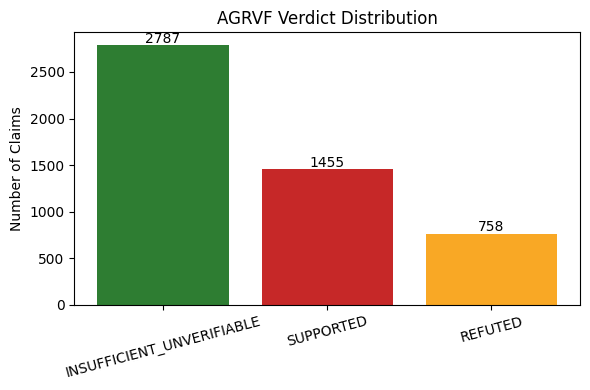

In [184]:
# Verdict distribution
verdict_counts = layer_d_output["verdict"].value_counts()
plt.figure(figsize=(6, 4))
plt.bar(verdict_counts.index, verdict_counts.values, color=["#2E7D32", "#C62828", "#F9A825"])
plt.title("AGRVF Verdict Distribution")
plt.ylabel("Number of Claims")
plt.xticks(rotation=15)
for i, v in enumerate(verdict_counts.values):
    plt.text(i, v + max(verdict_counts.values) * 0.01, str(v), ha="center")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig_verdict_distribution.png", dpi=300)
plt.show()

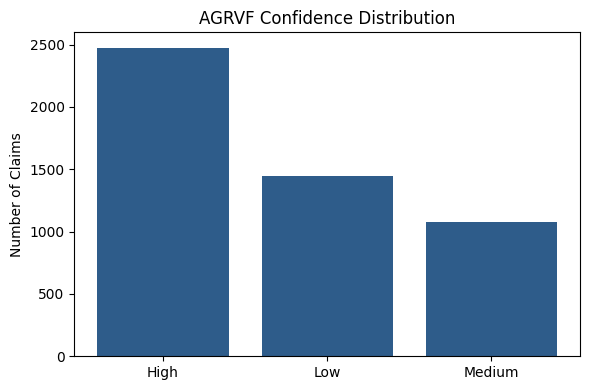

In [185]:
# Confidence distribution
conf_counts = layer_d_output["confidence_label"].value_counts()
plt.figure(figsize=(6, 4))
plt.bar(conf_counts.index, conf_counts.values, color="#2E5C8A")
plt.title("AGRVF Confidence Distribution")
plt.ylabel("Number of Claims")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig_confidence_distribution.png", dpi=300)
plt.show()

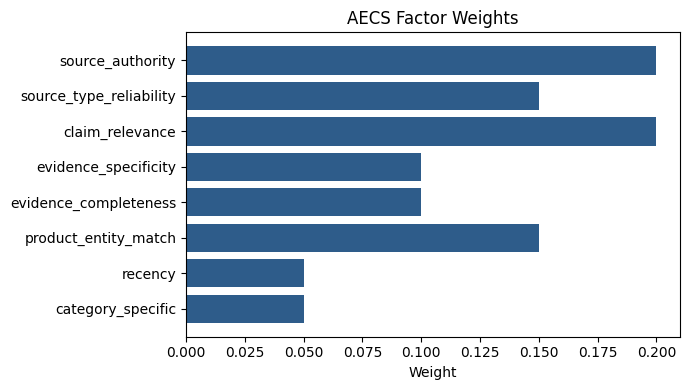

In [186]:
# AECS factor weights
plt.figure(figsize=(7, 4))
factors, weights = list(AECS_WEIGHTS.keys()), list(AECS_WEIGHTS.values())
plt.barh(factors, weights, color="#2E5C8A")
plt.xlabel("Weight")
plt.title("AECS Factor Weights")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig_aecs_weights.png", dpi=300)
plt.show()

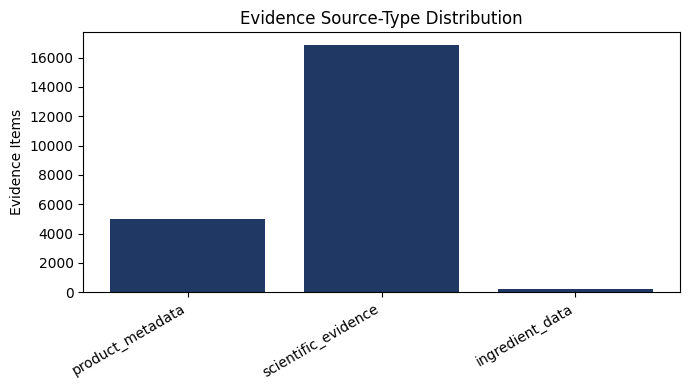

In [187]:
# Evidence source-type distribution
source_counter = Counter()
for ev_json in layer_d_output["evidence"]:
    try:
        items = _json.loads(ev_json) if isinstance(ev_json, str) else ev_json
    except Exception:
        continue
    for item in items or []:
        source_counter[item.get("source_type", "unknown")] += 1

plt.figure(figsize=(7, 4))
plt.bar(source_counter.keys(), source_counter.values(), color="#1F3864")
plt.title("Evidence Source-Type Distribution")
plt.ylabel("Evidence Items")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig_evidence_source_distribution.png", dpi=300)
plt.show()

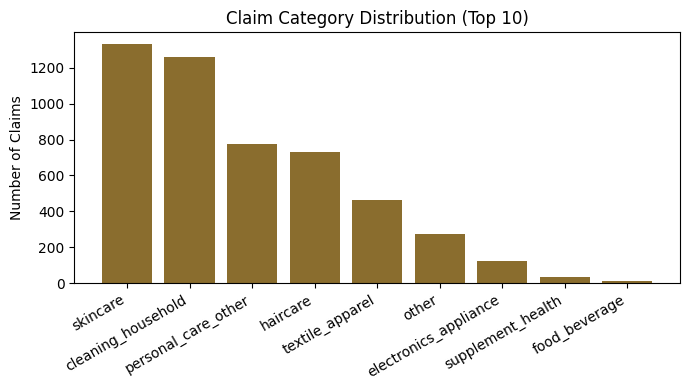

In [188]:
# Claim category distribution (top 10)
cat_counts = layer_d_output["category"].value_counts().head(10)
plt.figure(figsize=(7, 4))
plt.bar(cat_counts.index, cat_counts.values, color="#8A6D2E")
plt.title("Claim Category Distribution (Top 10)")
plt.ylabel("Number of Claims")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig_category_distribution.png", dpi=300)
plt.show()

## 4.3 - Test case A: a claim about a product that is *not* in the local catalog

This is the example from the project brief. `Dettol Handwash` will not be in the Amazon/OpenBeautyFacts sample used to build the local catalog, so this exercises the web-scraping path end to end: Layer D resolves Dettol's official product page (section D1), scrapes it (section D2), cleans it into evidence passages (section D3), and - since there is no local ingredient evidence for it - separately searches the web specifically for its ingredient list (section D4.1b), all before AECS scoring, stance classification, and the final verdict.

In [189]:
test_claim_unknown = (
    "For powerful germ protection your family can trust, choose Dettol Handwash. "
    "Its proven formula kills 99.9% of bacteria and viruses, helping keep hands "
    "clean and protected with every wash."
)

result_unknown = agrvf_verify_claim(test_claim_unknown)


CLAIM      : For powerful germ protection your family can trust, choose Dettol Handwash. Its proven formula kills 99.9% of bacteria and viruses, helping keep hands clean and protected with every wash.
------------------------------------------------------------------------------
PRODUCT    : (no specific product identified)
BRAND      : (unknown)
IN LOCAL DATABASE: False   |  resolution method: no_product_identified
CATEGORY   : other
CLAIM TYPE : unknown
------------------------------------------------------------------------------
EVIDENCE (5 item(s) - showing up to 8, AECS-sorted):
  [1] source=scientific_evidence stance=not_addressed      AECS=0.751
      Inhibition of receptor-interacting protein kinase 1 (RIPK1) kinase activity or combined deficiency of Fas-associated via death domain protein (FADD) and RIPK3 p
  [2] source=scientific_evidence stance=not_addressed      AECS=0.751
      Inhibition of receptor-interacting protein kinase 1 (RIPK1) kinase activity or combined deficie

## 4.4 - Test case B: a claim about a product that *is* in the local catalog

Rather than guessing a product name that may or may not exist in your specific Amazon sample, this pulls a real product name straight out of the loaded `amazon_products` catalog and builds a plain descriptive claim about it - guaranteeing this exercises the local-database path (Amazon catalog evidence + possible OpenBeautyFacts ingredient match), with web evidence only supplementing it.

In [190]:
sample_known_product = amazon_products.sample(n=1, random_state=7).iloc[0]
test_claim_known = f"{sample_known_product['product_name']} works exactly as described by the brand and is a favorite among regular users."

print("Using a real catalog product for this test:", sample_known_product["product_name"])
result_known = agrvf_verify_claim(test_claim_known)


Using a real catalog product for this test: Maketop TM Cosmetic Bag Black and White Polka-Dot Makeup Bag
CLAIM      : Maketop TM Cosmetic Bag Black and White Polka-Dot Makeup Bag works exactly as described by the brand and is a favorite among regular users.
------------------------------------------------------------------------------
PRODUCT    : Maketop TM Cosmetic Bag
BRAND      : (unknown)
IN LOCAL DATABASE: True   |  resolution method: local_catalog_semantic
CATEGORY   : personal_care_other
CLAIM TYPE : unknown
------------------------------------------------------------------------------
EVIDENCE (1 item(s) - showing up to 8, AECS-sorted):
  [1] source=product_metadata   stance=not_addressed      AECS=0.643
      Maketop TM Cosmetic Bag Black and White Polka-Dot Makeup Bag | All Beauty
------------------------------------------------------------------------------
AECS-WEIGHTED CREDIBILITY:
  support_mass = 0.0   contradict_mass = 0.0
----------------------------------------------

## 4.5 - Test case C: a non-product, non-verifiable claim (negative control)

Confirms the pipeline does not force a product identity or a verdict onto text that isn't actually a product claim.

In [191]:
test_claim_negative = "The Earth is flat."

result_negative = agrvf_verify_claim(test_claim_negative)

assert result_negative["product"] in ("", None) or not result_negative.get("in_database"), (
    "Negative control unexpectedly resolved to a local product."
)
print("\nNegative-control assertion passed: no local product was invented for a non-product claim.")


CLAIM      : The Earth is flat.
------------------------------------------------------------------------------
PRODUCT    : (no specific product identified)
BRAND      : (unknown)
IN LOCAL DATABASE: False   |  resolution method: no_product_identified
CATEGORY   : other
CLAIM TYPE : fact
------------------------------------------------------------------------------
EVIDENCE (1 item(s) - showing up to 8, AECS-sorted):
  [1] source=scientific_evidence stance=partial_contradict AECS=0.682
      The formation of van Gogh bundles depends critically on the synergistic interaction of surfactin-producing and matrix-producing cells. We propose that surfactin
------------------------------------------------------------------------------
AECS-WEIGHTED CREDIBILITY:
  support_mass = 0.0   contradict_mass = 0.3412
------------------------------------------------------------------------------
VERDICT    : INSUFFICIENT_UNVERIFIABLE
CONFIDENCE : Medium (0.667)
-------------------------------------------

## 4.6 - Automated regression checks

Lightweight assertions confirming the two structural guarantees the project spec requires from the end-to-end path: (1) the verdict is always one of the three allowed values, and (2) a claim about a real catalog product is correctly routed through the local-database path with at least one piece of Amazon evidence attached.

In [192]:
VALID_VERDICTS = {"SUPPORTED", "REFUTED", "INSUFFICIENT_UNVERIFIABLE"}

for name, result in [
    ("unknown-product (web path)", result_unknown),
    ("known-product (local path)", result_known),
    ("negative control", result_negative),
]:
    assert result["verdict"] in VALID_VERDICTS, f"{name}: invalid verdict {result['verdict']!r}"
    assert result["confidence_label"] in ("Low", "Medium", "High"), f"{name}: invalid confidence label"
    print(f"[PASS] {name}: verdict={result['verdict']}, confidence={result['confidence_label']}")

assert result_known["in_database"] is True, "Known-catalog test case did not resolve to the local database."
assert result_known["amazon_evidence_count"] >= 1, "Known-catalog test case produced no Amazon evidence."
print("[PASS] known-product case correctly used the local Amazon catalog evidence.")

assert result_unknown["in_database"] is False, "Unknown-product test case unexpectedly matched the local catalog."
print("[PASS] unknown-product case correctly fell back to web resolution instead of inventing a local match.")

print("\nAll Part 4 regression checks PASSED.")


[PASS] unknown-product (web path): verdict=INSUFFICIENT_UNVERIFIABLE, confidence=Low
[PASS] known-product (local path): verdict=INSUFFICIENT_UNVERIFIABLE, confidence=Low
[PASS] negative control: verdict=INSUFFICIENT_UNVERIFIABLE, confidence=Medium
[PASS] known-product case correctly used the local Amazon catalog evidence.
[PASS] unknown-product case correctly fell back to web resolution instead of inventing a local match.

All Part 4 regression checks PASSED.


## 4.7 - Try your own claim

Edit `my_claim` below (any 1-4 line product claim) and re-run the cell - this is the free-form entry point requested in the project brief. It works whether or not the product exists in the local dataset.

In [193]:
my_claim = """\
For soft, hydrated skin your family can trust, choose NIVEA Soft Moisturizing Cream. Its lightweight formula provides refreshing moisture, leaving your skin smooth, soft and beautifully cared for all day.
"""

my_result = agrvf_verify_claim(my_claim)


CLAIM      : provides refreshing moisture, leaving your skin smooth, soft and beautifully cared for all day
------------------------------------------------------------------------------
PRODUCT    : NIVEA Soft Moisturizing Cream
BRAND      : (unknown)
IN LOCAL DATABASE: False   |  resolution method: not_found_in_local_catalog
CATEGORY   : skincare
CLAIM TYPE : unknown
------------------------------------------------------------------------------
EVIDENCE (3 item(s) - showing up to 8, AECS-sorted):
  [1] source=ingredient_data    stance=partial_support    AECS=0.637
      AQUA/WATER/EAU, GLYCERIN, CETEARYL ALCOHOL, CAPRYLIC/CAPRIC TRIGLYCERIDE, CETYL ALCOHOL, CETEARETH-20, PETROLATUM, POTASSIUM PHOSPHATE, CERAMIDE NP, CERAMIDE AP
  [2] source=ingredient_data    stance=supports           AECS=0.634
      Aqua, Glycerin, Paraffinum Liquidum, Myristyl Alcohol, Butylene Glycol, Alcohol De Myristyl Myristate, Palmitic Acid, Glyceryl Stearate, Stearic Acid, Cera Micr
  [3] source=scientific_

In [194]:
my_claim = """\
For strong, healthy-looking hair you can count on, choose Dove Intense Repair Shampoo. Its nourishing formula helps repair the look of damaged hair, leaving it smoother, softer and more manageable with every wash.
"""

my_result = agrvf_verify_claim(my_claim)


CLAIM      : Repair Shampoo
------------------------------------------------------------------------------
PRODUCT    : Dove Intense Repair Shampoo
BRAND      : (unknown)
IN LOCAL DATABASE: True   |  resolution method: local_catalog_semantic
CATEGORY   : haircare
CLAIM TYPE : unknown
------------------------------------------------------------------------------
EVIDENCE (2 item(s) - showing up to 8, AECS-sorted):
  [1] source=ingredient_data    stance=partial_support    AECS=0.621
      WATER, SODIUM LAURETH SULFATE, DIMETHICONOL AND TRIDECETH-10 AND TEA-DODECYLBENZENESULFONATE, COCAMIDOPROPYL BETAINE, SODIUM CHLORIDE, PERFUME, GLYCOL DISTEARAT
  [2] source=product_metadata   stance=partial_support    AECS=0.494
      Dove Shampoo & Conditioner 12oz Intensive Repair Damage Solutions | All Beauty
------------------------------------------------------------------------------
AECS-WEIGHTED CREDIBILITY:
  support_mass = 0.5577   contradict_mass = 0.0
---------------------------------------

- Testing with same product with different claim sentence

In [195]:
my_claim = """\
Keep dandruff under control with Head&Shoulders Anti-Dandruff Shampoo. Its proven formula works to fight dandruff while helping your scalp stay fresh and clean with every wash.
"""

my_result = agrvf_verify_claim(my_claim)


CLAIM      : Keep dandruff under control with Head&Shoulders Anti-Dandruff Shampoo. Its proven formula works to fight dandruff while helping your scalp stay fresh and clean with every wash.
------------------------------------------------------------------------------
PRODUCT    : Head&Shoulders Anti-Dandruff Shampoo
BRAND      : Head & Shoulders
IN LOCAL DATABASE: True   |  resolution method: local_catalog_semantic
CATEGORY   : haircare
CLAIM TYPE : unknown
------------------------------------------------------------------------------
EVIDENCE (6 item(s) - showing up to 8, AECS-sorted):
  [1] source=scientific_evidence stance=not_addressed      AECS=0.661
      Progression to invasion was promoted by fibroblasts and inhibited by normal myoepithelial cells. Molecular profiles of isolated luminal epithelial and myoepithe
  [2] source=scientific_evidence stance=not_addressed      AECS=0.661
      Progression to invasion was promoted by fibroblasts and inhibited by normal myoepithelial ce

In [196]:
my_claim = """\
For effective dandruff protection you can count on, try Head&Shoulders Anti-Dandruff Shampoo. With its proven formula, it helps combat dandruff and leaves your scalp feeling fresh and clean wash after wash.
"""

my_result = agrvf_verify_claim(my_claim)


CLAIM      : leaves your scalp feeling fresh and clean wash after wash
------------------------------------------------------------------------------
PRODUCT    : Head&Shoulders Anti-Dandruff Shampoo
BRAND      : Head & Shoulders
IN LOCAL DATABASE: True   |  resolution method: local_catalog_semantic
CATEGORY   : haircare
CLAIM TYPE : unknown
------------------------------------------------------------------------------
EVIDENCE (6 item(s) - showing up to 8, AECS-sorted):
  [1] source=scientific_evidence stance=partial_contradict AECS=0.649
      Ascorbic-acid levels were undetectable or markedly reduced in the blood and tissues of Slc23a1−/− mice. Slc23a1−/− mice died within a few minutes of birth with 
  [2] source=product_metadata   stance=supports           AECS=0.629
      Head and Shoulders Instant Hydration 2-in-1 Dandruff Shampoo and Conditioner, 12.8 Fluid Ounce | Head & Shoulders | All Beauty | Head & Shoulders Instant Hydrat
  [3] source=ingredient_data    stance=partial_supp

## 4.8 - Optional: interactive console input

Uncomment and run this cell in an interactive Kaggle session to type in a claim directly (this cell will hang waiting for input if run as part of a non-interactive "Save & Run All" - leave it commented out for unattended full runs).

In [197]:
# claim_from_input = input("Paste a 1-4 line product claim: ").strip()
# if claim_from_input:
#     agrvf_verify_claim(claim_from_input)
# else:
#     print("No text entered.")


## Notebook complete

- Layer B produced `layer_b_structured_output.parquet` - product/claim/category understanding for every claim.
- Layer C produced `layer_c_local_evidence.parquet` and `layer_c_evidence_flat.parquet` - local evidence only.
- Layer D produced `layer_d_final_output.parquet` - the full `CLAIM -> PRODUCT -> CATEGORY -> CLAIM TYPE -> EVIDENCE -> AECS-WEIGHTED CREDIBILITY -> VERDICT -> CONFIDENCE -> REASONING -> SCIENTIFIC/INGREDIENT EXPLANATION -> PROVENANCE` result for every claim in the dataset.
- Part 4 lets you run that same pipeline live on any new claim, via `agrvf_verify_claim(text)`, correctly handling both catalog-known and catalog-unknown products, including generalized web-based ingredient discovery.

Re-running this notebook end-to-end will not repeat any already-completed heavy stage - see Part 0.3.

import os
import shutil

- Paths
folder = "/kaggle/working/AGRVF"
old_zip = "/kaggle/working/AGRVF_data.zip"
new_zip = "/kaggle/working/AGRVFdata"

- 1. Delete the old ZIP if it exists
if os.path.exists(old_zip):
    os.remove(old_zip)
    print("Deleted:", old_zip)

- 2. Create a new ZIP containing EVERYTHING inside AGRVF
shutil.make_archive(
    new_zip,
    "zip",
    root_dir="/kaggle/working",
    base_dir="AGRVF"
)

print("Created:", new_zip + ".zip")


In [198]:
n_total = len(layer_b) 
table_iv_rest = pd.DataFrame([ 
    {"Metric": "Product mentioned (%)",  "Value": round(100 * layer_b["product_mentioned"].mean(), 2)}, 
    {"Metric": "Product identified (%)", "Value": round(100 * layer_b["product_identified"].mean(), 2)}, 
]) 
print(table_iv_rest.to_string(index=False)) 
 
zero_evidence_pct = round(100 * (layer_c_output["evidence_count"] == 0).mean(), 2) 
print("Claims with zero local evidence (%):", zero_evidence_pct) 

                Metric  Value
 Product mentioned (%)  100.0
Product identified (%)  100.0
Claims with zero local evidence (%): 0.0


In [199]:
print("AGRVF full-system verdict distribution:\n", layer_d_output["verdict"].value_counts()) 
 
# layer_d_output has no in_database/resolved_product_id - join them from layer_c_nested first 
ld_full = layer_d_output.merge( 
    layer_c_nested[["agrvf_claim_id", "in_database", "resolved_product_id"]], 
    on="agrvf_claim_id", how="left" 
) 
 
print("\nSplit by local-catalogue status:\n", 
      ld_full.groupby("in_database")["verdict"].value_counts().unstack(fill_value=0)) 
 
# Rating-based baseline - only works AFTER the Layer A patch above is applied and 
# the updated amazon_products_agrvf.parquet is re-attached to this session. 
if "average_rating" in amazon_products.columns: 
    def rating_based_verdict(avg_rating): 
        if pd.isna(avg_rating): 
            return "INSUFFICIENT_UNVERIFIABLE" 
        if avg_rating >= 4.0: 
            return "SUPPORTED" 
        if avg_rating <= 2.5: 
            return "REFUTED" 
        return "INSUFFICIENT_UNVERIFIABLE" 
 
    ld_rated = ld_full.merge( 
        amazon_products[["product_id", "average_rating"]], 
        left_on="resolved_product_id", right_on="product_id", how="left" 
    ) 
    ld_rated["baseline_verdict"] = ld_rated["average_rating"].apply(rating_based_verdict) 
    print("\nRating-based baseline distribution:\n", ld_rated["baseline_verdict"].value_counts()) 
else: 
    print("\naverage_rating not found - apply the Layer A patch above first.") 

AGRVF full-system verdict distribution:
 verdict
INSUFFICIENT_UNVERIFIABLE    2787
SUPPORTED                    1455
REFUTED                       758
Name: count, dtype: int64

Split by local-catalogue status:
 verdict      INSUFFICIENT_UNVERIFIABLE  REFUTED  SUPPORTED
in_database                                               
True                              2787      758       1455

average_rating not found - apply the Layer A patch above first.


In [200]:
sample = ld_full.groupby("in_database", group_keys=False).apply( 
    lambda g: g.sample(min(len(g), 60), random_state=42) 
) 
sample[["agrvf_claim_id", "claim_text", "product", "in_database", "verdict", "confidence_label"]].to_csv( 
    f"{BASE_PATH}/results/human_eval_sample.csv", index=False 
) 
print("Saved:", f"{BASE_PATH}/results/human_eval_sample.csv") 

Saved: /kaggle/working/AGRVF/results/human_eval_sample.csv


In [201]:
result_known    = agrvf_verify_claim(test_claim_known, verbose=False) 
result_unknown  = agrvf_verify_claim(test_claim_unknown, verbose=False) 
result_negative = agrvf_verify_claim(test_claim_negative, verbose=False) 
 
table_vii = pd.DataFrame([ 
    {"Case": "A - known product",        "In Local DB": "Yes", "Verdict": result_known["verdict"],    "Confidence": result_known["confidence_label"]}, 
    {"Case": "B - unknown product",      "In Local DB": "No",  "Verdict": result_unknown["verdict"],  "Confidence": result_unknown["confidence_label"]}, 
    {"Case": "C - non-product sentence", "In Local DB": "N/A", "Verdict": result_negative["verdict"], "Confidence": result_negative["confidence_label"]}, 
]) 
print(table_vii.to_string(index=False)) 

                    Case In Local DB                   Verdict Confidence
       A - known product         Yes INSUFFICIENT_UNVERIFIABLE        Low
     B - unknown product          No INSUFFICIENT_UNVERIFIABLE        Low
C - non-product sentence         N/A INSUFFICIENT_UNVERIFIABLE     Medium


    threshold  recall_at_1
0        0.10          0.2
1        0.15          0.2
2        0.20          0.2
3        0.25          0.2
4        0.30          0.2
5        0.35          0.2
6        0.40          0.2
7        0.45          0.2
8        0.50          0.2
9        0.55          0.2
10       0.60          0.1
11       0.65          0.1
12       0.70          0.1
13       0.75          0.1
14       0.80          0.1
15       0.85          0.0
16       0.90          0.0


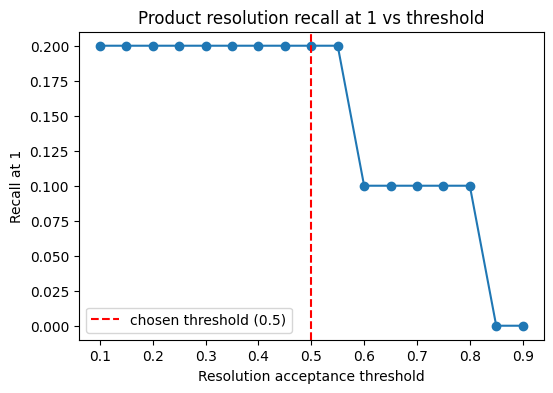

In [202]:
import numpy as np
import matplotlib.pyplot as plt

FIGURES_DIR = f"{BASE_PATH}/results/figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

thresholds = np.arange(0.10, 0.95, 0.05)
recall_at_1 = []

for t in thresholds:
    correct = 0
    for sentence, true_id in positive_ground_truth.items():
        extraction = b31_extract(sentence)
        product_name = extraction["products"][0]["product_name"] if extraction["products"] else ""
        matches = resolve_product(product_name, top_k=1)
        if len(matches) > 0 and matches.iloc[0]["b3_score"] >= t:
            predicted_id = matches.iloc[0]["product_id"]
        else:
            predicted_id = None
        correct += int(predicted_id == true_id)
    recall_at_1.append(correct / len(positive_ground_truth))

fig3_df = pd.DataFrame({"threshold": thresholds, "recall_at_1": recall_at_1})
print(fig3_df)

plt.figure(figsize=(6, 4))
plt.plot(fig3_df["threshold"], fig3_df["recall_at_1"], marker="o")
plt.axvline(0.5, color="red", linestyle="--", label="chosen threshold (0.5)")
plt.xlabel("Resolution acceptance threshold")
plt.ylabel("Recall at 1")
plt.title("Product resolution recall at 1 vs threshold")
plt.legend()
plt.savefig(f"{FIGURES_DIR}/fig3_recall_at_1.png", dpi=200, bbox_inches="tight")
plt.show()


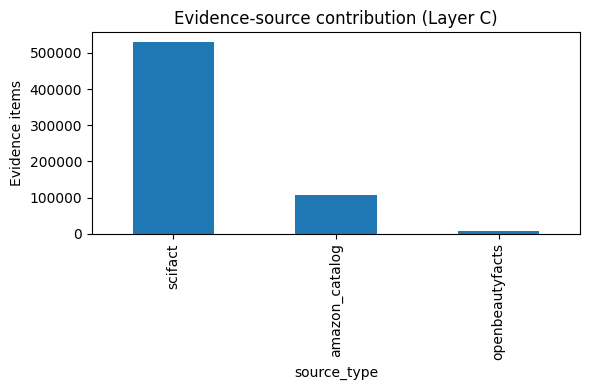

In [203]:
FIGURES_DIR = f"{BASE_PATH}/results/figures" 
os.makedirs(FIGURES_DIR, exist_ok=True) 
 
counts = layer_c_evidence_flat["source_type"].value_counts() 
plt.figure(figsize=(6,4)) 
counts.plot(kind="bar") 
plt.ylabel("Evidence items") 
plt.title("Evidence-source contribution (Layer C)") 
plt.tight_layout() 
plt.savefig(f"{FIGURES_DIR}/evidence_source_contribution.png", dpi=200) 
plt.show() 

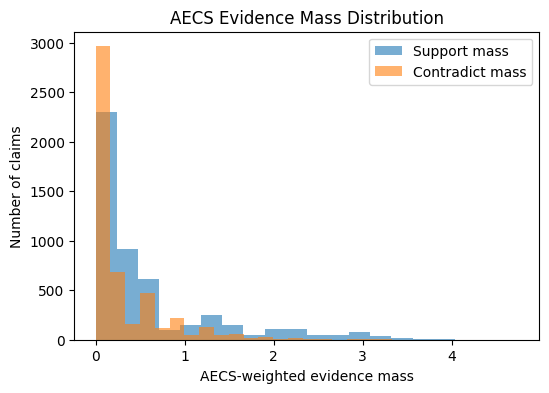

In [204]:
plt.figure(figsize=(6,4)) 
plt.hist(layer_d_output["support_mass"], bins=20, alpha=0.6, label="Support mass") 
plt.hist(layer_d_output["contradict_mass"], bins=20, alpha=0.6, label="Contradict mass") 
plt.xlabel("AECS-weighted evidence mass") 
plt.ylabel("Number of claims") 
plt.legend() 
plt.title("AECS Evidence Mass Distribution") 
plt.savefig(f"{FIGURES_DIR}/aecs_mass_distribution.png", dpi=200) 
plt.show() 

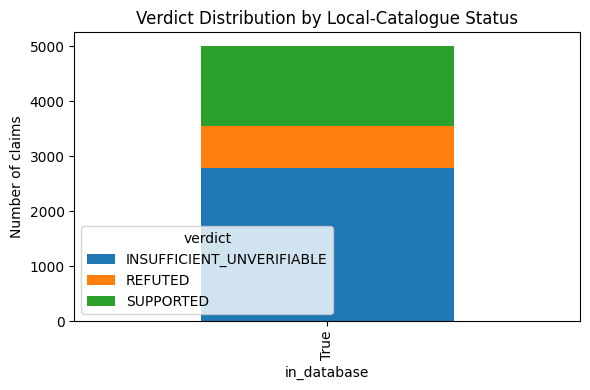

In [205]:
verdict_by_catalog = ld_full.groupby("in_database")["verdict"].value_counts().unstack(fill_value=0) 
verdict_by_catalog.plot(kind="bar", stacked=True, figsize=(6,4)) 
plt.ylabel("Number of claims") 
plt.title("Verdict Distribution by Local-Catalogue Status") 
plt.tight_layout() 
plt.savefig(f"{FIGURES_DIR}/verdict_by_catalog_status.png", dpi=200) 
plt.show() 

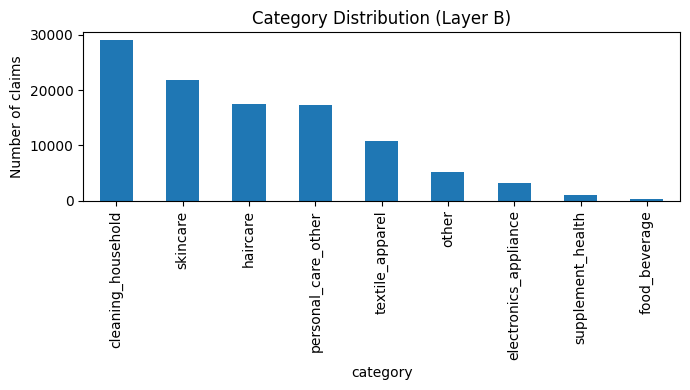

In [206]:
counts = layer_b["category"].value_counts() 
plt.figure(figsize=(7,4)) 
counts.plot(kind="bar") 
plt.ylabel("Number of claims") 
plt.title("Category Distribution (Layer B)") 
plt.tight_layout() 
plt.savefig(f"{FIGURES_DIR}/category_distribution.png", dpi=200) 
plt.show() 

In [207]:
import json as _json

science_contradict_scores = []

for _, row in flagged.iterrows():
    evidence_list = row["evidence"]
    if isinstance(evidence_list, str):
        evidence_list = _json.loads(evidence_list)
    for e in evidence_list or []:
        if e.get("stance") == "contradicts" and e.get("source_type") == "scientific_evidence":
            science_contradict_scores.append(e.get("aecs_score"))

import pandas as pd
print(pd.Series(science_contradict_scores).describe())

count    70.000000
mean      0.642714
std       0.037223
min       0.544200
25%       0.634050
50%       0.653900
75%       0.666400
max       0.699400
dtype: float64


In [208]:
import json as _json

changed_mask = refuted_subset["verdict_corrected"] != refuted_subset["verdict"]

print("Sample: stayed REFUTED (should look like real contradictions)")
for _, row in refuted_subset[refuted_subset["verdict_corrected"] == "REFUTED"].sample(3, random_state=1).iterrows():
    print("CLAIM:", row["claim_text"][:150])
    print("REASONING:", row["reasoning"][:250])
    print("---")

print("\nSample: flipped to INSUFFICIENT_UNVERIFIABLE (should look like the bogus science matches)")
for _, row in refuted_subset[refuted_subset["verdict_corrected"] == "INSUFFICIENT_UNVERIFIABLE"].sample(3, random_state=1).iterrows():
    print("CLAIM:", row["claim_text"][:150])
    print("REASONING:", row["reasoning"][:250])
    print("---")

print("\nSample: flipped to SUPPORTED (check real support exists once junk contradiction is removed)")
for _, row in refuted_subset[refuted_subset["verdict_corrected"] == "SUPPORTED"].sample(3, random_state=1).iterrows():
    print("CLAIM:", row["claim_text"][:150])
    print("REASONING:", row["reasoning"][:250])
    print("---")

Sample: stayed REFUTED (should look like real contradictions)
CLAIM: br />+ Premium natural ingredients<br />+ Vitamins A,C,E, F, rosehip<br />+
REASONING: The claim is refuted by evidence showing that vitamin E did not reduce the incidence of prostate cancer compared to a placebo. The study found no significant difference in cancer incidence between the groups, indicating that vitamin E did not have a 
---
CLAIM: Differently recommended
REASONING: The claim that "differently recommended" is refuted by the evidence showing no significant difference in the Oxford Shoulder Score between surgical and nonsurgical groups over 2 years, and a rate ratio of 0.83 for serious cardiovascular events associ
---
CLAIM: Big bottle is better value and lasts me longer.
REASONING: The claim that a big bottle is better value and lasts longer is not supported by the provided evidence. The evidence includes information about organic castor oil and its benefits for hair, eyelashes, and brows, as well as som

In [209]:
import os, shutil

BASE_PATH = "/kaggle/working/AGRVF"
STAGE_DIR = "/kaggle/working/AGRVF_BCD_export"
ZIP_PATH  = "/kaggle/working/AGRVF_LayerBCD_output"

if os.path.exists(STAGE_DIR):
    shutil.rmtree(STAGE_DIR)
os.makedirs(STAGE_DIR)

required_files = [
    "data/processed/layer_d/layer_d_final_output.parquet",
    "data/processed/layer_b/layer_b_structured_output.parquet",
    "results/layer_c/layer_c_local_evidence.parquet",
    "results/layer_c/layer_c_evidence_flat.parquet",
]

def copy_in(rel_path, dest_root):
    src = os.path.join(BASE_PATH, rel_path)
    dst = os.path.join(dest_root, rel_path)
    if not os.path.exists(src):
        print("MISSING (skipped):", src)
        return
    os.makedirs(os.path.dirname(dst), exist_ok=True)
    shutil.copy2(src, dst)
    print("Copied:", rel_path)

print("Required outputs")
req_root = os.path.join(STAGE_DIR, "required_for_paper")
for f in required_files:
    copy_in(f, req_root)

for sub in ["results/figures"]:
    src = os.path.join(BASE_PATH, sub)
    if os.path.isdir(src):
        shutil.copytree(src, os.path.join(req_root, sub), dirs_exist_ok=True)
        print("Copied:", sub + "/")

shutil.make_archive(ZIP_PATH, "zip", STAGE_DIR)
size_mb = os.path.getsize(ZIP_PATH + ".zip") / (1024**2)
print(f"Zip created: {ZIP_PATH}.zip  ({size_mb:.1f} MB)")

Required outputs
Copied: data/processed/layer_d/layer_d_final_output.parquet
Copied: data/processed/layer_b/layer_b_structured_output.parquet
Copied: results/layer_c/layer_c_local_evidence.parquet
Copied: results/layer_c/layer_c_evidence_flat.parquet
Copied: results/figures/
Zip created: /kaggle/working/AGRVF_LayerBCD_output.zip  (322.3 MB)
